# Hungarian Election Prediction 2026 | Andrási Kristóf - notebook 13


### Imports

This block loads the packages used in the notebook. The structure follows notebook 01 so the notebook opening stays consistent across the final folder.


In [1]:
# this block loads the packages used in the notebook.
import importlib
import subprocess
import sys

def ensure_packages(packages):
    # install a package only if it is missing
    for pkg in packages:
        try:
            importlib.import_module(pkg)
        except ImportError:
            print(f"{pkg} not found, installing...")
            subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])
            print(f"{pkg} installed.")

ensure_packages(["pandas", "numpy", "openpyxl", "matplotlib", "re", "xlrd", "scipy", "statsmodels", "IPython"])

import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import re
import numpy as np


### Working Directory

This block sets the main project paths so file loading works the same way each time. The layout follows notebook 01.


In [2]:
# this block sets the main project paths so file loading works the same way each time.
def find_project_root(start_path=None):
    start_path = Path.cwd().resolve() if start_path is None else Path(start_path).resolve()
    for candidate in [start_path, *start_path.parents]:
        if (candidate / "scripts" / "final_final_scripts").exists() and (candidate / "data").exists():
            return candidate
    raise FileNotFoundError("Could not find project root from the current working directory.")

here = Path.cwd().resolve()
project_root = find_project_root(here)
data_dir = project_root / "data" / "TokaGabor"

print("here:", here)
print("project_root:", project_root)
print("data_dir:", data_dir)


here: /Users/andrasikristof/Documents/Egyetem/2026:27 - 2. félév/Election_predictions/scripts/final_final_scripts
project_root: /Users/andrasikristof/Documents/Egyetem/2026:27 - 2. félév/Election_predictions
data_dir: /Users/andrasikristof/Documents/Egyetem/2026:27 - 2. félév/Election_predictions/data/TokaGabor


Interpretation. The printed paths should point to this election project. If they do not, the later loading steps can fail.


## Notebook 13

This section keeps the final 2026 forecast notebook so the final prediction remains available in the final folder.


### Imports

**Why this is necessary:** Before doing anything, we need to load the Python libraries that handle data (pandas, numpy),
statistics (statsmodels), and plotting (matplotlib). We also set some global constants like the four political
blocks (gov, opp, opp_radical, other) and their colors.

**Parameter note:** This section contains the fixed global settings `block_cols`, `nonbase_blocks`,
`composition_floor`, `full_history_min_nonmissing_share`, and the reproducibility seed `np.random.seed(42)`.


In [3]:
# this block loads the packages used in the notebook.
from pathlib import Path
import os
import warnings
import json

os.environ.setdefault("MPLCONFIGDIR", "/tmp/mpl")  # avoid matplotlib cache issues

import matplotlib
matplotlib.use("Agg")  # use non-interactive backend for notebook rendering
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Monkeypatch for scipy/statsmodels compatibility issue with Python 3.13
try:
    import scipy._lib._util
    if not hasattr(scipy._lib._util, '_lazywhere'):
        import scipy.special as special
        def _lazywhere(cond, *args, f=None, fillvalue=None, **kwargs):
            output = np.empty(np.broadcast(*args, **kwargs).shape, dtype=float)
            output[~cond] = fillvalue
            output[cond] = f(*[np.asarray(a)[cond] for a in args], **kwargs)
            return output
        scipy._lib._util._lazywhere = _lazywhere
except Exception:
    pass

import statsmodels.api as sm  # for mixed-effects models
from IPython.display import display
from matplotlib.lines import Line2D  # for custom legend entries

warnings.filterwarnings("ignore")  # suppress noisy convergence warnings
np.random.seed(42)  # set random seed for reproducibility
pd.set_option("display.max_columns", 200)  # show all columns in wide tables
pd.set_option("display.width", 200)
plt.style.use("seaborn-v0_8-whitegrid")  # clean plot style

# Define the four political blocks used throughout the notebook
block_cols = ["gov", "opp", "opp_radical", "other"]
# The first three are modelled in log-ratio space; "other" is the baseline
nonbase_blocks = ["gov", "opp", "opp_radical"]
seat_blocks = [block for block in block_cols if block != "other"]
composition_floor = 1e-4  # minimum share to avoid log(0)
full_history_min_nonmissing_share = 0.95  # features must have 95% non-missing to be used

# Color scheme for the four blocks in all plots
block_colors = {
    "gov": "#f28e2b",       # orange for government block
    "opp": "#4e79a7",       # blue for main opposition
    "opp_radical": "#59a14f", # green for radical opposition
    "other": "#9c9c9c",      # grey for other/minor parties
}

### Load The Data

**Why this is necessary:** The model needs four input tables. Without loading these,
nothing else in the notebook can work. The tables contain:
- polls (what pollsters measured)
- district statistics (demographics, economy, media usage per OEVK)
- district election results (actual votes from 2018, 2019, 2022, 2024)
- national mandate data (official seat counts to validate our seat formula)

**Parameter note:** This section contains the fixed forecast date parameter
`election_assumption_2026 = "2026-04-12"`.


In [4]:
# this block loads the prepared tables used in the notebook.


def find_project_root(start_path=None):
    start_path = Path.cwd().resolve() if start_path is None else Path(start_path).resolve()
    for candidate in [start_path, *start_path.parents]:
        if (candidate / "scripts" / "final_final_scripts").exists() and (candidate / "data").exists():
            return candidate
    raise FileNotFoundError("Could not find project root from the current working directory.")

here = Path.cwd().resolve()
project_root = find_project_root(here)
created_dir = project_root / "data" / "created"

polls = pd.read_csv(created_dir / "polls.csv")  # national poll data
final_statistics_oevk = pd.read_csv(created_dir / "statistics.csv")  # district demographics and media
final_results_oevk_party = pd.read_csv(created_dir / "oevk_results.csv")  # district election results
mandates_all_combined = pd.read_csv(created_dir / "global_results.csv")  # official seat counts

election_assumption_2026 = pd.Timestamp("2026-04-12")  # assumed date for the 2026 election

table_overview = pd.DataFrame(
    {
        "table": [
            "polls",
            "final_statistics_oevk",
            "final_results_oevk_party",
            "mandates_all_combined",
        ],
        "rows": [
            len(polls),
            len(final_statistics_oevk),
            len(final_results_oevk_party),
            len(mandates_all_combined),
        ],
        "columns": [
            polls.shape[1],
            final_statistics_oevk.shape[1],
            final_results_oevk_party.shape[1],
            mandates_all_combined.shape[1],
        ],
    }
)

print("project_root:", project_root)
print("created_dir:", created_dir)
print("fixed 2026 election day:", election_assumption_2026.date())
display(table_overview)


project_root: /Users/andrasikristof/Documents/Egyetem/2026:27 - 2. félév/Election_predictions
created_dir: /Users/andrasikristof/Documents/Egyetem/2026:27 - 2. félév/Election_predictions/data/created
fixed 2026 election day: 2026-04-12


,table,rows,columns
0,polls,1790,40
1,final_statistics_oevk,530,308
2,final_results_oevk_party,3710,24
3,mandates_all_combined,35,10


**Interpretation:** The table above shows how many rows and columns each dataset has.
If all four tables loaded with a reasonable number of rows, the data pipeline from notebook 01 worked correctly.
The `created_dir` path tells you where the prepared CSV files live on disk.


### Quick Table Check

**Why this is necessary:** Before modelling, we need to make sure the data covers the right years
and has enough rows. If the 2026 district rows are missing, we cannot build a forecast.
If the poll date range does not reach close to election day, the poll signal will be weaker.


In [5]:
# this block checks that the prepared data covers the expected years and elections.


polls["Vég"] = pd.to_datetime(polls["Vég"], errors="coerce")

quick_check = pd.DataFrame(
    {
        "item": [
            "statistics years",
            "results years x type",
            "poll date range",
            "pollsters",
            "2026 district rows",
        ],
        "value": [
            sorted(final_statistics_oevk["year"].dropna().unique().tolist()),
            final_results_oevk_party.groupby(["year", "election_type"]).size().to_dict(),
            f"{polls['Vég'].min().date()} to {polls['Vég'].max().date()}",
            int(polls["Adatgazda"].dropna().astype(str).str.strip().nunique()),
            int((final_statistics_oevk["year"] == 2026).sum()),
        ],
    }
)

display(quick_check)


,item,value
0,statistics years,"[2018, 2019, 2022, 2024, 2026]"
1,results years x type,"{(2018, 'nat'): 954, (2019, 'ep'): 1060, (2022..."
2,poll date range,2014-03-19 to 2026-04-10
3,pollsters,34
4,2026 district rows,106


**Interpretation:** Check the table above:
- "statistics years" should include 2018, 2019, 2022, 2024, and 2026
- "results years x type" should show data for both parliamentary (nat) and European Parliament (ep) elections
- "poll date range" should reach close to the assumed 2026 election day
- "2026 district rows" should be 106 (one per OEVK)

If any of these are missing, the data preparation step (notebook 01) needs to be rerun.


### Helper Functions

**Why this is necessary:** These helper functions are the mathematical backbone of the entire notebook.
The most important idea is **additive log-ratio (ALR) transformation**. In an election,
vote shares must always add up to 100%. If we model each party separately with normal regression,
the predictions might not add up. ALR solves this: it transforms the shares into unconstrained
log-ratio space, where we can safely use linear models, and then transforms back.

- `close_comp()` makes sure vote shares are valid (positive and sum to 1)
- `alr()` transforms shares to log-ratio space (good for modelling)
- `inverse_alr()` transforms back to normal shares (good for reporting)
- `safe_weighted_average()` computes weighted means that handle missing values
- `stabilize_cov()` makes covariance matrices numerically safe
- `align_local_alr_to_national()` makes sure district forecasts add up to the national forecast


In [6]:
# this block defines helper functions that later cells reuse.


selected_single_media_outlet = "pro_gov_avg"
selected_media_window = "w3"
selected_media_metric = "real_users"
selected_media_outlets = [
    "24_b",
    "borsonline_b",
    "hirado_b",
    "magyarnemzet_b",
    "mandiner_b",
    "mediaklikk_b",
    "origo_b",
    "ripost_b",
    "tv2_b",
    "tenyek_b",
]
selected_media_raw_cols = [
    f"{selected_media_metric}_{selected_media_window}_{outlet}"
    for outlet in selected_media_outlets
]
selected_media_feature_cols = ["pro_gov_avg"]
selected_recent_media_features = selected_media_feature_cols.copy()
screened_feature_config = {}
screened_full_history_structure = [
    "log_pop_total",
    "young_share",
    "old_share",
    "unemployed_per_capita",
    "unemployed_univ_per_capita",
    "budget_balance_per_capita",
    "cars_per_capita",
    "cars_first_reg_per_capita",
    "doctor_per_capita",
    "dwellings_built_private_per_capita",
]
preliminary_fundamentals_models = {
    "model_1_demography_only": ["log_pop_total", "young_share", "old_share"],
    "model_2_plus_core_economy": [
        "log_pop_total",
        "young_share",
        "old_share",
        "unemployed_per_capita",
        "unemployed_univ_per_capita",
        "budget_balance_per_capita",
    ],
    "model_3_plus_modernization": [
        "log_pop_total",
        "young_share",
        "old_share",
        "unemployed_per_capita",
        "unemployed_univ_per_capita",
        "budget_balance_per_capita",
        "cars_per_capita",
        "cars_first_reg_per_capita",
    ],
    "model_4_plus_public_service_housing": [
        "log_pop_total",
        "young_share",
        "old_share",
        "unemployed_per_capita",
        "unemployed_univ_per_capita",
        "budget_balance_per_capita",
        "cars_per_capita",
        "cars_first_reg_per_capita",
        "doctor_per_capita",
        "dwellings_built_private_per_capita",
    ],
}

def clean_num(series):
    series = series.astype("string")
    series = series.str.replace("%", "", regex=False)
    series = series.str.replace(",", ".", regex=False)
    series = series.str.replace(r"[^0-9\.\-]", "", regex=True)
    series = series.replace("", pd.NA)
    return pd.to_numeric(series, errors="coerce").astype("float64")


def close_comp(df, cols, eps=composition_floor):
    # Make vote shares valid: clip to minimum, then normalize so they sum to 1
    arr = df[cols].astype("float64").to_numpy()
    arr = np.where(np.isfinite(arr), arr, np.nan)
    arr = np.nan_to_num(arr, nan=0.0)
    arr = np.clip(arr, eps, None)
    sums = arr.sum(axis=1, keepdims=True)
    sums = np.where(sums <= 0, 1.0, sums)
    arr = arr / sums
    return pd.DataFrame(arr, columns=cols, index=df.index)


def alr(df, cols, baseline="other"):
    # Transform vote shares to log-ratio space: log(share_i / share_baseline)
    comp = close_comp(df, cols)
    base = comp[baseline].to_numpy(dtype="float64")[:, None]
    arr = np.log(comp[[c for c in cols if c != baseline]].to_numpy(dtype="float64") / base)
    return pd.DataFrame(arr, columns=[f"alr_{c}" for c in cols if c != baseline], index=df.index)


def inverse_alr(arr, cols, baseline="other"):
    # Transform back from log-ratio space to normal vote shares
    arr = np.asarray(arr, dtype="float64")
    if arr.ndim == 1:
        arr = arr[None, :]
    arr = np.clip(arr, -30.0, 30.0)
    exp_arr = np.exp(arr)
    denom = 1.0 + exp_arr.sum(axis=1, keepdims=True)
    nonbase = exp_arr / denom
    base = 1.0 / denom
    out = np.concatenate([nonbase, base], axis=1)
    return pd.DataFrame(out, columns=[c for c in cols if c != baseline] + [baseline])


def safe_weighted_average(values, weights):
    # Compute weighted average, ignoring missing values and zero weights
    values = np.asarray(values, dtype="float64")
    weights = np.asarray(weights, dtype="float64")
    mask = np.isfinite(values) & np.isfinite(weights) & (weights > 0)
    if mask.sum() == 0:
        return float(np.nanmean(values)) if np.isfinite(values).any() else np.nan
    return float(np.average(values[mask], weights=weights[mask]))


def safe_weighted_variance(values, weights):
    values = np.asarray(values, dtype="float64")
    weights = np.asarray(weights, dtype="float64")
    mask = np.isfinite(values) & np.isfinite(weights) & (weights > 0)
    if mask.sum() == 0:
        return np.nan
    values = values[mask]
    weights = weights[mask]
    mean = np.average(values, weights=weights)
    return float(np.average((values - mean) ** 2, weights=weights))


def stabilize_cov(cov, floor=1e-4):
    # Make a covariance matrix numerically stable by flooring tiny eigenvalues
    arr = np.asarray(cov, dtype="float64")
    if arr.ndim == 0:
        arr = np.array([[float(arr)]], dtype="float64")
    arr = np.nan_to_num(arr, nan=0.0)
    arr = 0.5 * (arr + arr.T)
    vals, vecs = np.linalg.eigh(arr)
    vals = np.clip(vals, floor, None)
    return vecs @ np.diag(vals) @ vecs.T


def shrink_corr_to_identity(cov, n_obs, prior_strength=6.0, clip=0.5):
    cov = stabilize_cov(cov, floor=1e-6)
    sd = np.sqrt(np.maximum(np.diag(cov), 1e-8))
    corr = cov / np.outer(sd, sd)
    np.fill_diagonal(corr, 1.0)
    shrink = float(n_obs / (n_obs + prior_strength)) if n_obs > 0 else 0.0
    corr = shrink * corr + (1.0 - shrink) * np.eye(corr.shape[0], dtype="float64")
    corr = np.clip(corr, -clip, clip)
    np.fill_diagonal(corr, 1.0)
    corr = stabilize_cov(corr, floor=1e-6)
    corr_sd = np.sqrt(np.maximum(np.diag(corr), 1e-8))
    corr = corr / np.outer(corr_sd, corr_sd)
    np.fill_diagonal(corr, 1.0)
    return corr


def percent_table(df, cols):
    # Multiply columns by 100 for display as percentages
    out = df.copy()
    for col in cols:
        out[col] = out[col] * 100
    return out


def weighted_composition_average(df, cols, weights, eps=composition_floor):
    comp = close_comp(df, cols, eps=eps).to_numpy(dtype="float64")
    weights = np.asarray(weights, dtype="float64")
    mask = np.isfinite(weights) & (weights > 0)
    if mask.sum() == 0:
        weights = np.ones(comp.shape[0], dtype="float64")
    else:
        comp = comp[mask]
        weights = weights[mask]
    weights = weights / weights.sum()
    mean_share = weights @ comp
    return close_comp(pd.DataFrame([dict(zip(cols, mean_share))]), cols, eps=eps).iloc[0].to_dict()


# Shift district ALR values so their weighted average matches the national target
def align_local_alr_to_national(local_alr, target_alr, weights, cols, baseline="other", max_iter=10, tol=1e-10):
    arr = np.asarray(local_alr, dtype="float64")
    if arr.ndim == 1:
        arr = arr[None, :]
    target = np.asarray(target_alr, dtype="float64").reshape(-1)
    offset = target.copy()
    for _ in range(max_iter):
        adjusted = arr + offset[None, :]
        current_comp = inverse_alr(adjusted, cols, baseline=baseline)
        current_share = weighted_composition_average(current_comp, cols, weights)
        current_alr = alr(pd.DataFrame([current_share]), cols, baseline=baseline).iloc[0].to_numpy(dtype="float64")
        step = target - current_alr
        offset = offset + step
        if np.max(np.abs(step)) < tol:
            break
    return arr + offset[None, :]


### Model Building Functions

**Why this is necessary:** These functions handle the nuts and bolts of fitting statistical models:
- Creating design matrices (the X table of predictors that go into a regression)
- Handling categorical variables (like county names or pollster names)
- Fitting mixed-effects models (models that have both fixed effects and random group effects, for example a separate shift for each county)
- Screening features for missing values (dropping predictors that have too many gaps)

Mixed-effects models are important because districts within the same county tend to behave similarly.
A county random intercept captures this: it gives each county its own small shift up or down,
pulled toward zero by shrinkage so we do not overfit.


In [7]:
# this block defines helper functions that later cells reuse.


def recode_small_categories(train_ser, test_ser, min_count=5):
    train_ser = train_ser.astype("string").fillna("Unknown").str.strip().replace("", "Unknown")
    keep = train_ser.value_counts()[lambda s: s >= min_count].index.tolist()
    if "Other" not in keep:
        keep = keep + ["Other"]
    train_ser = train_ser.where(train_ser.isin(keep), "Other")
    test_ser = test_ser.astype("string").fillna("Unknown").str.strip().replace("", "Unknown")
    test_ser = test_ser.where(test_ser.isin(keep), "Other")
    return train_ser, test_ser, keep


def build_design(train_df, test_df, numeric_cols, cat_specs):
    train_parts = [pd.DataFrame({"intercept": np.ones(len(train_df))}, index=train_df.index)]
    test_parts = [pd.DataFrame({"intercept": np.ones(len(test_df))}, index=test_df.index)]
    meta = {"numeric": {}, "cats": {}}

    for col in numeric_cols:
        mean = float(train_df[col].mean()) if pd.notna(train_df[col].mean()) else 0.0
        std = float(train_df[col].std()) if pd.notna(train_df[col].std()) else 1.0
        if not np.isfinite(std) or std == 0:
            std = 1.0
        train_parts.append(pd.DataFrame({col: (train_df[col].fillna(mean) - mean) / std}, index=train_df.index))
        test_parts.append(pd.DataFrame({col: (test_df[col].fillna(mean) - mean) / std}, index=test_df.index))
        meta["numeric"][col] = {"mean": mean, "std": std}

    for col, min_count in cat_specs:
        train_ser, test_ser, keep = recode_small_categories(train_df[col], test_df[col], min_count=min_count)
        dtrain = pd.get_dummies(train_ser, prefix=col, dtype="float64")
        dtest = pd.get_dummies(test_ser, prefix=col, dtype="float64").reindex(columns=dtrain.columns, fill_value=0.0)
        if dtrain.shape[1] > 1:
            dtrain = dtrain.iloc[:, 1:]
            dtest = dtest[dtrain.columns]
        train_parts.append(dtrain)
        test_parts.append(dtest)
        meta["cats"][col] = {"keep": keep, "columns": dtrain.columns.tolist()}

    X_train = pd.concat(train_parts, axis=1)
    X_test = pd.concat(test_parts, axis=1).reindex(columns=X_train.columns, fill_value=0.0)
    return X_train, X_test, meta


def build_design_from_meta(df, meta):
    parts = [pd.DataFrame({"intercept": np.ones(len(df))}, index=df.index)]
    for col, info in meta["numeric"].items():
        mean = info["mean"]
        std = info["std"]
        parts.append(pd.DataFrame({col: (df[col].fillna(mean) - mean) / std}, index=df.index))
    for col, info in meta["cats"].items():
        ser = df[col].astype("string").fillna("Unknown").str.strip().replace("", "Unknown")
        ser = ser.where(ser.isin(info["keep"]), "Other")
        dtest = pd.get_dummies(ser, prefix=col, dtype="float64").reindex(columns=info["columns"], fill_value=0.0)
        parts.append(dtest)
    return pd.concat(parts, axis=1)


def feature_coverage_table(df, feature_cols):
    rows = []
    for col in feature_cols:
        if col not in df.columns:
            continue
        rows.append(
            {
                "feature": col,
                "nonmissing_share": float(df[col].notna().mean()),
            }
        )
    if not rows:
        return pd.DataFrame(columns=["feature", "nonmissing_share"])
    return pd.DataFrame(rows).sort_values(["nonmissing_share", "feature"]).reset_index(drop=True)


def screen_sparse_features(df, feature_cols, min_nonmissing_share=0.95, grouped_prefixes=None):
    valid_features = [col for col in feature_cols if col in df.columns]
    coverage = {
        col: float(df[col].notna().mean())
        for col in valid_features
    }
    kept = [
        col
        for col in valid_features
        if coverage[col] >= float(min_nonmissing_share)
    ]

    if grouped_prefixes is not None:
        for flag_col, value_prefix in grouped_prefixes:
            if flag_col not in kept:
                continue
            if not any(col.startswith(value_prefix) for col in kept):
                kept.remove(flag_col)

    dropped = [col for col in valid_features if col not in kept]
    coverage_df = pd.DataFrame(
        {
            "feature": valid_features,
            "nonmissing_share": [coverage[col] for col in valid_features],
            "used_downstream": [col in kept for col in valid_features],
        }
    ).sort_values(["used_downstream", "nonmissing_share", "feature"], ascending=[False, False, True]).reset_index(drop=True)
    return kept, dropped, coverage_df


def fit_random_intercept(train_df, target_col, numeric_cols, cat_specs, group_col):
    X_train, _, meta = build_design(train_df, train_df, numeric_cols, cat_specs)
    y_train = train_df[target_col].to_numpy(dtype="float64")
    groups = train_df[group_col].astype("string").fillna("Unknown").to_numpy()
    try:
        model = sm.MixedLM(y_train, X_train.to_numpy(dtype="float64"), groups=groups)
        result = model.fit(reml=False, method="lbfgs", maxiter=400, disp=False)
        rand_map = {}
        for key, value in result.random_effects.items():
            arr = np.asarray(value, dtype="float64").reshape(-1)
            rand_map[str(key)] = float(arr[0]) if len(arr) else 0.0
        return {
            "kind": "mixed",
            "result": result,
            "meta": meta,
            "columns": X_train.columns.tolist(),
            "group_col": group_col,
            "rand_map": rand_map,
            "fallback": float(np.nanmean(y_train)) if np.isfinite(y_train).any() else 0.0,
        }
    except Exception:
        result = sm.OLS(y_train, X_train.to_numpy(dtype="float64")).fit()
        return {
            "kind": "ols",
            "result": result,
            "meta": meta,
            "columns": X_train.columns.tolist(),
            "group_col": group_col,
            "rand_map": {},
            "fallback": float(np.nanmean(y_train)) if np.isfinite(y_train).any() else 0.0,
        }


def predict_random_intercept(bundle, df):
    X = build_design_from_meta(df, bundle["meta"]).reindex(columns=bundle["columns"], fill_value=0.0)
    fixed = X.to_numpy(dtype="float64") @ np.asarray(bundle["result"].params[: X.shape[1]], dtype="float64")
    if bundle["kind"] == "mixed":
        group_effect = (
            df[bundle["group_col"]]
            .astype("string")
            .fillna("Unknown")
            .astype(str)
            .map(bundle["rand_map"])
            .fillna(0.0)
            .to_numpy(dtype="float64")
        )
        pred = fixed + group_effect
    else:
        pred = fixed
    pred = np.asarray(pred, dtype="float64")
    pred = np.where(np.isfinite(pred), pred, bundle["fallback"])
    return pred


def predict_group_effect(bundle, df):
    if bundle["kind"] != "mixed":
        return np.zeros(len(df), dtype="float64")
    return (
        df[bundle["group_col"]]
        .astype("string")
        .fillna("Unknown")
        .astype(str)
        .map(bundle["rand_map"])
        .fillna(0.0)
        .to_numpy(dtype="float64")
    )


def grouped_balanced_folds(df, group_col, n_folds=5):
    counts = (
        df[group_col]
        .astype("string")
        .fillna("Unknown")
        .astype(str)
        .value_counts()
        .sort_values(ascending=False)
    )
    if counts.empty:
        return []
    n_folds = max(1, min(int(n_folds), len(counts)))
    fold_bins = [{"groups": [], "size": 0} for _ in range(n_folds)]
    for group, size in counts.items():
        chosen = min(fold_bins, key=lambda item: item["size"])
        chosen["groups"].append(group)
        chosen["size"] += int(size)
    return [item["groups"] for item in fold_bins if item["groups"]]


def fit_random_walk_series(df, value_col, date_col, weight_col, election_day):
    sub = df[[date_col, value_col, weight_col]].dropna().copy()
    if sub.empty:
        return {"mean": 0.0, "sd": 0.5, "series": pd.Series(dtype="float64"), "predicted_mean": pd.Series(dtype="float64")}
    daily_stats = (
        sub.groupby(date_col)
        .apply(
            lambda g: pd.Series(
                {
                    "mean": safe_weighted_average(g[value_col], g[weight_col]),
                    "within_var": safe_weighted_variance(g[value_col], g[weight_col]),
                    "effective_n": float(pd.to_numeric(g[weight_col], errors="coerce").clip(lower=0).sum()),
                }
            ),
            include_groups=False,
        )
        .sort_index()
    )
    daily = daily_stats["mean"]
    full_index = pd.date_range(daily.index.min(), election_day, freq="D")
    daily_stats = daily_stats.reindex(full_index)
    endog = daily_stats["mean"]

    observed = endog.dropna()
    if observed.empty:
        return {"mean": 0.0, "sd": 0.5, "series": endog, "predicted_mean": endog}

    if observed.shape[0] < 3:
        mean = float(observed.iloc[-1])
        fallback_sd = float(observed.std(ddof=1)) if observed.shape[0] > 1 else 0.5
        predicted = endog.ffill()
        return {"mean": mean, "sd": max(fallback_sd, 0.2), "series": endog, "predicted_mean": predicted}

    median_n = float(daily_stats["effective_n"].dropna().median()) if daily_stats["effective_n"].notna().any() else 1000.0
    median_n = max(median_n, 200.0)
    fallback_within_var = float(daily_stats["within_var"].dropna().median()) if daily_stats["within_var"].notna().any() else np.nan
    if not np.isfinite(fallback_within_var):
        fallback_within_var = float(np.nanvar(observed.to_numpy(dtype="float64"), ddof=1)) if observed.shape[0] > 1 else 0.15 ** 2
    fallback_within_var = max(fallback_within_var, 0.10 ** 2)

    measurement_var = []
    for _, row in daily_stats.iterrows():
        if pd.isna(row["mean"]):
            measurement_var.append(np.nan)
            continue
        effective_n = max(float(row["effective_n"]) if pd.notna(row["effective_n"]) else median_n, 50.0)
        within_var = float(row["within_var"]) if pd.notna(row["within_var"]) else fallback_within_var
        sample_penalty = (0.20 ** 2) * (median_n / effective_n)
        measurement_var.append(max(within_var + sample_penalty, 0.10 ** 2))
    measurement_var = pd.Series(measurement_var, index=full_index, dtype="float64")

    observed_values = observed.to_numpy(dtype="float64")
    diff_var = float(np.nanvar(np.diff(observed_values), ddof=1)) if observed.shape[0] > 2 else 0.0
    observed_meas = measurement_var.loc[observed.index].dropna()
    mean_measurement_var = float(observed_meas.mean()) if not observed_meas.empty else fallback_within_var
    process_var = max(0.03 ** 2, 0.5 * max(diff_var - 2.0 * mean_measurement_var, 0.0))
    process_var = min(process_var, 0.35 ** 2)

    filtered_mean = []
    current_mean = float(observed.iloc[0])
    current_var = max(float(measurement_var.loc[observed.index[0]]), 0.20 ** 2)

    for date in full_index:
        pred_mean = current_mean
        pred_var = current_var + process_var
        obs_value = endog.loc[date]
        obs_var = measurement_var.loc[date]
        if pd.notna(obs_value):
            obs_var = max(float(obs_var), 0.10 ** 2)
            gain = pred_var / (pred_var + obs_var)
            current_mean = pred_mean + gain * (float(obs_value) - pred_mean)
            current_var = max((1.0 - gain) * pred_var, 0.02 ** 2)
        else:
            current_mean = pred_mean
            current_var = pred_var
        filtered_mean.append(current_mean)

    predicted = pd.Series(filtered_mean, index=full_index, dtype="float64")
    return {
        "mean": float(predicted.iloc[-1]),
        "sd": float(max(np.sqrt(current_var), 0.15)),
        "series": endog,
        "predicted_mean": predicted,
        "process_var": float(process_var),
        "measurement_var": measurement_var,
    }


def fit_house_effect_models(train_df):
    models = {}
    house_rows = []
    for block in nonbase_blocks:
        work = train_df.dropna(subset=[f"alr_{block}", f"actual_alr_{block}"]).copy()
        work[f"poll_error_{block}"] = work[f"alr_{block}"] - work[f"actual_alr_{block}"]
        model = fit_random_intercept(
            work,
            target_col=f"poll_error_{block}",
            numeric_cols=["days_to_election", "undecided", "is_biztos"],
            cat_specs=[("mode", 5), ("election_type", 1)],
            group_col="pollster",
        )
        models[block] = model
        for pollster, value in model["rand_map"].items():
            house_rows.append(
                {
                    "pollster": pollster,
                    "block": block,
                    "house_effect_alr": value,
                }
            )
    return models, pd.DataFrame(house_rows, columns=["pollster", "block", "house_effect_alr"])


def apply_house_effect_models(models, df):
    out = df.copy()
    for block in nonbase_blocks:
        # Keep the pollster random intercept as the house-effect correction.
        # Time-to-election and other fixed effects stay in the state-space trend layer.
        out[f"pred_house_effect_{block}"] = predict_group_effect(models[block], out)
        out[f"corrected_alr_{block}"] = out[f"alr_{block}"] - out[f"pred_house_effect_{block}"]
    return out


def allocate_dhondt(votes, seats, threshold=0.05):
    total_votes = sum(votes.values())
    eligible = {k: v for k, v in votes.items() if total_votes > 0 and (v / total_votes) >= threshold}
    if not eligible:
        return {k: 0 for k in votes}
    alloc = {k: 0 for k in eligible}
    for _ in range(seats):
        winner = max(eligible, key=lambda k: eligible[k] / (alloc[k] + 1))
        alloc[winner] += 1
    return {k: alloc.get(k, 0) for k in votes}


def legal_parliament_seats(district_list_votes, district_cand_votes, list_seats=93):
    smd_counts = {block: 0 for block in block_cols}
    compensation = {block: 0.0 for block in block_cols}
    national_list_votes = district_list_votes.sum(axis=0).to_dict()

    for row_idx in range(district_cand_votes.shape[0]):
        row = district_cand_votes.iloc[row_idx]
        ranking = row[seat_blocks].sort_values(ascending=False)
        if ranking.empty:
            continue
        winner = ranking.index[0]
        second_votes = float(ranking.iloc[1]) if len(ranking) > 1 else 0.0
        smd_counts[winner] += 1
        for block in seat_blocks:
            votes = float(row[block])
            if block == winner:
                compensation[block] += max(0.0, votes - second_votes - 1.0)
            else:
                compensation[block] += votes

    adjusted_votes = {block: national_list_votes.get(block, 0.0) + compensation.get(block, 0.0) for block in block_cols}
    # The aggregated other bucket stays in the vote forecast but is excluded from seat estimation.
    list_counts_raw = allocate_dhondt({block: adjusted_votes[block] for block in seat_blocks}, list_seats, threshold=0.05)
    list_counts = {block: list_counts_raw.get(block, 0) for block in block_cols}
    total_counts = {block: smd_counts.get(block, 0) + list_counts.get(block, 0) for block in block_cols}
    return {"smd": smd_counts, "list": list_counts, "total": total_counts, "adjusted_votes": adjusted_votes}


### Ridge Regression and Feature Engineering Functions

**Why this is necessary:** Ridge regression is a regularized version of linear regression.
Regular regression can go wild when there are many correlated predictors (like demographic variables).
Ridge adds a penalty that shrinks the coefficients toward zero, keeping the model stable.

The `build_expanded_structure_features()` function turns raw district data (total population,
number of doctors, car registrations, unemployment counts, etc.) into meaningful per-1,000-resident
rates and shares. For example, "10,000 unemployed" means something very different in a district
with 50,000 people versus 500,000 people, so we divide by population.


In [8]:
# this block defines helper functions that later cells reuse.
def ridge_fit(X, Y, weights, alpha=10.0):
    # Fit weighted ridge regression. Alpha controls how much we shrink coefficients.
    X = np.asarray(X, dtype="float64")
    Y = np.asarray(Y, dtype="float64")
    if Y.ndim == 1:
        Y = Y[:, None]
    weights = np.asarray(weights, dtype="float64")
    weights = np.where(np.isfinite(weights) & (weights > 0), weights, 1.0)
    sw = np.sqrt(weights)[:, None]
    penalty = np.eye(X.shape[1], dtype="float64")
    penalty[0, 0] = 0.0
    beta = np.linalg.solve((X * sw).T @ (X * sw) + alpha * penalty, (X * sw).T @ (Y * sw))
    return beta


def fit_ridge_bundle(train_df, target_cols, numeric_cols, cat_specs, weight_col, alpha=10.0):
    X_train, _, meta = build_design(train_df, train_df, numeric_cols, cat_specs)
    y_train = train_df[target_cols].to_numpy(dtype="float64")
    weights = train_df[weight_col].fillna(1.0).to_numpy(dtype="float64")
    beta = ridge_fit(X_train.to_numpy(dtype="float64"), y_train, weights, alpha=alpha)
    return {
        "kind": "ridge",
        "beta": beta,
        "meta": meta,
        "columns": X_train.columns.tolist(),
        "target_cols": list(target_cols),
        "alpha": float(alpha),
    }


def predict_ridge_bundle(bundle, df):
    X = build_design_from_meta(df, bundle["meta"]).reindex(columns=bundle["columns"], fill_value=0.0)
    return X.to_numpy(dtype="float64") @ bundle["beta"]


def ridge_design_diagnostics(X, weights, alpha, beta):
    # Compute diagnostics: condition number (numerical stability) and effective degrees of freedom
    X = np.asarray(X, dtype="float64")
    weights = np.asarray(weights, dtype="float64")
    weights = np.where(np.isfinite(weights) & (weights > 0), weights, 1.0)
    sw = np.sqrt(weights)[:, None]
    penalty = np.eye(X.shape[1], dtype="float64")
    penalty[0, 0] = 0.0
    solve_mat = (X * sw).T @ (X * sw) + float(alpha) * penalty
    hat_mat = (X * sw) @ np.linalg.solve(solve_mat, (X * sw).T)
    beta = np.asarray(beta, dtype="float64")
    if beta.ndim == 1:
        beta = beta[:, None]
    return {
        "condition_number_full_fit": float(np.linalg.cond(solve_mat)),
        "effective_df_full_fit": float(np.trace(hat_mat)),
        "coef_norm_full_fit": float(np.linalg.norm(beta[1:, :])),
    }


def transform_media_per_1000_log(series, pop_total):
    series = pd.to_numeric(series, errors="coerce")
    pop_total = pd.to_numeric(pop_total, errors="coerce")
    return np.log1p(series.mul(1000.0).div(pop_total).replace([np.inf, -np.inf], np.nan))


def build_pro_gov_avg_feature(df, raw_cols):
    transformed = pd.DataFrame(index=df.index)

    for raw_col in raw_cols:
        if raw_col in df.columns:
            transformed[raw_col] = transform_media_per_1000_log(df[raw_col], df["pop_total"])

    if transformed.shape[1] == 0:
        return pd.Series(np.nan, index=df.index, dtype="float64")

    return transformed.mean(axis=1)


def build_expanded_structure_features(source_df):
    # Turn raw district statistics into per-1,000-resident rates, shares, and log transforms
    df = source_df.copy()

    raw_numeric_inputs = [
        "pop_total",
        "pop_0_14",
        "pop_65_plus",
        "pop_perm",
        "pop_perm_0_14_female",
        "pop_perm_65_plus_female",
        "pop_perm_0_14_male",
        "pop_perm_65_plus_male",
        "pop_perm_0_24",
        "budget_revenue",
        "budget_expenditure",
        "dwellings_built",
        "dwellings_terminated",
        "dwellings_built_muni",
        "dwellings_built_private",
        "gps_doctors",
        "pediatric_doctors",
        "cars",
        "internet_other",
        "tv_subs",
        "cars_first_reg",
        "post_offices",
        "internet_total",
        "internet_xdsl",
        "internet_cable",
        "internet_optical",
        "unemployed_total",
        "unemployed_180_plus",
        "unemployed_univ",
        "unemployed_bluecollar",
        "unemployed_young",
        "unemployed_365_plus",
        "labour_income_million_huf_t_3",
        "labor_income_million_huf_t_3_real2010",
        "cpi",
    ]

    for col in raw_numeric_inputs:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    pop_total = pd.to_numeric(df["pop_total"], errors="coerce")
    pop_denom = pop_total.replace({0: np.nan})
    rate_scale = 1000.0
    feature_rows = []

    def add_feature(feature_name, values, source_col, transform):
        df[feature_name] = values
        feature_rows.append(
            {
                "feature": feature_name,
                "source_col": source_col,
                "transform": transform,
            }
        )

    add_feature("log_pop_total", np.log1p(pop_total), "pop_total", "log")

    share_features = {
        "pop_0_14": "young_share",
        "pop_65_plus": "old_share",
        "pop_perm": "perm_population_share",
        "pop_perm_0_14_female": "perm_0_14_female_share",
        "pop_perm_65_plus_female": "perm_65_plus_female_share",
        "pop_perm_0_14_male": "perm_0_14_male_share",
        "pop_perm_65_plus_male": "perm_65_plus_male_share",
        "pop_perm_0_24": "perm_0_24_share",
    }

    for source_col, feature_name in share_features.items():
        if source_col in df.columns:
            add_feature(feature_name, df[source_col] / pop_denom, source_col, "share_of_pop_total")

    per_1000_features = {
        "budget_revenue": "budget_revenue_per_capita",
        "budget_expenditure": "budget_expenditure_per_capita",
        "dwellings_built": "dwellings_per_capita",
        "dwellings_terminated": "dwellings_terminated_per_capita",
        "dwellings_built_muni": "dwellings_built_muni_per_capita",
        "dwellings_built_private": "dwellings_built_private_per_capita",
        "gps_doctors": "gps_doctors_per_capita",
        "pediatric_doctors": "pediatric_doctors_per_capita",
        "cars": "cars_per_capita",
        "internet_other": "internet_other_per_capita",
        "tv_subs": "tv_subs_per_capita",
        "cars_first_reg": "cars_first_reg_per_capita",
        "post_offices": "post_offices_per_capita",
        "internet_total": "internet_per_capita",
        "internet_xdsl": "internet_xdsl_per_capita",
        "internet_cable": "internet_cable_per_capita",
        "internet_optical": "internet_optical_per_capita",
        "unemployed_total": "unemployed_per_capita",
        "unemployed_180_plus": "unemployed_180_plus_per_capita",
        "unemployed_univ": "unemployed_univ_per_capita",
        "unemployed_bluecollar": "unemployed_bluecollar_per_capita",
        "unemployed_young": "unemployed_young_per_capita",
        "unemployed_365_plus": "unemployed_365_plus_per_capita",
        "labour_income_million_huf_t_3": "nominal_income_per_capita",
        "labor_income_million_huf_t_3_real2010": "real_income_per_capita",
    }

    for source_col, feature_name in per_1000_features.items():
        if source_col in df.columns:
            add_feature(feature_name, df[source_col] * rate_scale / pop_denom, source_col, "per_1000_residents")

    if {"gps_doctors", "pediatric_doctors"}.issubset(df.columns):
        add_feature(
            "doctor_per_capita",
            rate_scale * (df["gps_doctors"] + df["pediatric_doctors"]) / pop_denom,
            "gps_doctors+pediatric_doctors",
            "per_1000_residents_sum",
        )

    if {"budget_revenue", "budget_expenditure"}.issubset(df.columns):
        add_feature(
            "budget_balance_per_capita",
            rate_scale * (df["budget_revenue"] - df["budget_expenditure"]) / pop_denom,
            "budget_revenue-budget_expenditure",
            "per_1000_residents_difference",
        )

    if "cpi" in df.columns:
        add_feature("cpi", df["cpi"], "cpi", "raw")

    feature_metadata = pd.DataFrame(feature_rows)
    structure_feature_candidates = feature_metadata["feature"].tolist()
    return df, structure_feature_candidates, feature_metadata


### Historical National Block Results

**Why this is necessary:** To evaluate any forecast model, we need to know what actually happened.
This step computes the true national vote shares for each political block in every past election.
These become the "ground truth" that every later model is compared against.
Without this reference, we would have no way to tell if our forecasts are any good.


In [9]:
# this block shows the main results from this stage.


block_votes = final_results_oevk_party.groupby(
    ["year", "election_type", "oevk_id", "party_block"],
    as_index=False,
)["list_votes"].sum()

district_totals = final_results_oevk_party.groupby(
    ["year", "election_type", "oevk_id"],
    as_index=False,
).agg(
    valid_list_total=("valid_list_total", "first"),
    valid_cand_total=("valid_cand_total", "first"),
    electorate_list=("electorate_list", "first"),
)

actual_national = (
    block_votes.merge(district_totals, on=["year", "election_type", "oevk_id"], how="left")
    .groupby(["year", "election_type", "party_block"], as_index=False)
    .agg(list_votes=("list_votes", "sum"), valid_total=("valid_list_total", "sum"))
)
actual_national["share"] = actual_national["list_votes"] / actual_national["valid_total"]
actual_national["election"] = actual_national["year"].astype(str) + "_" + actual_national["election_type"]

actual_national_wide = actual_national.pivot(index="election", columns="party_block", values="share").fillna(0.0)
for block in block_cols:
    if block not in actual_national_wide.columns:
        actual_national_wide[block] = 0.0
actual_national_wide = actual_national_wide[block_cols].reset_index()

actual_national_alr = alr(actual_national_wide[block_cols], block_cols)
actual_national_alr.columns = [f"actual_alr_{block}" for block in nonbase_blocks]
actual_national_wide = pd.concat([actual_national_wide[["election"]], actual_national_wide[block_cols], actual_national_alr], axis=1)

display(percent_table(actual_national_wide[["election"] + block_cols], block_cols).round(2))


,election,gov,opp,opp_radical,other
0,2018_nat,47.33,28.49,19.77,4.41
1,2019_ep,51.83,41.76,3.34,3.07
2,2022_nat,52.10,35.99,6.11,5.79
3,2024_ep,44.28,38.03,6.78,10.91


**Interpretation:** The table shows the actual national vote share (in %) for each political block
in every past election. For example, if "gov" shows 49% in 2022_nat, that means the government
block received 49% of all valid list votes nationally in the 2022 parliamentary election.
These are the real targets. Every forecast we build later will be compared to these numbers.


### Create Block-Level Poll Rows

**Why this is necessary:** Raw polls report party-level percentages (Fidesz 45%, DK 8%, etc.).
But our model works at the block level (gov, opp, opp_radical, other). So we need to map each
party into its block. This mapping is not fixed across elections, because coalition structures change.
For example, Jobbik is "opp_radical" in 2018, "opp" in 2019 and 2022, and "other" in 2024.

We also filter polls to keep only those within one year before each election, with valid sample
sizes, and transform the block shares into log-ratio space for modelling.

**Parameter note:** This section contains the fixed poll construction parameters
`poll_block_map_default`, `poll_block_map_2018`, `poll_block_map_2019_ep`, `poll_block_map_2022_nat`, `poll_block_map_2024_ep`, `poll_block_map_2026_nat`, accepted `basis` values
"Összes" and "Biztos", `election_meta`, and the 365 day lookback window.


In [10]:
# this block builds the block-level poll rows.


poll_block_map_default = {
    "Fidesz": "gov",
    "MSZP": "other",
    "LMP": "other",
    "DK": "other",
    "Együtt": "other",
    "P": "other",
    "MM": "other",
    "DK-MSZP-P": "other",
    "MSZP-P": "other",
    "MMN": "other",
    "NP": "other",
    "EM": "other",
    "MKKP": "other",
    "2RK": "other",
    "TISZA": "other",
    "Jobbik": "other",
    "MH": "opp_radical",
    "Egyéb párt": "other",
}

poll_block_map_2018 = poll_block_map_default.copy()
for party in ["MSZP", "P", "MSZP-P", "DK", "LMP", "MM"]:
    poll_block_map_2018[party] = "opp"
poll_block_map_2018["Jobbik"] = "opp_radical"
poll_block_map_2018["MH"] = "other"

poll_block_map_2019_ep = poll_block_map_default.copy()
for party in ["MSZP", "P", "MSZP-P", "DK", "LMP", "MM", "Jobbik"]:
    poll_block_map_2019_ep[party] = "opp"

poll_block_map_2022_nat = poll_block_map_default.copy()
for party in ["MSZP", "P", "MSZP-P", "DK", "LMP", "MM", "EM", "Jobbik"]:
    poll_block_map_2022_nat[party] = "opp"

poll_block_map_2024_ep = poll_block_map_default.copy()
for party in ["TISZA", "DK-MSZP-P"]:
    poll_block_map_2024_ep[party] = "opp"

poll_block_map_2026_nat = poll_block_map_default.copy()
poll_block_map_2026_nat["TISZA"] = "opp"

all_poll_party_cols = sorted(
    {
        col
        for mapping in [
            poll_block_map_default,
            poll_block_map_2018,
            poll_block_map_2019_ep,
            poll_block_map_2022_nat,
            poll_block_map_2024_ep,
            poll_block_map_2026_nat,
        ]
        for col in mapping
    }
)

missing_sensitive_poll_party_cols = {"TISZA", "DK-MSZP-P"}

for col in all_poll_party_cols:
    if col in polls.columns:
        cleaned = clean_num(polls[col])
        polls[col] = cleaned if col in missing_sensitive_poll_party_cols else cleaned.fillna(0.0)

polls["sample_size"] = clean_num(polls["Minta"])
polls["basis"] = polls["Adatok.bázisa"].astype("string").str.strip()
polls["focus"] = polls["Fókusz"].astype("string").str.strip()
polls["mode"] = polls["Mód"].astype("string").str.strip().replace("", "Unknown").fillna("Unknown")
polls["pollster"] = polls["Adatgazda"].astype("string").str.strip().replace("", "Unknown").fillna("Unknown")
polls = polls[polls["basis"].isin(["Összes", "Biztos"])].copy()

election_meta = {
    "2018_nat": {"date": pd.Timestamp("2018-04-08"), "type": "nat", "focus": "nat"},
    "2019_ep": {"date": pd.Timestamp("2019-05-26"), "type": "ep", "focus": "EP"},
    "2022_nat": {"date": pd.Timestamp("2022-04-03"), "type": "nat", "focus": "nat"},
    "2024_ep": {"date": pd.Timestamp("2024-06-09"), "type": "ep", "focus": "EP"},
    "2026_nat": {"date": election_assumption_2026, "type": "nat", "focus": "nat"},
}

poll_block_map_by_election = {
    "2018_nat": poll_block_map_2018,
    "2019_ep": poll_block_map_2019_ep,
    "2022_nat": poll_block_map_2022_nat,
    "2024_ep": poll_block_map_2024_ep,
    "2026_nat": poll_block_map_2026_nat,
}

required_opp_party_cols_by_election = {
    "2024_ep": ["TISZA", "DK-MSZP-P"],
    "2026_nat": ["TISZA"],
}

poll_rows = []
for election, meta in election_meta.items():
    if meta["focus"] == "EP":
        focus_mask = polls["focus"].fillna("").eq("EP")
    else:
        focus_mask = polls["focus"].fillna("").eq("")

    mask = (
        focus_mask
        & polls["Vég"].notna()
        & (polls["Vég"] <= meta["date"])
        & (polls["Vég"] >= meta["date"] - pd.Timedelta(days=365))
        & polls["sample_size"].notna()
        & (polls["sample_size"] > 0)
    )

    sub = polls.loc[mask].copy()
    if sub.empty:
        continue

    required_opp_cols = [col for col in required_opp_party_cols_by_election.get(election, []) if col in sub.columns]
    if required_opp_cols:
        sub = sub.loc[~sub[required_opp_cols].isna().all(axis=1)].copy()
        if sub.empty:
            continue

    active_map = poll_block_map_by_election.get(election, poll_block_map_default)
    for block in block_cols:
        party_cols = [col for col, mapped in active_map.items() if mapped == block and col in sub.columns]
        sub[block] = sub[party_cols].sum(axis=1) if party_cols else 0.0

    comp = close_comp(sub[block_cols].div(100.0), block_cols)
    obs_alr = alr(comp, block_cols)
    sub = pd.concat([sub.reset_index(drop=True), obs_alr.reset_index(drop=True)], axis=1)
    sub["undecided"] = clean_num(sub["Egyéb válasz"]).fillna(0.0) / 100.0
    sub["is_biztos"] = (sub["basis"] == "Biztos").astype(float)
    sub["days_to_election"] = (meta["date"] - sub["Vég"]).dt.days.astype("float64")
    sub["election"] = election
    sub["election_type"] = meta["type"]

    keep_cols = [
        "election",
        "election_type",
        "Vég",
        "pollster",
        "mode",
        "basis",
        "sample_size",
        "undecided",
        "is_biztos",
        "days_to_election",
    ] + [f"alr_{block}" for block in nonbase_blocks]
    poll_rows.append(sub[keep_cols])

poll_df = pd.concat(poll_rows, ignore_index=True)
poll_hist = poll_df[poll_df["election"] != "2026_nat"].copy()
poll_2026 = poll_df[poll_df["election"] == "2026_nat"].copy()
simple_poll_window_days = 60

poll_counts = poll_df.groupby("election", as_index=False).agg(
    rows=("election", "size"),
    pollsters=("pollster", "nunique"),
    first_poll=("Vég", "min"),
    last_poll=("Vég", "max"),
)

display(poll_counts)


,election,rows,pollsters,first_poll,last_poll
0,2018_nat,122,10,2017-10-15,2018-04-08
1,2019_ep,24,7,2019-03-20,2019-05-26
2,2022_nat,93,9,2021-04-10,2022-03-19
3,2024_ep,39,12,2024-04-02,2024-06-08
4,2026_nat,220,17,2025-04-18,2026-04-10


**Interpretation:** The table shows how many usable poll rows we have for each election,
how many different pollsters contributed, and the date range of the polls.
More rows and more pollsters mean more information for the poll model.
If an election has very few polls or only one pollster, the poll estimate will be less reliable.


### Simple Poll Benchmark (Harvard-style)

**Why this is necessary:** Before building fancy models, we need a simple baseline to compare against.
This is the "Harvard-style" benchmark: take the most recent polls (within 60 days of election day),
compute a weighted average, and measure how far off it is from the actual result.

The key insight from the Harvard election forecasting literature is that poll uncertainty is NOT
just sampling noise (sd / sqrt(N)). There is also systematic bias that does not shrink with more
polls. So we add a "bias floor": a minimum uncertainty based on how much polls have historically
missed. This floor is computed leave-one-election-out, so each election's own result does not
set its own uncertainty band.

**Parameter note:** This section uses `simple_poll_window_days = 60`.
It also uses the leave one election out bias floor rule in `build_bias_floor_map()`.


In [11]:
# this block runs the simple poll benchmark (Harvard-style).


poll_hist = poll_hist.merge(actual_national_wide, on="election", how="left")


def summarize_simple_polls(poll_df, election_name, window_days=60):
    sub = poll_df[poll_df["election"] == election_name].copy()
    sub = sub[sub["days_to_election"] <= window_days].copy()
    if sub.empty:
        return pd.DataFrame()
    comp = inverse_alr(sub[[f"alr_{block}" for block in nonbase_blocks]].to_numpy(dtype="float64"), block_cols)
    rows = []
    for block in block_cols:
        shares = comp[block].to_numpy(dtype="float64")
        weights = sub["sample_size"].to_numpy(dtype="float64")
        mean = np.average(shares, weights=weights)
        sd = float(np.std(shares, ddof=1)) if len(shares) > 1 else np.nan
        se = float(sd / np.sqrt(len(shares))) if len(shares) > 1 else np.nan
        actual_row = actual_national_wide[actual_national_wide["election"] == election_name].iloc[0]
        rows.append(
            {
                "election": election_name,
                "block": block,
                "mean": mean,
                "sd_between_polls": sd,
                "se": se,
                "actual": float(actual_row[block]),
                "abs_err": abs(mean - float(actual_row[block])),
                "n_polls": len(shares),
            }
        )
    return pd.DataFrame(rows)


def summarize_poll_candidate(election, pred_share_map):
    actual_row = actual_national_wide[actual_national_wide["election"] == election].iloc[0]
    row = {"election": election}
    sq_errors = []
    for block in block_cols:
        row[f"pred_{block}"] = float(pred_share_map[block])
        row[f"actual_{block}"] = float(actual_row[block])
        row[f"abs_err_{block}"] = abs(row[f"pred_{block}"] - row[f"actual_{block}"])
        sq_errors.append((row[f"pred_{block}"] - row[f"actual_{block}"]) ** 2)
    pred_alr = alr(pd.DataFrame([pred_share_map]), block_cols).iloc[0]
    for block in nonbase_blocks:
        row[f"pred_alr_{block}"] = float(pred_alr[f"alr_{block}"])
        row[f"actual_alr_{block}"] = float(actual_row[f"actual_alr_{block}"])
        row[f"alr_err_{block}"] = row[f"pred_alr_{block}"] - row[f"actual_alr_{block}"]
    row["mae"] = float(np.mean([row[f"abs_err_{block}"] for block in block_cols]))
    row["rmse"] = float(np.sqrt(np.mean(sq_errors)))
    return row


def build_bias_floor_map(summary_df, exclude_election=None, fallback=None):
    work = summary_df.copy()
    if exclude_election is not None:
        work = work[work["election"] != exclude_election].copy()
    bias_floor = work.groupby("block")["signed_error"].std(ddof=1).reindex(block_cols)
    if fallback is not None:
        bias_floor = bias_floor.fillna(fallback.reindex(block_cols).fillna(0.0))
    return bias_floor.fillna(0.0)


simple_poll_summary = pd.concat(
    [
        summarize_simple_polls(
            poll_hist,
            election,
            window_days=simple_poll_window_days,
        )
        for election in sorted(poll_hist["election"].unique())
    ],
    ignore_index=True,
)

simple_poll_summary["signed_error"] = simple_poll_summary["mean"] - simple_poll_summary["actual"]
bias_floor_by_block = build_bias_floor_map(simple_poll_summary)
bias_floor_rows = []
for election in sorted(simple_poll_summary["election"].unique()):
    bias_floor_map = build_bias_floor_map(
        simple_poll_summary,
        exclude_election=election,
        fallback=bias_floor_by_block,
    )
    for block in block_cols:
        bias_floor_rows.append(
            {
                "election": election,
                "block": block,
                "historical_bias_floor": float(bias_floor_map.get(block, 0.0)),
            }
        )
simple_poll_summary = simple_poll_summary.merge(
    pd.DataFrame(bias_floor_rows),
    on=["election", "block"],
    how="left",
)
simple_poll_summary["se_with_bias_floor"] = np.sqrt(
    simple_poll_summary["se"].fillna(0.0) ** 2 + simple_poll_summary["historical_bias_floor"].fillna(0.0) ** 2
)

simple_poll_backtest = simple_poll_summary.groupby("election", as_index=False).agg(
    mean_abs_error=("abs_err", "mean"),
    avg_between_poll_sd=("sd_between_polls", "mean"),
    avg_naive_se=("se", "mean"),
    avg_se_with_bias_floor=("se_with_bias_floor", "mean"),
    polls=("n_polls", "sum"),
)

display(percent_table(simple_poll_summary, ["mean", "sd_between_polls", "se", "historical_bias_floor", "se_with_bias_floor", "actual", "abs_err"]).round(2))
display(percent_table(simple_poll_backtest, ["mean_abs_error", "avg_between_poll_sd", "avg_naive_se", "avg_se_with_bias_floor"]).round(2))


,election,block,mean,sd_between_polls,se,actual,abs_err,n_polls,signed_error,historical_bias_floor,se_with_bias_floor
0,2018_nat,gov,47.85,5.28,0.72,47.33,0.52,53,0.01,1.14,1.35
1,2018_nat,opp,29.78,2.97,0.41,28.49,1.29,53,0.01,2.52,2.55
2,2018_nat,opp_radical,18.01,3.78,0.52,19.77,1.76,53,-0.02,0.31,0.61
3,2018_nat,other,4.36,2.61,0.36,4.41,0.05,53,-0.00,2.16,2.19
4,2019_ep,gov,53.78,4.05,0.88,51.83,1.94,21,0.02,0.32,0.94
5,2019_ep,opp,41.44,4.76,1.04,41.76,0.33,21,-0.00,2.43,2.64
6,2019_ep,opp_radical,1.79,0.99,0.22,3.34,1.54,21,-0.02,0.27,0.35
7,2019_ep,other,2.99,1.75,0.38,3.07,0.07,21,-0.00,2.16,2.19
8,2022_nat,gov,52.01,6.03,2.01,52.10,0.09,9,-0.00,0.99,2.24
9,2022_nat,opp,39.31,7.92,2.64,35.99,3.31,9,0.03,1.41,2.99


,election,mean_abs_error,avg_between_poll_sd,avg_naive_se,avg_se_with_bias_floor,polls
0,2018_nat,0.91,3.66,0.50,1.67,212
1,2019_ep,0.97,2.89,0.63,1.53,84
2,2022_nat,1.66,4.20,1.40,1.85,36
3,2024_ep,1.53,3.55,0.59,1.13,144


**Interpretation:** Two tables are shown:

1. The first table shows, for each election and each block, the poll average (mean), the spread
   between polls (sd), the naive standard error (se), the historical bias floor, the adjusted
   standard error (se_with_bias_floor), the actual result, and the absolute error.

2. The second table summarizes across elections: the mean absolute error tells you how far off
   the simple poll average typically is. If `avg_se_with_bias_floor` is much larger than
   `avg_naive_se`, that means the naive uncertainty estimate was too optimistic. Polls have
   systematic biases that simple averaging does not remove.


### Random House Effects

**Why this is necessary:** Different pollsters ("houses") tend to systematically over- or under-estimate
certain parties. For example, one pollster might consistently show Fidesz 2 points higher than others.
If we just average all polls without correcting for this, the result depends on which pollsters
happened to publish most often.

We estimate these "house effects" using a random-intercept model: each pollster gets a small
estimated shift, shrunken toward zero so that pollsters with few polls do not get extreme corrections.
We then subtract these house effects from the poll values to get a cleaner signal.


In [12]:
# this block fits the random house-effects layer.


house_models, house_effects = fit_house_effect_models(poll_hist)
house_effects_wide = house_effects.pivot(index="pollster", columns="block", values="house_effect_alr").reset_index().fillna(0.0)
house_effects_wide["avg_abs_effect"] = house_effects_wide[nonbase_blocks].abs().mean(axis=1)
house_effects_wide = house_effects_wide.sort_values("avg_abs_effect", ascending=False).reset_index(drop=True)
house_effect_backtest_rule = pd.DataFrame(
    {
        "item": [
            "mixed poll backtest rule",
            "house-effect correction rule",
            "fixed 2026 election day",
        ],
        "value": [
            "house effects are refit inside each holdout election before scoring",
            "only the pollster random intercept is subtracted; time trend stays for the random walk",
            election_assumption_2026.date(),
        ],
    }
)

poll_hist = apply_house_effect_models(house_models, poll_hist)
poll_2026 = apply_house_effect_models(house_models, poll_2026)

display(house_effects_wide.head(12).round(3))
display(house_effect_backtest_rule)


block,pollster,gov,opp,opp_radical,avg_abs_effect
0,Tárki,0.794,0.428,0.640,0.621
1,Századvég,-0.491,-0.526,-0.432,0.483
2,Publicus,0.246,0.443,-0.566,0.418
3,Psyma,0.389,0.400,0.277,0.355
4,Nézőpont,-0.379,-0.380,-0.164,0.308
5,ZRI,-0.480,-0.139,-0.295,0.305
6,e-benchmark,0.078,-0.143,-0.241,0.154
7,Iránytű,0.023,0.008,0.402,0.144
8,Civitas,0.106,0.057,0.267,0.143
9,Medián,-0.196,-0.184,0.045,0.142


,item,value
0,mixed poll backtest rule,house effects are refit inside each holdout el...
1,house-effect correction rule,only the pollster random intercept is subtract...
2,fixed 2026 election day,2026-04-12


**Interpretation:** The table shows the estimated house effect for each pollster (in log-ratio space).
A positive value means that pollster tends to over-estimate that block. A negative value means
they tend to under-estimate it. These are not judgments about pollster quality. They are
statistical corrections that help get a more accurate combined estimate.

Pollsters with larger `avg_abs_effect` deviate more from the consensus.


### Random-Walk Poll Model

**Why this is necessary:** A simple poll average assumes that true voter support is constant.
But in reality, support moves over time (events, scandals, campaigns shift opinions).
A random-walk model lets the estimated support path change from day to day. Days with more polls
count more. Days with fewer polls rely more on the trend from nearby days.

Inside the historical backtest, the house effects are refit for each holdout election. This means
the election we are trying to predict does not leak into the house-effect correction.

**Parameter note:** This section contains the poll aggregation decay `exp(-days_to_election / 60)`
for the house only benchmark. The random walk also uses the election dates stored in `election_meta`.


In [13]:
# this block evaluates the poll-model candidates.


poll_backtest_rows = []
poll_house_only_rows = []
poll_paths_2026 = {}

for election in sorted(poll_hist["election"].unique()):
    train = poll_hist[poll_hist["election"] != election].copy()
    test = poll_hist[poll_hist["election"] == election].copy()
    loo_house_models, _ = fit_house_effect_models(train)
    test = apply_house_effect_models(loo_house_models, test)
    test["agg_weight"] = test["sample_size"] * np.exp(-test["days_to_election"] / 60.0)
    house_only_pred_alr = {
        block: safe_weighted_average(test[f"corrected_alr_{block}"], test["agg_weight"])
        for block in nonbase_blocks
    }
    house_only_pred_share = inverse_alr(
        np.array([[house_only_pred_alr[block] for block in nonbase_blocks]], dtype="float64"),
        block_cols,
    ).iloc[0].to_dict()
    poll_house_only_rows.append(summarize_poll_candidate(election, house_only_pred_share))
    row = {"election": election}
    alr_vector = []
    for block in nonbase_blocks:
        fit = fit_random_walk_series(
            test,
            value_col=f"corrected_alr_{block}",
            date_col="Vég",
            weight_col="sample_size",
            election_day=election_meta[election]["date"],
        )
        row[f"pred_alr_{block}"] = fit["mean"]
        row[f"rw_sd_{block}"] = fit["sd"]
        alr_vector.append(fit["mean"])
        actual_value = float(actual_national_wide.loc[actual_national_wide["election"] == election, f"actual_alr_{block}"].iloc[0])
        row[f"alr_err_{block}"] = fit["mean"] - actual_value

    pred_comp = inverse_alr(np.array([alr_vector]), block_cols).iloc[0].to_dict()
    actual_row = actual_national_wide[actual_national_wide["election"] == election].iloc[0]
    for block in block_cols:
        row[f"pred_{block}"] = pred_comp[block]
        row[f"actual_{block}"] = float(actual_row[block])
        row[f"abs_err_{block}"] = abs(row[f"pred_{block}"] - row[f"actual_{block}"])
    row["mae"] = float(np.mean([row[f"abs_err_{block}"] for block in block_cols]))
    row["rmse"] = float(np.sqrt(np.mean([row[f"abs_err_{block}"] ** 2 for block in block_cols])))
    poll_backtest_rows.append(row)

poll_backtest = pd.DataFrame(poll_backtest_rows)
poll_house_only_backtest = pd.DataFrame(poll_house_only_rows)
poll_error_by_block = pd.DataFrame(
    {
        "block": block_cols,
        "mean_abs_error": [poll_backtest[f"abs_err_{block}"].mean() for block in block_cols],
    }
)

backtest_compare = simple_poll_backtest.merge(
    poll_backtest[["election", "mae"]],
    on="election",
    how="left",
).rename(columns={"mean_abs_error": "simple_mae", "mae": "random_walk_mae"})

display(percent_table(backtest_compare, ["simple_mae", "random_walk_mae", "avg_between_poll_sd"]).round(2))
display(percent_table(poll_error_by_block, ["mean_abs_error"]).round(2))


,election,simple_mae,avg_between_poll_sd,avg_naive_se,avg_se_with_bias_floor,polls,random_walk_mae
0,2018_nat,0.91,3.66,0.01,0.02,212,2.34
1,2019_ep,0.97,2.89,0.01,0.02,84,1.70
2,2022_nat,1.66,4.20,0.01,0.02,36,3.52
3,2024_ep,1.53,3.55,0.01,0.01,144,0.99


,block,mean_abs_error
0,gov,3.39
1,opp,2.77
2,opp_radical,1.08
3,other,1.32


**Interpretation:** The table compares two models across elections:
- `simple_mae` is the error from the simple weighted-average benchmark
- `random_walk_mae` is the error from the house-corrected random-walk model

If the random-walk model has a lower MAE, that means accounting for house effects and time
dynamics improved the forecast. The block error table shows which political blocks are harder
to predict. Usually smaller blocks have larger relative errors because there is less poll data.


### Poll Model Selection Benchmarks

**Why this is necessary:** We still compare the main poll model candidates on historical elections,
because that tells us whether the simple and richer approaches behave similarly or differently.
Notebook 12 is the key guide here. In the written main path of this notebook,
`simple_weighted_average` is treated as the operational poll model. We still carry two
sensitivities forward: a raw `simple_weighted_average_poll_only` path without the 70/30 blend,
and the richer `house_effects_rw` path.

The comparison uses leave-one-election-out backtesting: for each past election, we train on all
OTHER elections and predict the holdout. This prevents cheating. We still show the historical
ranking of all poll candidates, but for the live 2026 forecast the notebook keeps one main poll
path and two explicit sensitivity paths.

**Parameter note:** This section checks sensitivity around the notebook 12 fixed choice `poll_ridge_alpha = 20.0`, and it uses `poll_ridge_alpha_grid`,
`poll_ridge_features`, `poll_ridge_cat_specs`, and the strict winner rule with `mae_tol=5e-4`.
It also stores the main 2026 `simple_weighted_average` path plus the
`simple_weighted_average_poll_only` and `house_effects_rw` sensitivity paths that are compared at
the end of the notebook.


In [14]:
# this block evaluates the poll-model candidates.


poll_ridge_features = [f"alr_{block}" for block in nonbase_blocks] + [
    "days_to_election",
    "undecided",
    "is_biztos",
]
poll_ridge_cat_specs = [("pollster", 5), ("mode", 5), ("election_type", 1)]
poll_ridge_targets = [f"actual_alr_{block}" for block in nonbase_blocks]
poll_ridge_alpha = 20.0  # matches notebook 12 fixed alpha
poll_ridge_alpha_grid = np.array([0.5, 1.0, 2.0, 4.0, 8.0, 12.0, 20.0, 30.0], dtype="float64")


def aggregate_poll_rows_to_share(pred_df, share_cols, weight_col):
    pred_map = {}
    for block in block_cols:
        pred_map[block] = safe_weighted_average(pred_df[share_cols[block]], pred_df[weight_col])
    return close_comp(pd.DataFrame([pred_map]), block_cols, eps=composition_floor).iloc[0].to_dict()


def approximate_alr_sd_from_share_summary(share_map, share_summary, sd_col):
    summary_lookup = share_summary.set_index("block")
    other_sd = float(summary_lookup.loc["other", sd_col]) if "other" in summary_lookup.index else 0.0
    out = {}
    for block in nonbase_blocks:
        block_sd = float(summary_lookup.loc[block, sd_col]) if block in summary_lookup.index else 0.0
        block_share = max(float(share_map[block]), 0.01)
        other_share = max(float(share_map["other"]), 0.01)
        out[block] = float(np.sqrt((block_sd / block_share) ** 2 + (other_sd / other_share) ** 2))
    return out


def evaluate_poll_ridge_alpha(alpha):
    rows = []
    for holdout in sorted(poll_hist["election"].unique()):
        train = poll_hist[poll_hist["election"] != holdout].copy()
        test = poll_hist[poll_hist["election"] == holdout].copy()
        ridge_bundle = fit_ridge_bundle(
            train,
            poll_ridge_targets,
            poll_ridge_features,
            poll_ridge_cat_specs,
            "sample_size",
            alpha=float(alpha),
        )
        pred_alr = predict_ridge_bundle(ridge_bundle, test)
        pred_comp = inverse_alr(pred_alr, block_cols)
        pred_comp.columns = [f"ridge_pred_{block}" for block in block_cols]
        tmp = pd.concat([test.reset_index(drop=True), pred_comp.reset_index(drop=True)], axis=1)
        tmp["agg_weight"] = tmp["sample_size"] * np.exp(-tmp["days_to_election"] / 60.0)
        pred_share_map = aggregate_poll_rows_to_share(
            tmp,
            {block: f"ridge_pred_{block}" for block in block_cols},
            "agg_weight",
        )
        rows.append(summarize_poll_candidate(holdout, pred_share_map))
    return pd.DataFrame(rows)


def choose_strict_poll_model(summary_df, mae_tol=5e-4):
    complexity_rank = {
        "simple_weighted_average": 0,
        "simple_average_plus_bias_floor": 1,
        "ridge_poll_model_05": 2,
        "mixed_house_effect_only": 3,
        "mixed_plus_random_walk_06": 4,
    }
    ranked = summary_df.copy()
    best_mae = float(ranked["mean_mae"].min())
    close = ranked[ranked["mean_mae"] <= best_mae + mae_tol].copy()
    if "avg_coverage_95" in close.columns and close["avg_coverage_95"].notna().any():
        close["coverage_gap_to_95"] = close["avg_coverage_95"].apply(
            lambda x: abs(float(x) - 0.95) if pd.notna(x) else np.inf
        )
        best_gap = float(close["coverage_gap_to_95"].min())
        close = close[close["coverage_gap_to_95"] <= best_gap + 1e-12].copy()
    close["complexity_rank"] = close["model"].map(complexity_rank).fillna(99).astype(int)
    close = close.sort_values(["complexity_rank", "model"]).reset_index(drop=True)
    return str(close.iloc[0]["model"])


def combine_share_maps(
    model_name,
    poll_share_map,
    prior_share_map,
    poll_alr_map,
    prior_alr_map,
    poll_share_var_map,
    prior_share_var_map,
    poll_alr_var_map,
    prior_alr_var_map,
    poll_share_weight=0.50,
):
    def convex_share_mix(local_poll_share_map, local_prior_share_map, local_poll_share_weight):
        local_poll_share_weight = float(np.clip(local_poll_share_weight, 0.0, 1.0))
        return close_comp(
            pd.DataFrame(
                [
                    {
                        block: (
                            local_poll_share_weight * float(local_poll_share_map[block])
                            + (1.0 - local_poll_share_weight) * float(local_prior_share_map[block])
                        )
                        for block in block_cols
                    }
                ]
            ),
            block_cols,
            eps=composition_floor,
        ).iloc[0].to_dict()

    if model_name == "inverse_variance_alr_05":
        combined_alr = []
        for block in nonbase_blocks:
            poll_weight = 1.0 / max(float(poll_alr_var_map[block]), 1e-8)
            prior_weight = 1.0 / max(float(prior_alr_var_map[block]), 1e-8)
            combined_alr.append(
                (poll_weight * float(poll_alr_map[block]) + prior_weight * float(prior_alr_map[block]))
                / (poll_weight + prior_weight)
            )
        return inverse_alr(np.array([combined_alr]), block_cols).iloc[0].to_dict()

    if model_name == "fixed_weight_70_poll":
        return convex_share_mix(poll_share_map, prior_share_map, local_poll_share_weight=0.70)

    if model_name == "global_convex_share_mix":
        return convex_share_mix(poll_share_map, prior_share_map, local_poll_share_weight=poll_share_weight)

    raise ValueError(f"Unknown combination model: {model_name}")





simple_poll_rmse = (
    simple_poll_summary.groupby("election")
    .apply(lambda g: float(np.sqrt(np.mean((g["mean"] - g["actual"]) ** 2))), include_groups=False)
    .rename("rmse")
    .reset_index()
)
simple_poll_coverage = simple_poll_summary.copy()
simple_poll_coverage["inside_naive_95"] = (
    simple_poll_coverage["actual"].between(
        simple_poll_coverage["mean"] - 1.96 * simple_poll_coverage["se"].fillna(0.0),
        simple_poll_coverage["mean"] + 1.96 * simple_poll_coverage["se"].fillna(0.0),
    )
).astype(float)
simple_poll_coverage["inside_bias_floor_95"] = (
    simple_poll_coverage["actual"].between(
        simple_poll_coverage["mean"] - 1.96 * simple_poll_coverage["se_with_bias_floor"].fillna(0.0),
        simple_poll_coverage["mean"] + 1.96 * simple_poll_coverage["se_with_bias_floor"].fillna(0.0),
    )
).astype(float)
simple_poll_coverage = simple_poll_coverage.groupby("election", as_index=False).agg(
    naive_coverage_95=("inside_naive_95", "mean"),
    bias_floor_coverage_95=("inside_bias_floor_95", "mean"),
)

simple_poll_backtest_rows = []
for election in sorted(simple_poll_summary["election"].unique()):
    election_summary = simple_poll_summary[simple_poll_summary["election"] == election].copy()
    pred_share_map = {
        block: float(election_summary.loc[election_summary["block"] == block, "mean"].iloc[0])
        for block in block_cols
    }
    simple_poll_backtest_rows.append(summarize_poll_candidate(election, pred_share_map))

simple_poll_backtest_detail = pd.DataFrame(simple_poll_backtest_rows)

poll_ridge_alpha_backtests = {
    float(alpha): evaluate_poll_ridge_alpha(alpha)
    for alpha in poll_ridge_alpha_grid
}
poll_ridge_backtest = poll_ridge_alpha_backtests[float(poll_ridge_alpha)].copy()

poll_ridge_design_hist, poll_ridge_design_2026, _ = build_design(
    poll_hist,
    poll_2026,
    poll_ridge_features,
    poll_ridge_cat_specs,
)
poll_ridge_X_hist = poll_ridge_design_hist.to_numpy(dtype="float64")
poll_ridge_Y_hist = poll_hist[poll_ridge_targets].to_numpy(dtype="float64")
poll_ridge_w_hist = poll_hist["sample_size"].fillna(1.0).to_numpy(dtype="float64")
poll_ridge_sw_hist = np.sqrt(poll_ridge_w_hist)[:, None]
poll_ridge_xtwx = (poll_ridge_X_hist * poll_ridge_sw_hist).T @ (poll_ridge_X_hist * poll_ridge_sw_hist)
poll_ridge_penalty = np.eye(poll_ridge_X_hist.shape[1], dtype="float64")
poll_ridge_penalty[0, 0] = 0.0
poll_ridge_X_2026 = poll_ridge_design_2026.to_numpy(dtype="float64")

poll_ridge_alpha_rows = []
poll_ridge_alpha_forecasts = {}
for alpha in poll_ridge_alpha_grid:
    alpha = float(alpha)
    backtest_df = poll_ridge_alpha_backtests[alpha]
    solve_mat = poll_ridge_xtwx + alpha * poll_ridge_penalty
    hat_mat = (poll_ridge_X_hist * poll_ridge_sw_hist) @ np.linalg.solve(
        solve_mat,
        (poll_ridge_X_hist * poll_ridge_sw_hist).T,
    )
    beta_full = ridge_fit(
        poll_ridge_X_hist,
        poll_ridge_Y_hist,
        poll_ridge_w_hist,
        alpha=alpha,
    )
    pred_alr_2026 = poll_ridge_X_2026 @ beta_full
    pred_comp_2026 = inverse_alr(pred_alr_2026, block_cols)
    pred_comp_2026.columns = [f"ridge_pred_{block}" for block in block_cols]
    pred_tmp_2026 = pd.concat([poll_2026.reset_index(drop=True), pred_comp_2026.reset_index(drop=True)], axis=1)
    pred_tmp_2026["agg_weight"] = pred_tmp_2026["sample_size"] * np.exp(-pred_tmp_2026["days_to_election"] / 60.0)
    forecast_map = aggregate_poll_rows_to_share(
        pred_tmp_2026,
        {block: f"ridge_pred_{block}" for block in block_cols},
        "agg_weight",
    )
    poll_ridge_alpha_forecasts[alpha] = forecast_map
    holdout_mae = backtest_df["mae"].to_numpy(dtype="float64")
    poll_ridge_alpha_rows.append(
        {
            "alpha": alpha,
            "mean_mae": float(backtest_df["mae"].mean()),
            "mean_rmse": float(backtest_df["rmse"].mean()),
            "sd_mae_across_holdouts": float(np.std(holdout_mae, ddof=1)),
            "se_mean_mae": float(np.std(holdout_mae, ddof=1) / np.sqrt(len(holdout_mae))),
            "condition_number_full_fit": float(np.linalg.cond(solve_mat)),
            "effective_df_full_fit": float(np.trace(hat_mat)),
            "coef_norm_full_fit": float(np.linalg.norm(beta_full[1:, :])),
        }
    )

poll_ridge_alpha_summary = pd.DataFrame(poll_ridge_alpha_rows).sort_values("alpha").reset_index(drop=True)
poll_ridge_best_mae = float(poll_ridge_alpha_summary["mean_mae"].min())
poll_ridge_best_rmse = float(poll_ridge_alpha_summary["mean_rmse"].min())
poll_ridge_selected_forecast = poll_ridge_alpha_forecasts[float(poll_ridge_alpha)]
poll_ridge_alpha_summary["mae_gap_to_best_pp"] = 100.0 * (poll_ridge_alpha_summary["mean_mae"] - poll_ridge_best_mae)
poll_ridge_alpha_summary["rmse_gap_to_best_pp"] = 100.0 * (poll_ridge_alpha_summary["mean_rmse"] - poll_ridge_best_rmse)
poll_ridge_alpha_summary["max_forecast_shift_vs_alpha_20_pp"] = poll_ridge_alpha_summary["alpha"].apply(
    lambda alpha: 100.0 * max(
        abs(float(poll_ridge_alpha_forecasts[float(alpha)][block]) - float(poll_ridge_selected_forecast[block]))
        for block in block_cols
    )
)
poll_ridge_alpha_summary["selected_alpha"] = poll_ridge_alpha_summary["alpha"].eq(float(poll_ridge_alpha))

poll_ridge_alpha_focus = (
    poll_ridge_alpha_summary[poll_ridge_alpha_summary["alpha"].isin([0.5, 4.0, poll_ridge_alpha, 12.0, 20.0, 30.0])]
    .copy()
    .reset_index(drop=True)
)

display(poll_ridge_alpha_summary.round(6))
display(poll_ridge_alpha_focus.round(6))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(
    poll_ridge_alpha_summary["alpha"],
    poll_ridge_alpha_summary["mean_mae"] * 100,
    marker="o",
    color="#2f6690",
    label="mean mae",
)
axes[0].plot(
    poll_ridge_alpha_summary["alpha"],
    poll_ridge_alpha_summary["mean_rmse"] * 100,
    marker="s",
    color="#d1495b",
    label="mean rmse",
)
axes[0].axvline(poll_ridge_alpha, color="#444444", linestyle=":", label=f"chosen alpha {poll_ridge_alpha:g}")
axes[0].set_title("poll ridge alpha sensitivity")
axes[0].set_xlabel("ridge alpha")
axes[0].set_ylabel("error (percentage points)")
axes[0].legend()

axes[1].plot(
    poll_ridge_alpha_summary["alpha"],
    poll_ridge_alpha_summary["condition_number_full_fit"],
    marker="o",
    color="#3a7d44",
)
axes[1].axvline(poll_ridge_alpha, color="#444444", linestyle=":", label=f"chosen alpha {poll_ridge_alpha:g}")
axes[1].set_title("poll ridge numerical stability")
axes[1].set_xlabel("ridge alpha")
axes[1].set_ylabel("condition number")
axes[1].set_yscale("log")
axes[1].legend()

plt.tight_layout()
plt.show()

poll_model_selection_summary = pd.DataFrame(
    [
        {
            "model": "simple_weighted_average",
            "mean_mae": float(simple_poll_backtest["mean_abs_error"].mean()),
            "mean_rmse": float(simple_poll_rmse["rmse"].mean()),
            "avg_coverage_95": float(simple_poll_coverage["naive_coverage_95"].mean()),
        },
        {
            "model": "simple_average_plus_bias_floor",
            "mean_mae": float(simple_poll_backtest["mean_abs_error"].mean()),
            "mean_rmse": float(simple_poll_rmse["rmse"].mean()),
            "avg_coverage_95": float(simple_poll_coverage["bias_floor_coverage_95"].mean()),
        },
        {
            "model": "ridge_poll_model_05",
            "mean_mae": float(poll_ridge_backtest["mae"].mean()),
            "mean_rmse": float(poll_ridge_backtest["rmse"].mean()),
            "avg_coverage_95": np.nan,
        },
        {
            "model": "mixed_house_effect_only",
            "mean_mae": float(poll_house_only_backtest["mae"].mean()),
            "mean_rmse": float(poll_house_only_backtest["rmse"].mean()),
            "avg_coverage_95": np.nan,
        },
        {
            "model": "mixed_plus_random_walk_06",
            "mean_mae": float(poll_backtest["mae"].mean()),
            "mean_rmse": float(poll_backtest["rmse"].mean()),
            "avg_coverage_95": np.nan,
        },
    ]
).sort_values(["mean_mae", "model"]).reset_index(drop=True)

poll_simple_2026 = poll_2026[poll_2026["days_to_election"] <= simple_poll_window_days].copy()
poll_simple_2026_comp = inverse_alr(poll_simple_2026[[f"alr_{block}" for block in nonbase_blocks]].to_numpy(dtype="float64"), block_cols)
poll_simple_2026 = pd.concat([poll_simple_2026.reset_index(drop=True), poll_simple_2026_comp.add_prefix("simple_").reset_index(drop=True)], axis=1)
poll_simple_2026["agg_weight"] = poll_simple_2026["sample_size"]
poll_simple_forecast = aggregate_poll_rows_to_share(
    poll_simple_2026,
    {block: f"simple_{block}" for block in block_cols},
    "agg_weight",
)

simple_2026_uncertainty = pd.DataFrame(
    [
        {
            "block": block,
            "mean": safe_weighted_average(poll_simple_2026[f"simple_{block}"], poll_simple_2026["sample_size"]),
            "sd_between_polls": float(np.std(poll_simple_2026[f"simple_{block}"], ddof=1)) if len(poll_simple_2026) > 1 else np.nan,
            "se": float(np.std(poll_simple_2026[f"simple_{block}"], ddof=1) / np.sqrt(len(poll_simple_2026))) if len(poll_simple_2026) > 1 else np.nan,
            "historical_bias_floor": float(bias_floor_by_block.get(block, 0.0)),
        }
        for block in block_cols
    ]
)
simple_2026_uncertainty["se_with_bias_floor"] = np.sqrt(
    simple_2026_uncertainty["se"].fillna(0.0) ** 2 + simple_2026_uncertainty["historical_bias_floor"].fillna(0.0) ** 2
)
simple_poll_forecast_alr_sd = approximate_alr_sd_from_share_summary(
    poll_simple_forecast,
    simple_2026_uncertainty,
    "se",
)
simple_bias_floor_forecast_alr_sd = approximate_alr_sd_from_share_summary(
    poll_simple_forecast,
    simple_2026_uncertainty,
    "se_with_bias_floor",
)

poll_ridge_bundle_full = fit_ridge_bundle(
    poll_hist,
    poll_ridge_targets,
    poll_ridge_features,
    poll_ridge_cat_specs,
    "sample_size",
    alpha=poll_ridge_alpha,
)
poll_ridge_2026_alr = predict_ridge_bundle(poll_ridge_bundle_full, poll_2026)
poll_ridge_2026_comp = inverse_alr(poll_ridge_2026_alr, block_cols)
poll_ridge_2026_comp.columns = [f"ridge_pred_{block}" for block in block_cols]
poll_ridge_2026 = pd.concat([poll_2026.reset_index(drop=True), poll_ridge_2026_comp.reset_index(drop=True)], axis=1)
poll_ridge_2026["agg_weight"] = poll_ridge_2026["sample_size"] * np.exp(-poll_ridge_2026["days_to_election"] / 60.0)
poll_ridge_forecast = aggregate_poll_rows_to_share(
    poll_ridge_2026,
    {block: f"ridge_pred_{block}" for block in block_cols},
    "agg_weight",
)

poll_house_only_forecast = inverse_alr(
    np.array(
        [[safe_weighted_average(poll_2026[f"corrected_alr_{block}"], poll_2026["sample_size"] * np.exp(-poll_2026["days_to_election"] / 60.0)) for block in nonbase_blocks]],
        dtype="float64",
    ),
    block_cols,
).iloc[0].to_dict()

poll_house_rw_preview_alr = {}
for block in nonbase_blocks:
    fit = fit_random_walk_series(
        poll_2026,
        value_col=f"corrected_alr_{block}",
        date_col="Vég",
        weight_col="sample_size",
        election_day=election_meta["2026_nat"]["date"],
    )
    poll_house_rw_preview_alr[block] = fit["mean"]
poll_house_rw_preview_forecast = inverse_alr(
    np.array([[poll_house_rw_preview_alr[block] for block in nonbase_blocks]], dtype="float64"),
    block_cols,
).iloc[0].to_dict()

simple_poll_forecast_alr = alr(pd.DataFrame([poll_simple_forecast]), block_cols).iloc[0].to_dict()
poll_ridge_forecast_alr = alr(pd.DataFrame([poll_ridge_forecast]), block_cols).iloc[0].to_dict()
poll_house_only_forecast_alr = alr(pd.DataFrame([poll_house_only_forecast]), block_cols).iloc[0].to_dict()
poll_house_rw_preview_alr = {block: float(poll_house_rw_preview_alr[block]) for block in nonbase_blocks}

poll_candidate_results = {
    "simple_weighted_average": {
        "label": "simple weighted average",
        "backtest": simple_poll_backtest_detail.copy(),
        "forecast_share": poll_simple_forecast.copy(),
        "forecast_alr": {block: float(simple_poll_forecast_alr[f"alr_{block}"]) for block in nonbase_blocks},
        "forecast_alr_sd": simple_poll_forecast_alr_sd.copy(),
    },
    "simple_average_plus_bias_floor": {
        "label": "simple average plus bias floor",
        "backtest": simple_poll_backtest_detail.copy(),
        "forecast_share": poll_simple_forecast.copy(),
        "forecast_alr": {block: float(simple_poll_forecast_alr[f"alr_{block}"]) for block in nonbase_blocks},
        "forecast_alr_sd": simple_bias_floor_forecast_alr_sd.copy(),
    },
    "ridge_poll_model_05": {
        "label": "ridge poll model 05",
        "backtest": poll_ridge_backtest.copy(),
        "forecast_share": poll_ridge_forecast.copy(),
        "forecast_alr": {block: float(poll_ridge_forecast_alr[f"alr_{block}"]) for block in nonbase_blocks},
        "forecast_alr_sd": {block: 0.0 for block in nonbase_blocks},
    },
    "mixed_house_effect_only": {
        "label": "mixed house-effect only",
        "backtest": poll_house_only_backtest.copy(),
        "forecast_share": poll_house_only_forecast.copy(),
        "forecast_alr": {block: float(poll_house_only_forecast_alr[f"alr_{block}"]) for block in nonbase_blocks},
        "forecast_alr_sd": {block: 0.0 for block in nonbase_blocks},
    },
    "mixed_plus_random_walk_06": {
        "label": "mixed plus random walk 06",
        "backtest": poll_backtest.copy(),
        "forecast_share": poll_house_rw_preview_forecast.copy(),
        "forecast_alr": poll_house_rw_preview_alr.copy(),
        "forecast_alr_sd": {block: 0.0 for block in nonbase_blocks},
    },
}

strict_winner_poll_model = choose_strict_poll_model(poll_model_selection_summary)
poll_model_selection_summary["notebook_10_strict_selected"] = (
    poll_model_selection_summary["model"] == strict_winner_poll_model
)
poll_model_selection_display = poll_model_selection_summary.copy()
poll_model_selection_display["model"] = poll_model_selection_display["model"].replace(
    {"mixed_plus_random_walk_06": "house_effects_rw"}
)
parallel_poll_note = pd.DataFrame(
    {
        "notebook_12_finding": ["LOEO poll-layer result"],
        "simple_weighted_average_wins": [3],
        "house_effects_rw_wins": [1],
        "2026_rule": ["simple 70/30 main path, plus poll-only and house RW sensitivities"],
    }
)
poll_path_rules = pd.DataFrame(
    [
        {
            "path": "simple_weighted_average",
            "poll_model": "simple_weighted_average",
            "rule": "selected as main path because notebook 12 LOEO selected it in 3 of 4 folds",
        },
        {
            "path": "house_effects_rw",
            "poll_model": "house_effects_rw",
            "rule": "kept as sensitivity because notebook 12 LOEO selected it in 1 of 4 folds",
        },
        {
            "path": "simple_weighted_average_poll_only",
            "poll_model": "simple_weighted_average",
            "rule": "kept as a no-prior sensitivity so the reader can compare the raw simple poll path against the fixed 70/30 blend",
        },
    ]
)

poll_forecast_compare_2026 = pd.DataFrame(
    {
        "model": [
            "simple_weighted_average",
            "ridge_poll_model_05",
            "mixed_house_effect_only",
            "house_effects_rw",
        ],
        **{
            block: [
                poll_simple_forecast[block],
                poll_ridge_forecast[block],
                poll_house_only_forecast[block],
                poll_house_rw_preview_forecast[block],
            ]
            for block in block_cols
        },
    }
)

display(poll_model_selection_display.drop(columns=["notebook_10_strict_selected"]).round(4))
display(parallel_poll_note)
display(poll_path_rules)
display(percent_table(poll_forecast_compare_2026, block_cols).round(2))


,alpha,mean_mae,mean_rmse,sd_mae_across_holdouts,se_mean_mae,condition_number_full_fit,effective_df_full_fit,coef_norm_full_fit,mae_gap_to_best_pp,rmse_gap_to_best_pp,max_forecast_shift_vs_alpha_20_pp,selected_alpha
0,0.5,0.059523,0.068438,0.006883,0.003441,1.767842e+06,20.999021,2.213812,0.008588,0.009524,0.007457,False
1,1.0,0.059522,0.068437,0.006883,0.003441,8.839262e+05,20.998042,2.213654,0.008442,0.009361,0.007264,False
2,2.0,0.059519,0.068434,0.006883,0.003442,4.419683e+05,20.996085,2.213337,0.008149,0.009036,0.006878,False
3,4.0,0.059513,0.068427,0.006883,0.003442,2.209893e+05,20.992175,2.212706,0.007563,0.008386,0.006107,False
4,8.0,0.059501,0.068414,0.006884,0.003442,1.104999e+05,20.984375,2.211446,0.006394,0.007089,0.004571,False
5,12.0,0.059489,0.068401,0.006884,0.003442,7.367003e+04,20.976599,2.210189,0.005226,0.005795,0.003041,False
6,20.0,0.059466,0.068375,0.006885,0.003443,4.420617e+04,20.961119,2.207687,0.002898,0.003213,0.000000,True
7,30.0,0.059437,0.068343,0.006887,0.003443,2.947424e+04,20.941902,2.204580,0.000000,0.000000,0.003765,False


,alpha,mean_mae,mean_rmse,sd_mae_across_holdouts,se_mean_mae,condition_number_full_fit,effective_df_full_fit,coef_norm_full_fit,mae_gap_to_best_pp,rmse_gap_to_best_pp,max_forecast_shift_vs_alpha_20_pp,selected_alpha
0,0.5,0.059523,0.068438,0.006883,0.003441,1.767842e+06,20.999021,2.213812,0.008588,0.009524,0.007457,False
1,4.0,0.059513,0.068427,0.006883,0.003442,2.209893e+05,20.992175,2.212706,0.007563,0.008386,0.006107,False
2,12.0,0.059489,0.068401,0.006884,0.003442,7.367003e+04,20.976599,2.210189,0.005226,0.005795,0.003041,False
3,20.0,0.059466,0.068375,0.006885,0.003443,4.420617e+04,20.961119,2.207687,0.002898,0.003213,0.000000,True
4,30.0,0.059437,0.068343,0.006887,0.003443,2.947424e+04,20.941902,2.204580,0.000000,0.000000,0.003765,False


,model,mean_mae,mean_rmse,avg_coverage_95
0,simple_average_plus_bias_floor,0.0127,0.0157,0.625
1,simple_weighted_average,0.0127,0.0157,0.500
2,mixed_house_effect_only,0.0172,0.0203,NaN
3,house_effects_rw,0.0214,0.0249,NaN
4,ridge_poll_model_05,0.0595,0.0684,NaN


,notebook_12_finding,simple_weighted_average_wins,house_effects_rw_wins,2026_rule
0,LOEO poll-layer result,3,1,"simple 70/30 main path, plus poll-only and hou..."


,path,poll_model,rule
0,simple_weighted_average,simple_weighted_average,selected as main path because notebook 12 LOEO...
1,house_effects_rw,house_effects_rw,kept as sensitivity because notebook 12 LOEO s...
2,simple_weighted_average_poll_only,simple_weighted_average,kept as a no-prior sensitivity so the reader c...


,model,gov,opp,opp_radical,other
0,simple_weighted_average,40.12,48.68,5.59,5.61
1,ridge_poll_model_05,50.05,33.96,9.10,6.89
2,mixed_house_effect_only,41.69,47.05,5.72,5.54
3,house_effects_rw,39.84,49.38,6.58,4.20


**Interpretation:**
- The alpha sensitivity table shows how the ridge poll model performs at different penalty strengths.
- The poll model selection summary still shows both mean MAE and mean RMSE on past elections, but the strict winner now follows mean MAE.
- Notebook 12 did produce a poll-path winner: `simple_weighted_average` won 3 of the 4 LOEO folds,
  while `house_effects_rw` won 1.
- So in this notebook `simple_weighted_average` is the main path and `house_effects_rw`
  is carried through the full 2026 district and seat pipeline as a sensitivity path.
- The 2026 poll forecast table shows the poll-only national forecast from the main path.


### 2026 Poll Forecast

**Why this is necessary:** Now that we have selected the best poll model based on historical
backtesting, we apply it to the actual 2026 polls to produce a national vote share forecast.
This is the poll-only side of the final forecast.


,polls_in_window,pollsters,first_poll,last_poll,fixed_election_day
0,220,17,2025-04-18,2026-04-10,2026-04-12


,source,gov,opp,opp_radical,other
0,simple_weighted_average main poll model,40.12,48.68,5.59,5.61


simple common dates: 24
simple shares_obs shape: (24, 4)
                 gov       opp  opp_radical     other
2026-02-11  0.459638  0.400198     0.075963  0.064201
2026-02-12  0.392155  0.470905     0.049499  0.087441
2026-02-17  0.391635  0.463561     0.065144  0.079660
2026-02-23  0.366914  0.520659     0.063130  0.049298
2026-02-25  0.415264  0.499026     0.040769  0.044941
house RW common dates: 360
house RW shares_obs shape: (360, 4)
                 gov       opp  opp_radical     other
2025-04-18  0.365168  0.361796     0.081803  0.191233
2025-04-19  0.365168  0.361796     0.081803  0.191233
2025-04-20  0.365168  0.361796     0.081803  0.191233
2025-04-21  0.365168  0.361796     0.081803  0.191233
2025-04-22  0.365168  0.361796     0.081803  0.191233


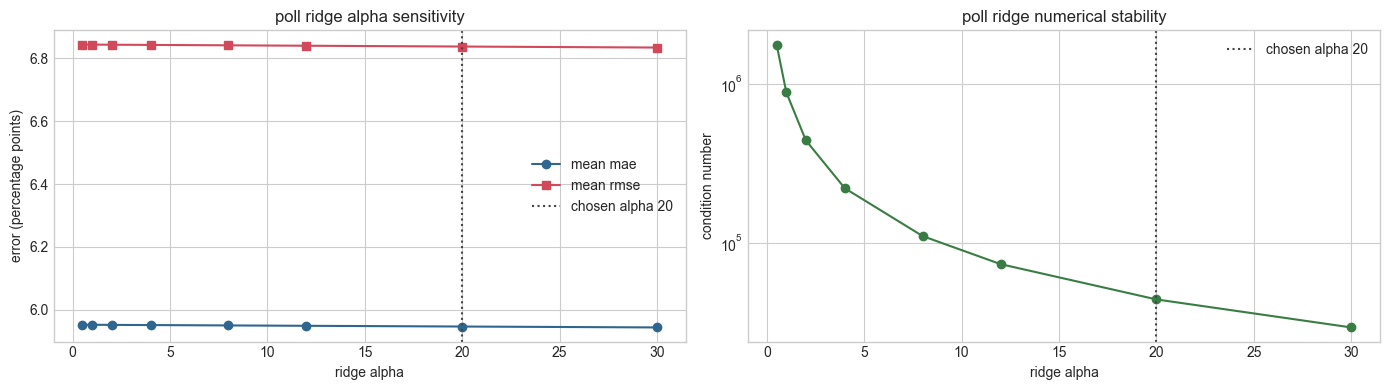

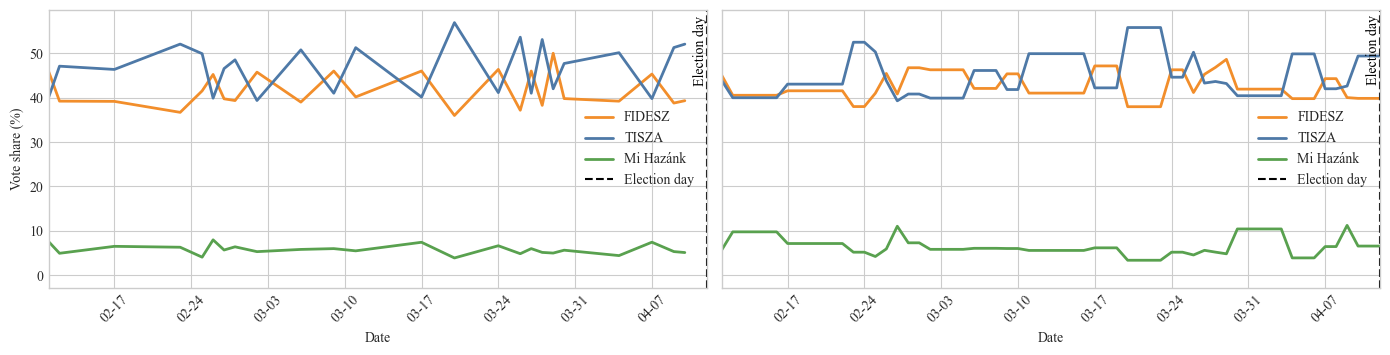

saved figure to:
/Users/andrasikristof/Documents/Egyetem/2026:27 - 2. félév/Election_predictions/graphs_tables/poll_path_2026.png
/Users/andrasikristof/Documents/Egyetem/2026:27 - 2. félév/Election_predictions/doc/ÚjLaTex_ENGLISH_Template másolat 2/figures/poll_path_2026.png


In [15]:
# this block builds or summarises the forecast and exports the 2026 poll path figure.

%matplotlib inline

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import display, Image

poll_forecast_alr = {}
poll_forecast_sd = {}

for block in nonbase_blocks:
    fit = fit_random_walk_series(
        poll_2026,
        value_col=f"corrected_alr_{block}",
        date_col="Vég",
        weight_col="sample_size",
        election_day=election_meta["2026_nat"]["date"],
    )
    poll_forecast_alr[block] = fit["mean"]
    poll_forecast_sd[block] = fit["sd"]
    poll_paths_2026[block] = fit

poll_forecast = inverse_alr(
    np.array([[poll_forecast_alr[block] for block in nonbase_blocks]]),
    block_cols
).iloc[0].to_dict()

poll_forecast = close_comp(
    pd.DataFrame([poll_forecast]),
    block_cols,
    eps=composition_floor
).iloc[0].to_dict()

poll_candidate_results["mixed_plus_random_walk_06"]["forecast_share"] = poll_forecast.copy()
poll_candidate_results["mixed_plus_random_walk_06"]["forecast_alr"] = {
    block: float(poll_forecast_alr[block]) for block in nonbase_blocks
}
poll_candidate_results["mixed_plus_random_walk_06"]["forecast_alr_sd"] = {
    block: float(poll_forecast_sd[block]) for block in nonbase_blocks
}

poll_2026_summary = pd.DataFrame(
    {
        "polls_in_window": [len(poll_2026)],
        "pollsters": [poll_2026["pollster"].nunique()],
        "first_poll": [poll_2026["Vég"].min().date()],
        "last_poll": [poll_2026["Vég"].max().date()],
        "fixed_election_day": [election_meta["2026_nat"]["date"].date()],
    }
)

main_poll_forecast = poll_candidate_results["simple_weighted_average"]["forecast_share"].copy()

poll_forecast_df = pd.DataFrame(
    {
        "source": ["simple_weighted_average main poll model"],
        **{block: [main_poll_forecast[block]] for block in block_cols},
    }
)

display(poll_2026_summary)
display(percent_table(poll_forecast_df, block_cols).round(2))

# build share-space path: joint inverse-alr on the daily filtered RW means
# use only dates where all nonbase blocks have a fitted daily random-walk path
series_dict = {b: poll_paths_2026[b]["predicted_mean"] for b in nonbase_blocks}
common_dates = series_dict[nonbase_blocks[0]].index

for b in nonbase_blocks[1:]:
    common_dates = common_dates.intersection(series_dict[b].index)

if len(common_dates) > 0:
    alr_obs = np.column_stack([series_dict[b].loc[common_dates].values for b in nonbase_blocks])
    shares_obs = inverse_alr(alr_obs, block_cols)
    shares_obs.index = common_dates
else:
    shares_obs = pd.DataFrame()

# build simple weighted-average share path: joint inverse-alr on the daily observed means
# use only dates where all nonbase blocks have an observed daily average inside the simple window
simple_series_dict = {
    b: fit_random_walk_series(
        poll_simple_2026,
        value_col=f"alr_{b}",
        date_col="Vég",
        weight_col="sample_size",
        election_day=election_meta["2026_nat"]["date"],
    )["series"].dropna()
    for b in nonbase_blocks
}
simple_common_dates = simple_series_dict[nonbase_blocks[0]].index

for b in nonbase_blocks[1:]:
    simple_common_dates = simple_common_dates.intersection(simple_series_dict[b].index)

if len(simple_common_dates) > 0:
    simple_alr_obs = np.column_stack([simple_series_dict[b].loc[simple_common_dates].values for b in nonbase_blocks])
    simple_shares_obs = inverse_alr(simple_alr_obs, block_cols)
    simple_shares_obs.index = simple_common_dates
else:
    simple_shares_obs = pd.DataFrame()

# create output paths
graphs_tables_dir = project_root / "graphs_tables"
graphs_tables_dir.mkdir(parents=True, exist_ok=True)

latex_figures_dir = project_root / "doc" / "ÚJLaTex_ENGLISH_Template másolat 2" / "figures"
latex_figures_dir.mkdir(parents=True, exist_ok=True)

output_graphs_tables_path = graphs_tables_dir / "poll_path_2026.png"
output_latex_figures_path = latex_figures_dir / "poll_path_2026.png"

print("simple common dates:", len(simple_common_dates))
print("simple shares_obs shape:", simple_shares_obs.shape)
print(simple_shares_obs.head())
print("house RW common dates:", len(common_dates))
print("house RW shares_obs shape:", shares_obs.shape)
print(shares_obs.head())

# plot the simple path and the fitted house-effect-corrected random-walk path side by side
plt.rcParams["font.family"] = "Times New Roman"
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharex=True, sharey=True)

label_map = {
    "gov": "FIDESZ",
    "opp": "TISZA",
    "opp_radical": "Mi Hazánk",
}

panel_specs = [
    (axes[0], simple_shares_obs),
    (axes[1], shares_obs),
]

election_day = pd.Timestamp(election_meta["2026_nat"]["date"])
shared_xmin = election_day - pd.Timedelta(days=60)
shared_xmax = election_day

for ax, panel_df in panel_specs:
    for j, block in enumerate(nonbase_blocks):
        if len(panel_df) > 0:
            fitted = panel_df.iloc[:, j] * 100
            ax.plot(
                fitted.index,
                fitted.values,
                label=label_map.get(block, block),
                linewidth=2,
                color=block_colors[block],
            )

    ax.axvline(election_day, color="black", linestyle="--", linewidth=1.5, label="Election day")
    ymax = ax.get_ylim()[1]
    ax.text(
        election_day,
        ymax * 0.98,
        "Election day",
        rotation=90,
        va="top",
        ha="right",
        fontsize=10,
        color="black",
    )
    ax.set_xlim(shared_xmin, shared_xmax)
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
    ax.set_xlabel("Date")
    ax.legend()
    ax.tick_params(axis="x", rotation=45)

axes[0].set_ylabel("Vote share (%)")
fig.suptitle("")
plt.tight_layout(rect=[0, 0, 1, 0.95])

# save to both locations
fig.savefig(output_graphs_tables_path, dpi=150, bbox_inches="tight")
fig.savefig(output_latex_figures_path, dpi=150, bbox_inches="tight")

# show the matplotlib figure
plt.show()

print("saved figure to:")
print(output_graphs_tables_path)
print(output_latex_figures_path)

Interpretation. Read this as the notebook forecast output under its own modelling assumptions.


### Build the Structural Feature Table

**Why this is necessary:** The fundamentals model needs district-level data in a wide format.
This step merges election results with demographic and economic statistics, creates per-1,000-resident
features, and prepares the 2026 prediction rows with the latest available structure data.


In [16]:
# this block builds the structural feature table.


result_wide = (
    final_results_oevk_party.groupby(
        ["year", "election_type", "oevk_id", "party_block"],
        as_index=False,
    )[["list_share", "cand_share", "list_votes", "cand_votes"]].sum()
    .pivot(index=["year", "election_type", "oevk_id"], columns="party_block", values=["list_share", "cand_share", "list_votes", "cand_votes"])
)
result_wide.columns = [f"{left}_{right}" for left, right in result_wide.columns]
result_wide = result_wide.reset_index()

for metric in ["list_share", "cand_share"]:
    for block in block_cols:
        col = f"{metric}_{block}"
        if col not in result_wide.columns:
            result_wide[col] = 0.0

result_wide = result_wide.merge(district_totals, on=["year", "election_type", "oevk_id"], how="left")
screened_feature_path = project_root / "data" / "created" / "screened_feature_sets.json"
if screened_feature_path.exists():
    screened_feature_config = json.loads(screened_feature_path.read_text(encoding="utf-8"))

downstream_recent_media_config = screened_feature_config.get("downstream_recent_media_config", {})
if isinstance(downstream_recent_media_config, dict):
    config_outlets = downstream_recent_media_config.get("selected_media_outlets")
    config_window = downstream_recent_media_config.get("selected_media_window")
    config_metric = downstream_recent_media_config.get("selected_media_metric")
    config_feature_cols = downstream_recent_media_config.get("selected_media_feature_cols")
    config_recent_features = downstream_recent_media_config.get("selected_recent_media_features")
    config_raw_cols = downstream_recent_media_config.get("selected_media_raw_cols")
    if (
        config_feature_cols == ["pro_gov_avg"]
        and config_recent_features == ["pro_gov_avg"]
        and isinstance(config_window, str)
        and isinstance(config_metric, str)
        and isinstance(config_outlets, list)
        and config_outlets
        and all(isinstance(outlet, str) for outlet in config_outlets)
    ):
        selected_single_media_outlet = downstream_recent_media_config.get(
            "selected_single_media_outlet",
            selected_single_media_outlet,
        )
        selected_media_window = config_window
        selected_media_metric = config_metric
        selected_media_outlets = config_outlets.copy()
        selected_media_raw_cols = [
            f"{selected_media_metric}_{selected_media_window}_{outlet}"
            for outlet in selected_media_outlets
        ]
        if (
            isinstance(config_raw_cols, list)
            and len(config_raw_cols) == len(selected_media_raw_cols)
            and all(isinstance(raw_col, str) for raw_col in config_raw_cols)
        ):
            selected_media_raw_cols = config_raw_cols.copy()

# Keep the recent media block fixed as one aggregated recent feature.
selected_recent_media_features = selected_media_feature_cols.copy()
screened_full_history_structure = [
    feature
    for feature in screened_feature_config.get("screened_full_history_structure", screened_full_history_structure)
]
preliminary_fundamentals_models = screened_feature_config.get(
    "preliminary_fundamentals_models",
    preliminary_fundamentals_models,
)

stat_features, structure_feature_candidates, structure_feature_metadata = build_expanded_structure_features(final_statistics_oevk)
stat_features["pro_gov_avg"] = build_pro_gov_avg_feature(stat_features, selected_media_raw_cols)
stat_features["media_selected_nonmissing_share"] = final_statistics_oevk[selected_media_raw_cols].notna().mean(axis=1)
stat_features["media_selected_available"] = (stat_features["media_selected_nonmissing_share"] > 0).astype(float)

feature_keep = [
    "year",
    "oevk_id",
    "county",
    "stat_region",
    "pop_total",
] + [
    feature for feature in screened_full_history_structure if feature in stat_features.columns
] + [
    feature for feature in selected_media_feature_cols if feature in stat_features.columns
]
feature_keep = list(dict.fromkeys(feature_keep))
stat_features = stat_features[feature_keep].copy()

media_check = final_statistics_oevk.copy()
media_check["pro_gov_avg"] = build_pro_gov_avg_feature(media_check, selected_media_raw_cols)
media_check["media_selected_nonmissing_share"] = media_check[selected_media_raw_cols].notna().mean(axis=1)
media_check["media_selected_available"] = (media_check["media_selected_nonmissing_share"] > 0).astype(float)
media_check = media_check.groupby("year", as_index=False).agg(
    rows=("oevk_id", "size"),
    avg_pro_gov_avg=("pro_gov_avg", "mean"),
    avg_selected_media_nonmissing_share=("media_selected_nonmissing_share", "mean"),
    selected_media_available_share=("media_selected_available", "mean"),
)

display(media_check.round(3))


,year,rows,avg_pro_gov_avg,avg_selected_media_nonmissing_share,selected_media_available_share
0,2018,106,NaN,0.0,0.0
1,2019,106,NaN,0.0,0.0
2,2022,106,6.171,1.0,1.0
3,2024,106,5.870,1.0,1.0
4,2026,106,5.702,1.0,1.0


Interpretation. Lower coverage means the variable is harder to use safely without imputation.


### Lag Helpers

**Why this is necessary:** Past election results are among the strongest predictors of future results.
A district that voted 60% government in 2022 is very likely to lean government in 2026 too.
"Lag" features attach the previous election's vote shares to each district row, so the model
can use historical voting patterns as predictors.

**Parameter note:** This section contains the lag mapping parameters `nat_prev_map` and `ep_prev_map`.


### Fundamentals Model Selection

**Why this is necessary:** We have many possible predictor sets (demographics only, plus economy,
plus cars and housing, plus media, plus lagged results). Instead of guessing which combination
is best, we test them all in a leave-one-election-out backtest and pick the winner.

We also compare ridge regression versus mixed-effects models to find the best functional form.

**Parameter note:** This section tunes and selects `screened_full_history_structure`,
`preliminary_fundamentals_models`, `selected_recent_media_features`, `selection_holdouts`,
`prior_ridge_alpha`, `prior_ridge_alpha_grid`, `full_history_min_nonmissing_share`,
`fixed_prior_model_kind`, and `selected_prior_model_features`.


In [17]:
# this block runs the fundamentals-model selection step.


nat_lookup = result_wide[result_wide["election_type"] == "nat"][["year", "oevk_id"] + [f"list_share_{block}" for block in block_cols] + ["valid_list_total", "valid_cand_total", "electorate_list"]].copy()
ep_lookup = result_wide[result_wide["election_type"] == "ep"][["year", "oevk_id"] + [f"list_share_{block}" for block in block_cols]].copy()

nat_prev_map = {2019: 2018, 2022: 2018, 2024: 2022, 2026: 2022}
ep_prev_map = {2022: 2019, 2024: 2019, 2026: 2024}


def add_share_lags(df):
    out = df.copy()
    for prefix in ["lag_nat", "lag_ep"]:
        for block in block_cols:
            out[f"{prefix}_{block}"] = np.nan
    out["lag_nat_valid_list_total"] = np.nan
    out["lag_nat_valid_cand_total"] = np.nan
    out["lag_nat_electorate"] = np.nan

    for target_year, source_year in nat_prev_map.items():
        rename_map = {f"list_share_{block}": f"lag_nat_{block}" for block in block_cols}
        rename_map["valid_list_total"] = "lag_nat_valid_list_total"
        rename_map["valid_cand_total"] = "lag_nat_valid_cand_total"
        rename_map["electorate_list"] = "lag_nat_electorate"
        src = nat_lookup[nat_lookup["year"] == source_year].rename(columns=rename_map).drop(columns="year")
        mask = out["year"] == target_year
        merged = out.loc[mask, ["oevk_id"]].merge(src, on="oevk_id", how="left")
        for block in block_cols:
            out.loc[mask, f"lag_nat_{block}"] = merged[f"lag_nat_{block}"].to_numpy()
        out.loc[mask, "lag_nat_valid_list_total"] = merged["lag_nat_valid_list_total"].to_numpy()
        out.loc[mask, "lag_nat_valid_cand_total"] = merged["lag_nat_valid_cand_total"].to_numpy()
        out.loc[mask, "lag_nat_electorate"] = merged["lag_nat_electorate"].to_numpy()

    for target_year, source_year in ep_prev_map.items():
        rename_map = {f"list_share_{block}": f"lag_ep_{block}" for block in block_cols}
        src = ep_lookup[ep_lookup["year"] == source_year].rename(columns=rename_map).drop(columns="year")
        mask = out["year"] == target_year
        merged = out.loc[mask, ["oevk_id"]].merge(src, on="oevk_id", how="left")
        for block in block_cols:
            out.loc[mask, f"lag_ep_{block}"] = merged[f"lag_ep_{block}"].to_numpy()

    out["has_lag_nat"] = out[[f"lag_nat_{block}" for block in block_cols]].notna().all(axis=1).astype(float)
    out["has_lag_ep"] = out[[f"lag_ep_{block}" for block in block_cols]].notna().all(axis=1).astype(float)
    out["forecast_weight"] = out["lag_nat_valid_list_total"].fillna(out["lag_nat_electorate"]).fillna(out["pop_total"]).fillna(1.0)
    return out


future_2026 = add_share_lags(stat_features[stat_features["year"] == 2026].copy())
future_2026["election_type"] = "nat"

lag_check = future_2026[["has_lag_nat", "has_lag_ep", "lag_nat_valid_list_total", "lag_nat_valid_cand_total"]].describe().T
display(lag_check.round(3))


,count,mean,std,min,25%,50%,75%,max
has_lag_nat,106.0,1.000,0.000,1.0,1.000,1.0,1.000,1.000
has_lag_ep,106.0,1.000,0.000,1.0,1.000,1.0,1.000,1.000
lag_nat_valid_list_total,106.0,51013.901,6342.911,37332.0,46453.492,50064.5,55823.759,68052.724
lag_nat_valid_cand_total,106.0,50906.655,6362.776,37283.0,46300.909,50019.0,55674.183,68015.774


**Interpretation:**
- The first table ("structural staircase") compares predictor sets from simple (demography only)
  to rich (demography + economy + cars + housing + doctors). Lower MAE is better.
- The second table shows whether adding lag features or media features improves recent-year accuracy.
- The third table compares ridge versus mixed-effects on the winning feature set.
- The feature screen table shows which features passed the 95% non-missing threshold.


In [18]:
# this block produces the interpretation outputs.
selection_stat_source, selection_structure_candidates, selection_feature_metadata = build_expanded_structure_features(final_statistics_oevk)
selection_stat_source["pro_gov_avg"] = build_pro_gov_avg_feature(selection_stat_source, selected_media_raw_cols)

selection_prior_base = add_share_lags(result_wide.merge(selection_stat_source, on=["year", "oevk_id"], how="left"))
selection_prior_base = pd.concat(
    [
        selection_prior_base.reset_index(drop=True),
        alr(
            selection_prior_base[[f"list_share_{block}" for block in block_cols]].rename(columns={f"list_share_{block}": block for block in block_cols}),
            block_cols,
        ).rename(columns={f"alr_{block}": f"target_alr_{block}" for block in nonbase_blocks}).reset_index(drop=True),
    ],
    axis=1,
)
selection_prior_base["fit_weight"] = selection_prior_base["valid_list_total"].fillna(selection_prior_base["electorate_list"]).fillna(1.0)
selection_prior_train = selection_prior_base[selection_prior_base["year"].isin([2018, 2019, 2022, 2024])].copy()
structure_cat_specs = [("stat_region", 1), ("election_type", 1)]
selection_prior_cat_specs = structure_cat_specs
selection_holdouts = [(2018, "nat"), (2019, "ep"), (2022, "nat"), (2024, "ep")]
prior_ridge_alpha = 100.0  # matches notebook 12 fixed alpha
prior_ridge_alpha_grid = np.array([2.0, 4.0, 8.0, 12.0, 20.0, 30.0, 40.0, 100.0], dtype="float64")


def evaluate_prior_candidate(feature_cols, model_kind="ridge", holdouts=None, ridge_alpha=None):
    if holdouts is None:
        holdouts = selection_holdouts
    ridge_alpha = prior_ridge_alpha if ridge_alpha is None else float(ridge_alpha)
    rows = []
    for year, etype in holdouts:
        election = f"{year}_{etype}"
        train = selection_prior_train[~((selection_prior_train["year"] == year) & (selection_prior_train["election_type"] == etype))].copy()
        test = selection_prior_train[(selection_prior_train["year"] == year) & (selection_prior_train["election_type"] == etype)].copy()
        if model_kind == "ridge":
            bundle = fit_ridge_bundle(
                train,
                [f"target_alr_{block}" for block in nonbase_blocks],
                feature_cols,
                selection_prior_cat_specs,
                "fit_weight",
                alpha=ridge_alpha,
            )
            pred_alr = predict_ridge_bundle(bundle, test)
        else:
            pred_parts = []
            for block in nonbase_blocks:
                model = fit_random_intercept(train, f"target_alr_{block}", feature_cols, selection_prior_cat_specs, "county")
                pred_parts.append(predict_random_intercept(model, test))
            pred_alr = np.column_stack(pred_parts)
        pred_comp = inverse_alr(pred_alr, block_cols)
        pred_comp.columns = [f"pred_{block}" for block in block_cols]
        tmp = pd.concat([test.reset_index(drop=True), pred_comp.reset_index(drop=True)], axis=1)
        weights = tmp["fit_weight"].to_numpy(dtype="float64")
        actual_row = actual_national_wide[actual_national_wide["election"] == election].iloc[0]
        pred_nat = {
            block: safe_weighted_average(tmp[f"pred_{block}"], weights)
            for block in block_cols
        }
        rows.append(
            {
                "election": election,
                "model_kind": model_kind,
                "district_mae": float(np.mean([np.abs(tmp[f"pred_{block}"] - tmp[f"list_share_{block}"]).mean() for block in block_cols])),
                "national_mae": float(np.mean([abs(pred_nat[block] - float(actual_row[block])) for block in block_cols])),
            }
        )
    return pd.DataFrame(rows)


prior_structure_rows = []
for model_name, feature_cols in preliminary_fundamentals_models.items():
    valid_features = [feature for feature in feature_cols if feature in selection_prior_train.columns]
    result = evaluate_prior_candidate(valid_features, model_kind="ridge")
    prior_structure_rows.append(
        {
            "scenario": model_name,
            "feature_count": len(valid_features),
            "mean_national_mae": float(result["national_mae"].mean()),
            "mean_district_mae": float(result["district_mae"].mean()),
        }
    )
prior_structure_summary = pd.DataFrame(prior_structure_rows).sort_values(["mean_national_mae", "mean_district_mae"]).reset_index(drop=True)
best_prior_structure = prior_structure_summary.iloc[0]["scenario"]
best_prior_structure_features = [
    feature
    for feature in preliminary_fundamentals_models.get(best_prior_structure, [])
    if feature in selection_prior_train.columns
]

share_lag_features = ["has_lag_nat", "has_lag_ep"] + [f"lag_nat_{block}" for block in block_cols] + [f"lag_ep_{block}" for block in block_cols]
prior_recent_rows = []
recent_holdouts = [(2022, "nat"), (2024, "ep")]
for scenario_name, feature_cols in {
    "base_structure_recent": best_prior_structure_features,
    "plus_lags_recent": best_prior_structure_features + share_lag_features,
    "plus_media_recent": best_prior_structure_features + selected_recent_media_features,
    "plus_lags_plus_media_recent": best_prior_structure_features + share_lag_features + selected_recent_media_features,
}.items():
    valid_features = [feature for feature in feature_cols if feature in selection_prior_train.columns]
    result = evaluate_prior_candidate(valid_features, model_kind="ridge", holdouts=recent_holdouts)
    prior_recent_rows.append(
        {
            "scenario": scenario_name,
            "feature_count": len(valid_features),
            "mean_national_mae": float(result["national_mae"].mean()),
            "mean_district_mae": float(result["district_mae"].mean()),
        }
    )
prior_recent_summary = pd.DataFrame(prior_recent_rows).sort_values(["mean_national_mae", "mean_district_mae"]).reset_index(drop=True)
best_recent_prior_scenario = prior_recent_summary.iloc[0]["scenario"]
prior_feature_map = {
    "base_structure_recent": best_prior_structure_features,
    "plus_lags_recent": best_prior_structure_features + share_lag_features,
    "plus_media_recent": best_prior_structure_features + selected_recent_media_features,
    "plus_lags_plus_media_recent": best_prior_structure_features + share_lag_features + selected_recent_media_features,
}
# Media is deliberately kept out of the prior layer because pro_gov_avg only exists
# for 2022 and 2024 (50% coverage across the 4 backtesting elections). Instead, media
# enters through the recent correction layer (Stage 3) where only 2022/2024 data is used.
# The prior commits to the LOEO winning base structure from the Stage 1 winner.
selected_prior_model_features_raw = [
    feature
    for feature in best_prior_structure_features
    if feature in selection_prior_train.columns
]
selected_prior_model_features, dropped_prior_sparse_features, prior_selected_feature_screen = screen_sparse_features(
    selection_prior_train,
    selected_prior_model_features_raw,
    min_nonmissing_share=full_history_min_nonmissing_share,
    grouped_prefixes=[
        ("has_lag_nat", "lag_nat_"),
        ("has_lag_ep", "lag_ep_"),
    ],
)
if not selected_prior_model_features:
    selected_prior_model_features = best_prior_structure_features.copy()
    dropped_prior_sparse_features = []
    prior_selected_feature_screen = (
        feature_coverage_table(selection_prior_train, selected_prior_model_features)
        .assign(used_downstream=True)
    )

# Parsimony rule: ridge is committed to ex ante for the prior layer.
# With only 4 backtesting elections the ridge vs random-intercept difference is within noise,
# and ridge is simpler (no random-effect estimation). The mixed comparison is kept as a
# robustness check, not as a selection mechanism.
prior_form_compare = []
for model_kind in ["ridge", "mixed"]:
    result = evaluate_prior_candidate(selected_prior_model_features, model_kind=model_kind)
    prior_form_compare.append(
        {
            "model_kind": model_kind,
            "feature_count": len(selected_prior_model_features),
            "mean_national_mae": float(result["national_mae"].mean()),
            "mean_district_mae": float(result["district_mae"].mean()),
        }
    )
prior_form_compare = pd.DataFrame(prior_form_compare).sort_values(["mean_national_mae", "mean_district_mae"]).reset_index(drop=True)

fixed_prior_model_kind = "ridge"  # hardcoded: ridge chosen ex ante for parsimony
# Structure features also stay media-free; media enters via the correction layer.
selected_structure_feature_set_raw = best_prior_structure_features.copy()
selected_structure_feature_set, dropped_structure_sparse_features, selected_structure_feature_screen = screen_sparse_features(
    selection_prior_train,
    list(dict.fromkeys(selected_structure_feature_set_raw)),
    min_nonmissing_share=full_history_min_nonmissing_share,
)
if not selected_structure_feature_set:
    selected_structure_feature_set = best_prior_structure_features.copy()
    dropped_structure_sparse_features = []
    selected_structure_feature_screen = (
        feature_coverage_table(selection_prior_train, selected_structure_feature_set)
        .assign(used_downstream=True)
    )

prior_availability_screen_summary = pd.DataFrame(
    {
        "item": [
            "full-history nonmissing threshold",
            "raw recent winner feature count",
            "downstream prior feature count",
            "dropped sparse prior features",
            "downstream structure/media feature count",
            "dropped sparse structure/media features",
        ],
        "value": [
            full_history_min_nonmissing_share,
            len(selected_prior_model_features_raw),
            len(selected_prior_model_features),
            ", ".join(dropped_prior_sparse_features) if dropped_prior_sparse_features else "none",
            len(selected_structure_feature_set),
            ", ".join(dropped_structure_sparse_features) if dropped_structure_sparse_features else "none",
        ],
    }
)

display(prior_structure_summary.round(4))
display(prior_recent_summary.round(4))
display(prior_form_compare.round(4))
display(prior_availability_screen_summary)
display(prior_selected_feature_screen.round(3))


,scenario,feature_count,mean_national_mae,mean_district_mae
0,model_1_demography_only,3,0.0669,0.0706
1,model_2_plus_core_economy,6,0.0717,0.0738
2,model_3_plus_modernization,8,0.0864,0.0880
3,model_4_plus_public_service_housing,10,0.0865,0.0880


,scenario,feature_count,mean_national_mae,mean_district_mae
0,base_structure_recent,3,0.0674,0.0705
1,plus_media_recent,4,0.0698,0.0731
2,plus_lags_plus_media_recent,14,0.0782,0.0808
3,plus_lags_recent,13,0.0832,0.0859


,model_kind,feature_count,mean_national_mae,mean_district_mae
0,ridge,3,0.0669,0.0706
1,mixed,3,0.0678,0.0715


,item,value
0,full-history nonmissing threshold,0.95
1,raw recent winner feature count,3
2,downstream prior feature count,3
3,dropped sparse prior features,none
4,downstream structure/media feature count,3
5,dropped sparse structure/media features,none


,feature,nonmissing_share,used_downstream
0,log_pop_total,1.0,True
1,old_share,1.0,True
2,young_share,1.0,True


**Interpretation:** The tables above show the fundamentals model selection results.
The first table uses LOEO to choose the base prior structure, and in the current notebook that winner is `model_1_demography_only`.
The recent extension table is a follow-up check only. Downstream, the prior keeps the LOEO winning base structure and keeps ridge by rule for parsimony.
The `lag_plus_media` part enters later in the recent correction layer, not as the selected prior structure itself.
Features with too many missing values are dropped. The alpha sensitivity table (if shown)
checks that the ridge penalty choice is not driving the results.


### National Fundamentals Prior

**Why this is necessary:** Polls are only one source of information. The fundamentals model uses
district demographics, economic data, and past results to estimate what the national vote share
"should" be based on structural factors alone. This serves as a prior (starting guess) that the
poll data will then update.

The model is fitted at the district level in log-ratio space, then aggregated back to national level.


In [19]:
# this block works on the fundamentals prior layer.
prior_base = add_share_lags(result_wide.merge(stat_features, on=["year", "oevk_id"], how="left"))
prior_base = prior_base.merge(
    alr(
        prior_base[[f"list_share_{block}" for block in block_cols]].rename(columns={f"list_share_{block}": block for block in block_cols}),
        block_cols,
    ),
    left_index=True,
    right_index=True,
    how="left",
)
prior_base = prior_base.rename(columns={f"alr_{block}": f"target_alr_{block}" for block in nonbase_blocks})
prior_base["fit_weight"] = prior_base["valid_list_total"].fillna(prior_base["electorate_list"]).fillna(1.0)

prior_cat_specs = structure_cat_specs
prior_train = prior_base[prior_base["year"].isin([2018, 2019, 2022, 2024])].copy()
prior_features = [feature for feature in selected_prior_model_features if feature in prior_train.columns]

prior_backtest_rows = []
prior_backtest_errors = []
prior_models = {}

def evaluate_prior_ridge_alpha(alpha):
    rows = []
    for holdout in [(2018, "nat"), (2019, "ep"), (2022, "nat"), (2024, "ep")]:
        year, etype = holdout
        election = f"{year}_{etype}"
        train = prior_train[~((prior_train["year"] == year) & (prior_train["election_type"] == etype))].copy()
        test = prior_train[(prior_train["year"] == year) & (prior_train["election_type"] == etype)].copy()

        prior_bundle = fit_ridge_bundle(
            train,
            [f"target_alr_{block}" for block in nonbase_blocks],
            prior_features,
            prior_cat_specs,
            "fit_weight",
            alpha=float(alpha),
        )
        pred_alr = predict_ridge_bundle(prior_bundle, test)
        for idx, block in enumerate(nonbase_blocks):
            test[f"pred_alr_{block}"] = pred_alr[:, idx]

        pred_comp = inverse_alr(pred_alr, block_cols)
        for block in block_cols:
            test[f"pred_{block}"] = pred_comp[block].to_numpy()

        weights = test["valid_list_total"].fillna(test["electorate_list"]).fillna(1.0).to_numpy(dtype="float64")
        row = {
            "election": election,
            "district_mae": float(np.mean([np.abs(test[f"pred_{block}"] - test[f"list_share_{block}"]).mean() for block in block_cols])),
        }
        pred_nat = {}
        for block in block_cols:
            pred_nat[block] = safe_weighted_average(test[f"pred_{block}"], weights)
            actual_nat = safe_weighted_average(test[f"list_share_{block}"], weights)
            row[f"pred_{block}"] = pred_nat[block]
            row[f"actual_{block}"] = actual_nat
            row[f"abs_err_{block}"] = abs(pred_nat[block] - actual_nat)

        pred_nat_alr = alr(pd.DataFrame([pred_nat]), block_cols).iloc[0]
        actual_row = actual_national_wide[actual_national_wide["election"] == election].iloc[0]
        for block in nonbase_blocks:
            row[f"pred_alr_{block}"] = float(pred_nat_alr[f"alr_{block}"])
            row[f"actual_alr_{block}"] = float(actual_row[f"actual_alr_{block}"])
            row[f"alr_err_{block}"] = row[f"pred_alr_{block}"] - row[f"actual_alr_{block}"]
        row["mae"] = float(np.mean([row[f"abs_err_{block}"] for block in block_cols]))
        row["rmse"] = float(np.sqrt(np.mean([(pred_nat[block] - float(actual_row[block])) ** 2 for block in block_cols])))
        rows.append(row)
    return pd.DataFrame(rows)


prior_alpha_summary = pd.DataFrame()
prior_alpha_focus = pd.DataFrame()

if fixed_prior_model_kind == "ridge":
    prior_design_train, _, _ = build_design(prior_train, future_2026, prior_features, prior_cat_specs)
    prior_X_train = prior_design_train.to_numpy(dtype="float64")
    prior_Y_train = prior_train[[f"target_alr_{block}" for block in nonbase_blocks]].to_numpy(dtype="float64")
    prior_w_train = prior_train["fit_weight"].fillna(1.0).to_numpy(dtype="float64")
    prior_alpha_rows = []
    prior_alpha_backtests = {}
    prior_alpha_forecasts = {}

    for alpha in prior_ridge_alpha_grid:
        alpha = float(alpha)
        backtest_df = evaluate_prior_ridge_alpha(alpha)
        prior_alpha_backtests[alpha] = backtest_df

        prior_bundle_full = fit_ridge_bundle(
            prior_train,
            [f"target_alr_{block}" for block in nonbase_blocks],
            prior_features,
            prior_cat_specs,
            "fit_weight",
            alpha=alpha,
        )
        diagnostics = ridge_design_diagnostics(prior_X_train, prior_w_train, alpha, prior_bundle_full["beta"])

        pred_alr_2026 = predict_ridge_bundle(prior_bundle_full, future_2026)
        pred_comp_2026 = inverse_alr(pred_alr_2026, block_cols)
        forecast_map = {
            block: safe_weighted_average(pred_comp_2026[block], future_2026["forecast_weight"])
            for block in block_cols
        }
        forecast_map = close_comp(pd.DataFrame([forecast_map]), block_cols, eps=composition_floor).iloc[0].to_dict()
        prior_alpha_forecasts[alpha] = forecast_map

        holdout_mae = backtest_df["mae"].to_numpy(dtype="float64")
        prior_alpha_rows.append(
            {
                "alpha": alpha,
                "mean_mae": float(backtest_df["mae"].mean()),
                "mean_rmse": float(backtest_df["rmse"].mean()),
                "mean_district_mae": float(backtest_df["district_mae"].mean()),
                "sd_mae_across_holdouts": float(np.std(holdout_mae, ddof=1)),
                "se_mean_mae": float(np.std(holdout_mae, ddof=1) / np.sqrt(len(holdout_mae))),
                **diagnostics,
            }
        )

    prior_alpha_summary = pd.DataFrame(prior_alpha_rows).sort_values("alpha").reset_index(drop=True)
    prior_best_mae = float(prior_alpha_summary["mean_mae"].min())
    prior_best_rmse = float(prior_alpha_summary["mean_rmse"].min())
    prior_selected_forecast = prior_alpha_forecasts[float(prior_ridge_alpha)]
    prior_alpha_summary["mae_gap_to_best_pp"] = 100.0 * (prior_alpha_summary["mean_mae"] - prior_best_mae)
    prior_alpha_summary["rmse_gap_to_best_pp"] = 100.0 * (prior_alpha_summary["mean_rmse"] - prior_best_rmse)
    prior_alpha_summary["max_forecast_shift_vs_alpha_20_pp"] = prior_alpha_summary["alpha"].apply(
        lambda alpha: 100.0 * max(
            abs(float(prior_alpha_forecasts[float(alpha)][block]) - float(prior_selected_forecast[block]))
            for block in block_cols
        )
    )
    prior_alpha_summary["selected_alpha"] = prior_alpha_summary["alpha"].eq(float(prior_ridge_alpha))
    prior_alpha_focus = (
        prior_alpha_summary[prior_alpha_summary["alpha"].isin([4.0, 8.0, 12.0, prior_ridge_alpha, 30.0, 40.0])]
        .copy()
        .reset_index(drop=True)
    )

    display(prior_alpha_summary.round(6))
    display(prior_alpha_focus.round(6))

    prior_backtest = prior_alpha_backtests[float(prior_ridge_alpha)].copy()
    prior_backtest_rows = prior_backtest.to_dict("records")
    prior_backtest_errors = prior_backtest[[f"alr_err_{block}" for block in nonbase_blocks]].to_numpy(dtype="float64").tolist()
    prior_models["bundle"] = fit_ridge_bundle(
        prior_train,
        [f"target_alr_{block}" for block in nonbase_blocks],
        prior_features,
        prior_cat_specs,
        "fit_weight",
        alpha=prior_ridge_alpha,
    )
    future_alr = predict_ridge_bundle(prior_models["bundle"], future_2026)
    for idx, block in enumerate(nonbase_blocks):
        future_2026[f"pred_alr_{block}"] = future_alr[:, idx]
else:
    for holdout in [(2018, "nat"), (2019, "ep"), (2022, "nat"), (2024, "ep")]:
        year, etype = holdout
        election = f"{year}_{etype}"
        train = prior_train[~((prior_train["year"] == year) & (prior_train["election_type"] == etype))].copy()
        test = prior_train[(prior_train["year"] == year) & (prior_train["election_type"] == etype)].copy()

        pred_parts = []
        for block in nonbase_blocks:
            model = fit_random_intercept(train, f"target_alr_{block}", prior_features, prior_cat_specs, "county")
            pred = predict_random_intercept(model, test)
            test[f"pred_alr_{block}"] = pred
            pred_parts.append(pred)
        pred_alr = np.column_stack(pred_parts)

        pred_comp = inverse_alr(pred_alr, block_cols)
        for block in block_cols:
            test[f"pred_{block}"] = pred_comp[block].to_numpy()

        weights = test["valid_list_total"].fillna(test["electorate_list"]).fillna(1.0).to_numpy(dtype="float64")
        row = {"election": election}
        pred_nat = {}
        for block in block_cols:
            pred_nat[block] = safe_weighted_average(test[f"pred_{block}"], weights)
            actual_nat = safe_weighted_average(test[f"list_share_{block}"], weights)
            row[f"pred_{block}"] = pred_nat[block]
            row[f"actual_{block}"] = actual_nat
            row[f"abs_err_{block}"] = abs(pred_nat[block] - actual_nat)

        pred_nat_alr = alr(pd.DataFrame([pred_nat]), block_cols).iloc[0]
        actual_row = actual_national_wide[actual_national_wide["election"] == election].iloc[0]
        for block in nonbase_blocks:
            row[f"pred_alr_{block}"] = float(pred_nat_alr[f"alr_{block}"])
            row[f"actual_alr_{block}"] = float(actual_row[f"actual_alr_{block}"])
            row[f"alr_err_{block}"] = row[f"pred_alr_{block}"] - row[f"actual_alr_{block}"]
        row["mae"] = float(np.mean([row[f"abs_err_{block}"] for block in block_cols]))
        prior_backtest_rows.append(row)
        prior_backtest_errors.append([row[f"alr_err_{block}"] for block in nonbase_blocks])

    for block in nonbase_blocks:
        prior_models[block] = fit_random_intercept(prior_train, f"target_alr_{block}", prior_features, prior_cat_specs, "county")
        future_2026[f"pred_alr_{block}"] = predict_random_intercept(prior_models[block], future_2026)

prior_2026_comp = inverse_alr(future_2026[[f"pred_alr_{block}" for block in nonbase_blocks]].to_numpy(dtype="float64"), block_cols)
for block in block_cols:
    future_2026[f"pred_{block}"] = prior_2026_comp[block].to_numpy()

prior_forecast = {
    block: safe_weighted_average(future_2026[f"pred_{block}"], future_2026["forecast_weight"])
    for block in block_cols
}
prior_forecast = close_comp(pd.DataFrame([prior_forecast]), block_cols, eps=composition_floor).iloc[0].to_dict()
prior_forecast_alr = alr(pd.DataFrame([prior_forecast]), block_cols).iloc[0]
if fixed_prior_model_kind != "ridge":
    prior_backtest = pd.DataFrame(prior_backtest_rows)

display(percent_table(prior_backtest[["election", "mae"]], ["mae"]).round(2))
display(percent_table(pd.DataFrame([prior_forecast]), block_cols).round(2))


,alpha,mean_mae,mean_rmse,mean_district_mae,sd_mae_across_holdouts,se_mean_mae,condition_number_full_fit,effective_df_full_fit,coef_norm_full_fit,mae_gap_to_best_pp,rmse_gap_to_best_pp,max_forecast_shift_vs_alpha_20_pp,selected_alpha
0,2.0,0.066951,0.075470,0.070602,0.007201,0.003601,96.108402,7.999993,1.701632,0.000121,0.000139,0.000079,False
1,4.0,0.066951,0.075470,0.070602,0.007201,0.003601,96.107939,7.999986,1.701628,0.000119,0.000136,0.000077,False
2,8.0,0.066951,0.075470,0.070602,0.007201,0.003601,96.107014,7.999971,1.701621,0.000114,0.000131,0.000074,False
3,12.0,0.066951,0.075470,0.070602,0.007201,0.003601,96.106088,7.999957,1.701613,0.000109,0.000125,0.000071,False
4,20.0,0.066951,0.075470,0.070602,0.007201,0.003600,96.104237,7.999928,1.701599,0.000099,0.000114,0.000064,False
5,30.0,0.066951,0.075470,0.070601,0.007201,0.003600,96.101923,7.999892,1.701580,0.000087,0.000099,0.000056,False
6,40.0,0.066951,0.075470,0.070601,0.007201,0.003600,96.099609,7.999855,1.701561,0.000074,0.000085,0.000048,False
7,100.0,0.066950,0.075469,0.070601,0.007200,0.003600,96.085728,7.999638,1.701450,0.000000,0.000000,0.000000,True


,alpha,mean_mae,mean_rmse,mean_district_mae,sd_mae_across_holdouts,se_mean_mae,condition_number_full_fit,effective_df_full_fit,coef_norm_full_fit,mae_gap_to_best_pp,rmse_gap_to_best_pp,max_forecast_shift_vs_alpha_20_pp,selected_alpha
0,4.0,0.066951,0.075470,0.070602,0.007201,0.003601,96.107939,7.999986,1.701628,0.000119,0.000136,0.000077,False
1,8.0,0.066951,0.075470,0.070602,0.007201,0.003601,96.107014,7.999971,1.701621,0.000114,0.000131,0.000074,False
2,12.0,0.066951,0.075470,0.070602,0.007201,0.003601,96.106088,7.999957,1.701613,0.000109,0.000125,0.000071,False
3,30.0,0.066951,0.075470,0.070601,0.007201,0.003600,96.101923,7.999892,1.701580,0.000087,0.000099,0.000056,False
4,40.0,0.066951,0.075470,0.070601,0.007201,0.003600,96.099609,7.999855,1.701561,0.000074,0.000085,0.000048,False
5,100.0,0.066950,0.075469,0.070601,0.007200,0.003600,96.085728,7.999638,1.701450,0.000000,0.000000,0.000000,True


,election,mae
0,2018_nat,7.11
1,2019_ep,6.20
2,2022_nat,7.49
3,2024_ep,5.98


,gov,opp,opp_radical,other
0,50.31,33.45,10.41,5.82


**Interpretation:** The backtest MAE shows how well the fundamentals model predicts national
vote shares when each election is left out. The 2026 forecast row shows the fundamentals-only
prediction. This is usually less accurate than polls close to election day, but it provides
a useful anchor, especially when polls are noisy or scarce.


### Local Lean Model

**Why this is necessary:** National vote shares tell us the overall picture, but elections are
won district by district. Each OEVK "leans" toward one side more or less than the national
average. For example, downtown Budapest leans opposition, while rural areas lean government.

The lean model measures and predicts these local deviations from the national result.
We use demographics, lagged lean from past elections, and media features to explain why
each district is different.

**Parameter note:** This section builds the lean inputs from `selected_structure_feature_set`,
lagged lean variables, and the sparse feature threshold `full_history_min_nonmissing_share = 0.95`.


In [20]:
# this block works on the district lean layer.
lean_hist = result_wide.merge(stat_features, on=["year", "oevk_id"], how="left")
district_list_input = lean_hist[[f"list_share_{block}" for block in block_cols]].rename(columns={f"list_share_{block}": block for block in block_cols})
district_list_alr = alr(district_list_input, block_cols)
district_list_alr.columns = [f"list_alr_{block}" for block in nonbase_blocks]
lean_hist = pd.concat([lean_hist.reset_index(drop=True), district_list_alr.reset_index(drop=True)], axis=1)

national_rows = []
for (year, etype), group in lean_hist.groupby(["year", "election_type"]):
    weights = group["valid_list_total"].fillna(1.0).to_numpy(dtype="float64")
    row = {"year": year, "election_type": etype}
    nat_share = {}
    for block in block_cols:
        nat_share[block] = safe_weighted_average(group[f"list_share_{block}"], weights)
    nat_alr = alr(pd.DataFrame([nat_share]), block_cols).iloc[0]
    for block in block_cols:
        row[f"nat_{block}"] = nat_share[block]
    for block in nonbase_blocks:
        row[f"nat_alr_{block}"] = float(nat_alr[f"alr_{block}"])
    national_rows.append(row)

national_level = pd.DataFrame(national_rows)
lean_hist = lean_hist.merge(national_level, on=["year", "election_type"], how="left")
for block in nonbase_blocks:
    lean_hist[f"lean_alr_{block}"] = lean_hist[f"list_alr_{block}"] - lean_hist[f"nat_alr_{block}"]

nat_lean_lookup = lean_hist[lean_hist["election_type"] == "nat"][["year", "oevk_id"] + [f"lean_alr_{block}" for block in nonbase_blocks]].copy()
ep_lean_lookup = lean_hist[lean_hist["election_type"] == "ep"][["year", "oevk_id"] + [f"lean_alr_{block}" for block in nonbase_blocks]].copy()


def add_lean_lags(df):
    out = df.copy()
    for prefix in ["lag_nat_lean", "lag_ep_lean"]:
        for block in nonbase_blocks:
            out[f"{prefix}_{block}"] = np.nan

    for target_year, source_year in nat_prev_map.items():
        rename_map = {f"lean_alr_{block}": f"lag_nat_lean_{block}" for block in nonbase_blocks}
        src = nat_lean_lookup[nat_lean_lookup["year"] == source_year].rename(columns=rename_map).drop(columns="year")
        mask = out["year"] == target_year
        merged = out.loc[mask, ["oevk_id"]].merge(src, on="oevk_id", how="left")
        for block in nonbase_blocks:
            out.loc[mask, f"lag_nat_lean_{block}"] = merged[f"lag_nat_lean_{block}"].to_numpy()

    for target_year, source_year in ep_prev_map.items():
        rename_map = {f"lean_alr_{block}": f"lag_ep_lean_{block}" for block in nonbase_blocks}
        src = ep_lean_lookup[ep_lean_lookup["year"] == source_year].rename(columns=rename_map).drop(columns="year")
        mask = out["year"] == target_year
        merged = out.loc[mask, ["oevk_id"]].merge(src, on="oevk_id", how="left")
        for block in nonbase_blocks:
            out.loc[mask, f"lag_ep_lean_{block}"] = merged[f"lag_ep_lean_{block}"].to_numpy()

    out["has_lag_nat_lean"] = out[[f"lag_nat_lean_{block}" for block in nonbase_blocks]].notna().all(axis=1).astype(float)
    out["has_lag_ep_lean"] = out[[f"lag_ep_lean_{block}" for block in nonbase_blocks]].notna().all(axis=1).astype(float)
    return out


lean_train = add_lean_lags(lean_hist[lean_hist["year"].isin([2018, 2019, 2022, 2024])].copy())
lean_2026 = add_lean_lags(future_2026.copy())

lean_features_raw = selected_structure_feature_set.copy()
lean_features, dropped_lean_sparse_features, lean_feature_screen = screen_sparse_features(
    lean_train,
    lean_features_raw,
    min_nonmissing_share=full_history_min_nonmissing_share,
)
if not lean_features:
    lean_features = selected_structure_feature_set.copy()
    dropped_lean_sparse_features = []
    lean_feature_screen = (
        feature_coverage_table(lean_train, lean_features)
        .assign(used_downstream=True)
    )

lean_ridge_alpha = 30.0  # matches notebook 12 fixed alpha
lean_ridge_alpha_grid = np.array([2.0, 4.0, 8.0, 12.0, 15.0, 20.0, 30.0], dtype="float64")

lean_availability_screen_summary = pd.DataFrame(
    {
        "item": [
            "full-history nonmissing threshold",
            "raw lean feature count",
            "downstream lean feature count",
            "dropped sparse lean features",
        ],
        "value": [
            full_history_min_nonmissing_share,
            len(lean_features_raw),
            len(lean_features),
            ", ".join(dropped_lean_sparse_features) if dropped_lean_sparse_features else "none",
        ],
    }
)

lean_backtest_rows = []
lean_residual_rows = []
lean_models = {}
fixed_lean_model = "alr_lean_mixed_06"

for holdout in [(2018, "nat"), (2019, "ep"), (2022, "nat"), (2024, "ep")]:
    year, etype = holdout
    election = f"{year}_{etype}"
    train = lean_train[~((lean_train["year"] == year) & (lean_train["election_type"] == etype))].copy()
    test = lean_train[(lean_train["year"] == year) & (lean_train["election_type"] == etype)].copy()

    if fixed_lean_model == "alr_lean_ridge":
        lean_bundle = fit_ridge_bundle(
            train,
            [f"lean_alr_{block}" for block in nonbase_blocks],
            lean_features,
            prior_cat_specs,
            "valid_list_total",
            alpha=lean_ridge_alpha,
        )
        pred_matrix = predict_ridge_bundle(lean_bundle, test)
        for idx, block in enumerate(nonbase_blocks):
            test[f"pred_lean_alr_{block}"] = pred_matrix[:, idx]
    else:
        for block in nonbase_blocks:
            model = fit_random_intercept(train, f"lean_alr_{block}", lean_features, prior_cat_specs, "county")
            pred = predict_random_intercept(model, test)
            test[f"pred_lean_alr_{block}"] = pred

    alr_matrix = []
    for block in nonbase_blocks:
        alr_matrix.append(test[f"nat_alr_{block}"].to_numpy(dtype="float64") + test[f"pred_lean_alr_{block}"].to_numpy(dtype="float64"))
    pred_comp = inverse_alr(np.column_stack(alr_matrix), block_cols)
    for block in block_cols:
        test[f"pred_{block}"] = pred_comp[block].to_numpy()

    lean_residual_rows.extend(
        [
            {
                "election": election,
                "oevk_id": oevk_id,
                "block": block,
                "resid": actual - fitted,
            }
            for block in nonbase_blocks
            for oevk_id, actual, fitted in zip(
                test["oevk_id"],
                test[f"lean_alr_{block}"],
                test[f"pred_lean_alr_{block}"],
            )
        ]
    )

    lean_backtest_rows.append(
        {
            "election": election,
            "district_mae": float(np.mean([np.abs(test[f"pred_{block}"] - test[f"list_share_{block}"]).mean() for block in block_cols])),
        }
    )

if fixed_lean_model == "alr_lean_ridge":
    lean_models["bundle"] = fit_ridge_bundle(
        lean_train,
        [f"lean_alr_{block}" for block in nonbase_blocks],
        lean_features,
        prior_cat_specs,
        "valid_list_total",
        alpha=lean_ridge_alpha,
    )
    lean_2026_pred = predict_ridge_bundle(lean_models["bundle"], lean_2026)
    for idx, block in enumerate(nonbase_blocks):
        lean_2026[f"pred_lean_alr_{block}"] = lean_2026_pred[:, idx]
else:
    for block in nonbase_blocks:
        lean_models[block] = fit_random_intercept(lean_train, f"lean_alr_{block}", lean_features, prior_cat_specs, "county")
        lean_2026[f"pred_lean_alr_{block}"] = predict_random_intercept(lean_models[block], lean_2026)

lean_backtest = pd.DataFrame(lean_backtest_rows)
lean_residual_df = pd.DataFrame(lean_residual_rows)
lean_residual_matrix = (
    lean_residual_df.pivot(index=["election", "oevk_id"], columns="block", values="resid")
    .reindex(columns=nonbase_blocks)
    .fillna(0.0)
)
lean_cov = stabilize_cov(np.cov(lean_residual_matrix.to_numpy(dtype="float64"), rowvar=False))

lean_scope_note = pd.DataFrame(
    {
        "item": [
            "scope before this cell",
            "scope of this cell",
        ],
        "value": [
            "the fundamentals prior and the national poll-path forecasts above are countrywide list-vote point estimates, not OEVK-level outputs",
            "this cell starts the OEVK lean layer by modelling district deviations around the national baseline",
        ],
    }
)

display(lean_scope_note)
display(percent_table(lean_backtest, ["district_mae"]).round(2))
display(lean_availability_screen_summary)
display(lean_feature_screen.round(3))


,item,value
0,scope before this cell,the fundamentals prior and the national poll-p...
1,scope of this cell,this cell starts the OEVK lean layer by modell...


,election,district_mae
0,2018_nat,2.98
1,2019_ep,2.03
2,2022_nat,2.08
3,2024_ep,2.50


,item,value
0,full-history nonmissing threshold,0.95
1,raw lean feature count,3
2,downstream lean feature count,3
3,dropped sparse lean features,none


,feature,nonmissing_share,used_downstream
0,log_pop_total,1.0,True
1,old_share,1.0,True
2,young_share,1.0,True


**Interpretation:** The lean model outputs show how much each district deviates from the
national average. Positive lean means the district supports that block more than the country
overall. The backtest MAE shows how well we can predict these deviations.

**Next parameter block:** The next code cell tunes the lean layer with alpha grids,
compares `alr_lean_ridge` and `alr_lean_mixed_06`; `raw_lean_ridge_05` is shown only as
a curiosity/robustness check, not as part of the main methodology, and selects
`recent_correction_alpha`, `recent_correction_alpha_grid`, `recent_correction_weight_grid`,
`selected_recent_correction_scenario`, and `selected_recent_correction_weight`.


In [21]:
# this block works on the district lean layer.
for block in block_cols:
    lean_hist[f"lean_raw_{block}"] = lean_hist[f"list_share_{block}"] - lean_hist[f"nat_{block}"]

raw_nat_lean_lookup = lean_hist[lean_hist["election_type"] == "nat"][["year", "oevk_id"] + [f"lean_raw_{block}" for block in block_cols]].copy()
raw_ep_lean_lookup = lean_hist[lean_hist["election_type"] == "ep"][["year", "oevk_id"] + [f"lean_raw_{block}" for block in block_cols]].copy()


def add_raw_lean_lags(df):
    out = df.copy()
    for prefix in ["lag_nat_raw_lean", "lag_ep_raw_lean"]:
        for block in block_cols:
            out[f"{prefix}_{block}"] = np.nan

    for target_year, source_year in nat_prev_map.items():
        rename_map = {f"lean_raw_{block}": f"lag_nat_raw_lean_{block}" for block in block_cols}
        src = raw_nat_lean_lookup[raw_nat_lean_lookup["year"] == source_year].rename(columns=rename_map).drop(columns="year")
        mask = out["year"] == target_year
        merged = out.loc[mask, ["oevk_id"]].merge(src, on="oevk_id", how="left")
        for block in block_cols:
            out.loc[mask, f"lag_nat_raw_lean_{block}"] = merged[f"lag_nat_raw_lean_{block}"].to_numpy()

    for target_year, source_year in ep_prev_map.items():
        rename_map = {f"lean_raw_{block}": f"lag_ep_raw_lean_{block}" for block in block_cols}
        src = raw_ep_lean_lookup[raw_ep_lean_lookup["year"] == source_year].rename(columns=rename_map).drop(columns="year")
        mask = out["year"] == target_year
        merged = out.loc[mask, ["oevk_id"]].merge(src, on="oevk_id", how="left")
        for block in block_cols:
            out.loc[mask, f"lag_ep_raw_lean_{block}"] = merged[f"lag_ep_raw_lean_{block}"].to_numpy()

    out["has_lag_nat_raw_lean"] = out[[f"lag_nat_raw_lean_{block}" for block in block_cols]].notna().all(axis=1).astype(float)
    out["has_lag_ep_raw_lean"] = out[[f"lag_ep_raw_lean_{block}" for block in block_cols]].notna().all(axis=1).astype(float)
    return out


raw_lean_train = add_raw_lean_lags(lean_hist[lean_hist["year"].isin([2018, 2019, 2022, 2024])].copy())
base_lean_features = [
    feature
    for feature in lean_features
    if feature not in ["has_lag_nat_lean", "has_lag_ep_lean"]
    and not feature.startswith("lag_nat_lean_")
    and not feature.startswith("lag_ep_lean_")
]
raw_lean_features = base_lean_features + [
    "has_lag_nat_raw_lean",
    "has_lag_ep_raw_lean",
] + [f"lag_nat_raw_lean_{block}" for block in block_cols] + [f"lag_ep_raw_lean_{block}" for block in block_cols]
raw_lean_features, dropped_raw_lean_sparse_features, raw_lean_feature_screen = screen_sparse_features(
    raw_lean_train,
    raw_lean_features,
    min_nonmissing_share=full_history_min_nonmissing_share,
    grouped_prefixes=[
        ("has_lag_nat_raw_lean", "lag_nat_raw_lean_"),
        ("has_lag_ep_raw_lean", "lag_ep_raw_lean_"),
    ],
)
if not raw_lean_features:
    raw_lean_features = base_lean_features.copy()
    dropped_raw_lean_sparse_features = []
    raw_lean_feature_screen = (
        feature_coverage_table(raw_lean_train, raw_lean_features)
        .assign(used_downstream=True)
    )

lean_model_rows = []
for year, etype in [(2018, "nat"), (2019, "ep"), (2022, "nat"), (2024, "ep")]:
    election = f"{year}_{etype}"
    raw_train = raw_lean_train[~((raw_lean_train["year"] == year) & (raw_lean_train["election_type"] == etype))].copy()
    raw_test = raw_lean_train[(raw_lean_train["year"] == year) & (raw_lean_train["election_type"] == etype)].copy()
    alr_train = lean_train[~((lean_train["year"] == year) & (lean_train["election_type"] == etype))].copy()
    alr_test = lean_train[(lean_train["year"] == year) & (lean_train["election_type"] == etype)].copy()

    raw_bundle = fit_ridge_bundle(
        raw_train,
        [f"lean_raw_{block}" for block in block_cols],
        raw_lean_features,
        prior_cat_specs,
        "valid_list_total",
        alpha=lean_ridge_alpha,
    )
    raw_pred = predict_ridge_bundle(raw_bundle, raw_test)
    raw_pred_df = pd.DataFrame(raw_pred, columns=[f"pred_raw_lean_{block}" for block in block_cols])
    raw_tmp = pd.concat([raw_test.reset_index(drop=True), raw_pred_df.reset_index(drop=True)], axis=1)
    raw_share = pd.DataFrame(
        {
            block: raw_tmp[f"nat_{block}"].to_numpy(dtype="float64") + raw_tmp[f"pred_raw_lean_{block}"].to_numpy(dtype="float64")
            for block in block_cols
        }
    )
    raw_share = close_comp(raw_share, block_cols)
    raw_tmp = pd.concat([raw_tmp.reset_index(drop=True), raw_share.add_prefix("pred_raw_").reset_index(drop=True)], axis=1)
    raw_winner_hit = float(
        (
            raw_tmp[[f"pred_raw_{block}" for block in block_cols]].idxmax(axis=1).str.replace("pred_raw_", "", regex=False)
            == raw_tmp[[f"list_share_{block}" for block in block_cols]].idxmax(axis=1).str.replace("list_share_", "", regex=False)
        ).mean()
    )
    lean_model_rows.append(
        {
            "model": "raw_lean_ridge_05",
            "election": election,
            "district_mae": float(np.mean([np.abs(raw_tmp[f"pred_raw_{block}"] - raw_tmp[f"list_share_{block}"]).mean() for block in block_cols])),
            "winner_hit_rate": raw_winner_hit,
        }
    )

    alr_ridge_bundle = fit_ridge_bundle(
        alr_train,
        [f"lean_alr_{block}" for block in nonbase_blocks],
        lean_features,
        prior_cat_specs,
        "valid_list_total",
        alpha=lean_ridge_alpha,
    )
    alr_ridge_pred = predict_ridge_bundle(alr_ridge_bundle, alr_test)
    alr_ridge_share = inverse_alr(
        np.column_stack([
            alr_test[f"nat_alr_{block}"].to_numpy(dtype="float64") + alr_ridge_pred[:, idx]
            for idx, block in enumerate(nonbase_blocks)
        ]),
        block_cols,
    )
    alr_ridge_tmp = pd.concat([alr_test.reset_index(drop=True), alr_ridge_share.add_prefix("pred_alr_ridge_").reset_index(drop=True)], axis=1)
    alr_ridge_winner_hit = float(
        (
            alr_ridge_tmp[[f"pred_alr_ridge_{block}" for block in block_cols]].idxmax(axis=1).str.replace("pred_alr_ridge_", "", regex=False)
            == alr_ridge_tmp[[f"list_share_{block}" for block in block_cols]].idxmax(axis=1).str.replace("list_share_", "", regex=False)
        ).mean()
    )
    lean_model_rows.append(
        {
            "model": "alr_lean_ridge",
            "election": election,
            "district_mae": float(np.mean([np.abs(alr_ridge_tmp[f"pred_alr_ridge_{block}"] - alr_ridge_tmp[f"list_share_{block}"]).mean() for block in block_cols])),
            "winner_hit_rate": alr_ridge_winner_hit,
        }
    )

    mixed_pred_parts = []
    for block in nonbase_blocks:
        model = fit_random_intercept(alr_train, f"lean_alr_{block}", lean_features, prior_cat_specs, "county")
        mixed_pred_parts.append(predict_random_intercept(model, alr_test))
    mixed_pred = np.column_stack(mixed_pred_parts)
    mixed_share = inverse_alr(
        np.column_stack([
            alr_test[f"nat_alr_{block}"].to_numpy(dtype="float64") + mixed_pred[:, idx]
            for idx, block in enumerate(nonbase_blocks)
        ]),
        block_cols,
    )
    mixed_tmp = pd.concat([alr_test.reset_index(drop=True), mixed_share.add_prefix("pred_alr_mixed_").reset_index(drop=True)], axis=1)
    mixed_winner_hit = float(
        (
            mixed_tmp[[f"pred_alr_mixed_{block}" for block in block_cols]].idxmax(axis=1).str.replace("pred_alr_mixed_", "", regex=False)
            == mixed_tmp[[f"list_share_{block}" for block in block_cols]].idxmax(axis=1).str.replace("list_share_", "", regex=False)
        ).mean()
    )
    lean_model_rows.append(
        {
            "model": "alr_lean_mixed_06",
            "election": election,
            "district_mae": float(np.mean([np.abs(mixed_tmp[f"pred_alr_mixed_{block}"] - mixed_tmp[f"list_share_{block}"]).mean() for block in block_cols])),
            "winner_hit_rate": mixed_winner_hit,
        }
    )

lean_model_selection_summary = (
    pd.DataFrame(lean_model_rows)
    .groupby("model", as_index=False)
    .agg(
        mean_district_mae=("district_mae", "mean"),
        mean_winner_hit_rate=("winner_hit_rate", "mean"),
    )
    .sort_values(["mean_district_mae", "mean_winner_hit_rate"], ascending=[True, False])
    .reset_index(drop=True)
)
# The prior layer uses ridge by ex ante choice. For district lean, the final notebook keeps
# the ALR random-intercept specification. The ridge comparison above is kept as a robustness
# check only.
fixed_lean_model = "alr_lean_mixed_06"  # hardcoded: district lean uses the random-intercept form


def evaluate_alr_lean_ridge_alpha(alpha):
    rows = []
    for year, etype in [(2018, "nat"), (2019, "ep"), (2022, "nat"), (2024, "ep")]:
        election = f"{year}_{etype}"
        train = lean_train[~((lean_train["year"] == year) & (lean_train["election_type"] == etype))].copy()
        test = lean_train[(lean_train["year"] == year) & (lean_train["election_type"] == etype)].copy()

        lean_bundle = fit_ridge_bundle(
            train,
            [f"lean_alr_{block}" for block in nonbase_blocks],
            lean_features,
            prior_cat_specs,
            "valid_list_total",
            alpha=float(alpha),
        )
        pred_matrix = predict_ridge_bundle(lean_bundle, test)
        pred_comp = inverse_alr(
            np.column_stack(
                [
                    test[f"nat_alr_{block}"].to_numpy(dtype="float64") + pred_matrix[:, idx]
                    for idx, block in enumerate(nonbase_blocks)
                ]
            ),
            block_cols,
        )
        winner_hit_rate = float(
            (
                pred_comp[block_cols].idxmax(axis=1).to_numpy()
                == test[[f"list_share_{block}" for block in block_cols]].idxmax(axis=1).str.replace("list_share_", "", regex=False).to_numpy()
            ).mean()
        )
        rows.append(
            {
                "election": election,
                "district_mae": float(
                    np.mean(
                        [
                            np.abs(
                                pred_comp[block].to_numpy(dtype="float64")
                                - test[f"list_share_{block}"].to_numpy(dtype="float64")
                            ).mean()
                            for block in block_cols
                        ]
                    )
                ),
                "winner_hit_rate": winner_hit_rate,
            }
        )
    return pd.DataFrame(rows)


lean_alpha_rows = []
lean_alpha_share_store = {}
lean_design_train, _, _ = build_design(lean_train, lean_2026, lean_features, prior_cat_specs)
lean_X_train = lean_design_train.to_numpy(dtype="float64")
lean_Y_train = lean_train[[f"lean_alr_{block}" for block in nonbase_blocks]].to_numpy(dtype="float64")
lean_w_train = lean_train["valid_list_total"].fillna(1.0).to_numpy(dtype="float64")

for alpha in lean_ridge_alpha_grid:
    alpha = float(alpha)
    backtest_df = evaluate_alr_lean_ridge_alpha(alpha)
    lean_bundle_full = fit_ridge_bundle(
        lean_train,
        [f"lean_alr_{block}" for block in nonbase_blocks],
        lean_features,
        prior_cat_specs,
        "valid_list_total",
        alpha=alpha,
    )
    diagnostics = ridge_design_diagnostics(lean_X_train, lean_w_train, alpha, lean_bundle_full["beta"])
    lean_pred_2026 = predict_ridge_bundle(lean_bundle_full, lean_2026)
    lean_alpha_share_store[alpha] = pd.DataFrame(
        lean_pred_2026,
        columns=[f"pred_lean_alr_{block}" for block in nonbase_blocks],
    )
    holdout_mae = backtest_df["district_mae"].dropna().to_numpy(dtype="float64")
    holdout_sd = float(np.std(holdout_mae, ddof=1)) if len(holdout_mae) > 1 else 0.0
    holdout_se = float(holdout_sd / np.sqrt(len(holdout_mae))) if len(holdout_mae) else np.nan
    lean_alpha_rows.append(
        {
            "alpha": alpha,
            "mean_district_mae": float(backtest_df["district_mae"].mean()),
            "mean_winner_hit_rate": float(backtest_df["winner_hit_rate"].mean()),
            "sd_district_mae_across_holdouts": holdout_sd,
            "se_mean_district_mae": holdout_se,
            **diagnostics,
        }
    )

lean_alpha_summary = pd.DataFrame(lean_alpha_rows).sort_values("alpha").reset_index(drop=True)
lean_best_district_mae = float(lean_alpha_summary["mean_district_mae"].min())
lean_selected_share = lean_alpha_share_store[float(lean_ridge_alpha)]
lean_alpha_summary["district_mae_gap_to_best_pp"] = 100.0 * (lean_alpha_summary["mean_district_mae"] - lean_best_district_mae)
lean_alpha_summary["max_pred_lean_alr_shift_vs_alpha_30"] = lean_alpha_summary["alpha"].apply(
    lambda alpha: 100.0 * max(
        float(
            np.max(
                np.abs(
                    lean_alpha_share_store[float(alpha)][f"pred_lean_alr_{block}"].to_numpy(dtype="float64")
                    - lean_selected_share[f"pred_lean_alr_{block}"].to_numpy(dtype="float64")
                )
            )
        )
        for block in nonbase_blocks
    )
)
lean_alpha_summary["selected_alpha"] = lean_alpha_summary["alpha"].eq(float(lean_ridge_alpha))
lean_alpha_focus = (
    lean_alpha_summary[lean_alpha_summary["alpha"].isin([4.0, 8.0, 12.0, lean_ridge_alpha, 20.0, 30.0])]
    .copy()
    .reset_index(drop=True)
)

display(lean_alpha_summary.round(6))
display(lean_alpha_focus.round(6))


def fit_selected_lean_bundle(train_df):
    if fixed_lean_model == "alr_lean_ridge":
        return {
            "kind": "ridge",
            "bundle": fit_ridge_bundle(
                train_df,
                [f"lean_alr_{block}" for block in nonbase_blocks],
                lean_features,
                prior_cat_specs,
                "valid_list_total",
                alpha=lean_ridge_alpha,
            ),
        }
    return {
        "kind": "mixed",
        "models": {
            block: fit_random_intercept(train_df, f"lean_alr_{block}", lean_features, prior_cat_specs, "county")
            for block in nonbase_blocks
        },
    }


def predict_selected_lean_bundle(bundle, df):
    if bundle["kind"] == "ridge":
        return predict_ridge_bundle(bundle["bundle"], df)
    return np.column_stack([
        predict_random_intercept(bundle["models"][block], df)
        for block in nonbase_blocks
    ])


selected_lean_backtest_rows = []
selected_lean_residual_rows = []

for holdout in [(2018, "nat"), (2019, "ep"), (2022, "nat"), (2024, "ep")]:
    year, etype = holdout
    election = f"{year}_{etype}"
    train = lean_train[~((lean_train["year"] == year) & (lean_train["election_type"] == etype))].copy()
    test = lean_train[(lean_train["year"] == year) & (lean_train["election_type"] == etype)].copy()
    lean_bundle = fit_selected_lean_bundle(train)
    pred_matrix = predict_selected_lean_bundle(lean_bundle, test)
    for idx, block in enumerate(nonbase_blocks):
        test[f"pred_lean_alr_{block}"] = pred_matrix[:, idx]

    pred_comp = inverse_alr(
        np.column_stack(
            [
                test[f"nat_alr_{block}"].to_numpy(dtype="float64") + test[f"pred_lean_alr_{block}"].to_numpy(dtype="float64")
                for block in nonbase_blocks
            ]
        ),
        block_cols,
    )
    for block in block_cols:
        test[f"pred_{block}"] = pred_comp[block].to_numpy(dtype="float64")

    selected_lean_backtest_rows.append(
        {
            "election": election,
            "district_mae": float(np.mean([np.abs(test[f"pred_{block}"] - test[f"list_share_{block}"]).mean() for block in block_cols])),
        }
    )
    selected_lean_residual_rows.extend(
        [
            {
                "election": election,
                "oevk_id": oevk_id,
                "block": block,
                "resid": actual - fitted,
            }
            for block in nonbase_blocks
            for oevk_id, actual, fitted in zip(
                test["oevk_id"],
                test[f"lean_alr_{block}"],
                test[f"pred_lean_alr_{block}"],
            )
        ]
    )

fixed_lean_models = fit_selected_lean_bundle(lean_train)
lean_2026_pred = predict_selected_lean_bundle(fixed_lean_models, lean_2026)
for idx, block in enumerate(nonbase_blocks):
    lean_2026[f"pred_lean_alr_{block}"] = lean_2026_pred[:, idx]

base_lean_backtest = pd.DataFrame(selected_lean_backtest_rows)
base_lean_residual_df = pd.DataFrame(selected_lean_residual_rows)

recent_correction_years = [2022, 2024]
recent_correction_elections = {"2022_nat", "2024_ep"}
recent_correction_train = lean_train[lean_train["year"].isin(recent_correction_years)].copy()
recent_correction_train["election"] = recent_correction_train["year"].astype(str) + "_" + recent_correction_train["election_type"]

lag_correction_feature_candidates = (
    [f"lag_nat_lean_{block}" for block in nonbase_blocks]
    + [f"lag_ep_lean_{block}" for block in nonbase_blocks]
)
lag_correction_feature_cols, dropped_sparse_lag_correction_features, lag_correction_feature_screen = screen_sparse_features(
    recent_correction_train,
    lag_correction_feature_candidates,
    min_nonmissing_share=full_history_min_nonmissing_share,
)

media_correction_feature_candidates = [
    feature
    for feature in selected_recent_media_features
    if feature in recent_correction_train.columns
]
media_correction_feature_cols, dropped_sparse_media_correction_features, media_correction_feature_screen = screen_sparse_features(
    recent_correction_train,
    media_correction_feature_candidates,
    min_nonmissing_share=full_history_min_nonmissing_share,
)

recent_correction_feature_map = {
    "base_correction": lag_correction_feature_cols,
    "media_only_correction": media_correction_feature_cols,
    "lag_plus_media_correction": list(dict.fromkeys(lag_correction_feature_cols + media_correction_feature_cols)),
}

recent_correction_feature_summary = pd.DataFrame(
    {
        "scenario": list(recent_correction_feature_map.keys()),
        "feature_count": [len(features) for features in recent_correction_feature_map.values()],
        "features": [", ".join(features) if features else "none" for features in recent_correction_feature_map.values()],
    }
)

recent_correction_cat_specs = [("election_type", 1)]
recent_correction_alpha = 20.0
recent_correction_alpha_grid = np.array([5.0, 10.0, 20.0, 30.0, 40.0], dtype="float64")
recent_correction_weight_grid = np.round(np.linspace(0.0, 1.0, 11), 2)
recent_correction_cv_metric_rows = []
recent_correction_cv_share_store = {}
recent_correction_cv_resid_store = {}
selected_recent_correction_scenario = "none"
selected_recent_correction_weight = 0.0
selected_recent_correction_features = []
recent_correction_model = None
recent_correction_used = False

for idx, block in enumerate(nonbase_blocks):
    lean_2026[f"base_pred_lean_alr_{block}"] = lean_2026[f"pred_lean_alr_{block}"].to_numpy(dtype="float64")
    lean_2026[f"recent_corr_lean_alr_{block}"] = 0.0

if not recent_correction_train.empty:
    for scenario_name, correction_features in recent_correction_feature_map.items():
        if not correction_features:
            continue

        for fold_id, holdout_groups in enumerate(grouped_balanced_folds(recent_correction_train, "county", n_folds=5), start=1):
            holdout_mask = (
                recent_correction_train["county"]
                .astype("string")
                .fillna("Unknown")
                .astype(str)
                .isin(holdout_groups)
            )
            correction_train = recent_correction_train.loc[~holdout_mask].copy()
            correction_test = recent_correction_train.loc[holdout_mask].copy()
            if correction_train.empty or correction_test.empty:
                continue

            base_train = lean_train[
                ~(
                    lean_train["year"].isin(recent_correction_years)
                    & lean_train["county"].astype("string").fillna("Unknown").astype(str).isin(holdout_groups)
                )
            ].copy()
            if base_train.empty:
                continue

            base_bundle = fit_selected_lean_bundle(base_train)
            base_pred_train = predict_selected_lean_bundle(base_bundle, correction_train)
            base_pred_test = predict_selected_lean_bundle(base_bundle, correction_test)

            for idx, block in enumerate(nonbase_blocks):
                correction_train[f"recent_correction_target_{block}"] = (
                    correction_train[f"lean_alr_{block}"].to_numpy(dtype="float64") - base_pred_train[:, idx]
                )

            correction_bundle_fold = fit_ridge_bundle(
                correction_train,
                [f"recent_correction_target_{block}" for block in nonbase_blocks],
                correction_features,
                recent_correction_cat_specs,
                "valid_list_total",
                alpha=recent_correction_alpha,
            )
            correction_pred_test = predict_ridge_bundle(correction_bundle_fold, correction_test)

            actual_share = correction_test[[f"list_share_{block}" for block in block_cols]].rename(
                columns={f"list_share_{block}": block for block in block_cols}
            ).reset_index(drop=True)
            election_labels = correction_test["year"].astype(str) + "_" + correction_test["election_type"]

            for weight in recent_correction_weight_grid:
                local_weight = float(weight)
                store_key = (scenario_name, local_weight)
                final_pred_test = base_pred_test + local_weight * correction_pred_test
                pred_comp = inverse_alr(
                    np.column_stack(
                        [
                            correction_test[f"nat_alr_{block}"].to_numpy(dtype="float64") + final_pred_test[:, idx]
                            for idx, block in enumerate(nonbase_blocks)
                        ]
                    ),
                    block_cols,
                )

                winner_hit_rate = float(
                    (
                        pred_comp[block_cols].idxmax(axis=1).to_numpy()
                        == actual_share[block_cols].idxmax(axis=1).to_numpy()
                    ).mean()
                )
                district_mae = float(
                    np.mean(
                        [
                            np.abs(pred_comp[block].to_numpy(dtype="float64") - actual_share[block].to_numpy(dtype="float64")).mean()
                            for block in block_cols
                        ]
                    )
                )
                recent_correction_cv_metric_rows.append(
                    {
                        "scenario": scenario_name,
                        "recent_correction_weight": local_weight,
                        "fold": fold_id,
                        "district_mae": district_mae,
                        "winner_hit_rate": winner_hit_rate,
                    }
                )

                recent_correction_cv_share_store.setdefault(store_key, [])
                recent_correction_cv_resid_store.setdefault(store_key, [])

                for row_idx, (row, election_name) in enumerate(zip(correction_test.itertuples(index=False), election_labels)):
                    share_row = {
                        "fold": fold_id,
                        "election": election_name,
                        "oevk_id": row.oevk_id,
                        "winner_hit": float(pred_comp.iloc[row_idx][block_cols].idxmax() == actual_share.iloc[row_idx][block_cols].idxmax()),
                    }
                    abs_errs = []
                    for block in block_cols:
                        pred_value = float(pred_comp.iloc[row_idx][block])
                        actual_value = float(getattr(row, f"list_share_{block}"))
                        share_row[f"pred_{block}"] = pred_value
                        share_row[f"actual_{block}"] = actual_value
                        abs_errs.append(abs(pred_value - actual_value))
                    share_row["overall_abs_err"] = float(np.mean(abs_errs))
                    recent_correction_cv_share_store[store_key].append(share_row)

                    for idx, block in enumerate(nonbase_blocks):
                        recent_correction_cv_resid_store[store_key].append(
                            {
                                "election": election_name,
                                "oevk_id": row.oevk_id,
                                "block": block,
                                "resid": float(getattr(row, f"lean_alr_{block}") - final_pred_test[row_idx, idx]),
                            }
                        )

recent_correction_selection_summary = pd.DataFrame(
    columns=[
        "scenario",
        "recent_correction_weight",
        "mean_recent_district_mae",
        "mean_recent_winner_hit_rate",
        "folds",
        "feature_count",
    ]
)
recent_correction_backtest_recent = pd.DataFrame(columns=["election", "district_mae", "winner_hit_rate"])

if recent_correction_cv_metric_rows:
    scenario_rank = {
        "base_correction": 0,
        "media_only_correction": 1,
        "lag_plus_media_correction": 2,
    }
    recent_correction_selection_summary = (
        pd.DataFrame(recent_correction_cv_metric_rows)
        .groupby(["scenario", "recent_correction_weight"], as_index=False)
        .agg(
            mean_recent_district_mae=("district_mae", "mean"),
            mean_recent_winner_hit_rate=("winner_hit_rate", "mean"),
            folds=("fold", "nunique"),
        )
    )
    recent_correction_selection_summary["feature_count"] = recent_correction_selection_summary["scenario"].map(
        lambda scenario: len(recent_correction_feature_map.get(str(scenario), []))
    )
    recent_correction_selection_summary["scenario_rank"] = (
        recent_correction_selection_summary["scenario"].map(scenario_rank).fillna(99).astype(int)
    )
    recent_correction_selection_summary = recent_correction_selection_summary.sort_values(
        [
            "mean_recent_district_mae",
            "mean_recent_winner_hit_rate",
            "feature_count",
            "scenario_rank",
            "recent_correction_weight",
        ],
        ascending=[True, False, True, True, True],
    ).reset_index(drop=True)

    # Hardcoded ex ante: lag_plus_media_correction with weight 1.0.
    # Media is kept out of the prior layer (only 50% coverage across 4 elections)
    # and instead enters here, where only 2022/2024 data is used and media exists
    # for both. Lags are included because base_correction (lags only) already
    # proved useful. The grid search above is kept as a robustness display.
    selected_recent_correction_scenario = "lag_plus_media_correction"
    selected_recent_correction_weight = 1.0
    selected_recent_correction_features = recent_correction_feature_map.get(selected_recent_correction_scenario, []).copy()
    recent_correction_selection_summary["selected_for_downstream"] = (
        (recent_correction_selection_summary["scenario"] == selected_recent_correction_scenario)
        & (recent_correction_selection_summary["recent_correction_weight"] == selected_recent_correction_weight)
    )

    selected_recent_backtest_rows = pd.DataFrame(
        recent_correction_cv_share_store.get(
            (selected_recent_correction_scenario, selected_recent_correction_weight),
            [],
        )
    )
    if not selected_recent_backtest_rows.empty:
        recent_correction_backtest_recent = (
            selected_recent_backtest_rows.groupby("election", as_index=False)
            .agg(
                district_mae=("overall_abs_err", "mean"),
                winner_hit_rate=("winner_hit", "mean"),
            )
            .sort_values("election")
            .reset_index(drop=True)
        )

recent_correction_alpha_summary = pd.DataFrame()
recent_correction_alpha_focus = pd.DataFrame()

if selected_recent_correction_features and not recent_correction_train.empty:
    recent_correction_fold_inputs = []
    for fold_id, holdout_groups in enumerate(grouped_balanced_folds(recent_correction_train, "county", n_folds=5), start=1):
        holdout_mask = (
            recent_correction_train["county"]
            .astype("string")
            .fillna("Unknown")
            .astype(str)
            .isin(holdout_groups)
        )
        correction_train = recent_correction_train.loc[~holdout_mask].copy()
        correction_test = recent_correction_train.loc[holdout_mask].copy()
        if correction_train.empty or correction_test.empty:
            continue

        base_train = lean_train[
            ~(
                lean_train["year"].isin(recent_correction_years)
                & lean_train["county"].astype("string").fillna("Unknown").astype(str).isin(holdout_groups)
            )
        ].copy()
        if base_train.empty:
            continue

        base_bundle = fit_selected_lean_bundle(base_train)
        base_pred_train = predict_selected_lean_bundle(base_bundle, correction_train)
        base_pred_test = predict_selected_lean_bundle(base_bundle, correction_test)
        correction_target_matrix = np.column_stack(
            [
                correction_train[f"lean_alr_{block}"].to_numpy(dtype="float64") - base_pred_train[:, idx]
                for idx, block in enumerate(nonbase_blocks)
            ]
        )
        recent_correction_fold_inputs.append(
            {
                "fold": fold_id,
                "correction_train": correction_train,
                "correction_test": correction_test,
                "target_matrix": correction_target_matrix,
                "base_pred_test": base_pred_test,
            }
        )

    recent_correction_fit_diag = recent_correction_train.copy()
    base_pred_recent_diag = predict_selected_lean_bundle(fixed_lean_models, recent_correction_fit_diag)
    for idx, block in enumerate(nonbase_blocks):
        recent_correction_fit_diag[f"recent_correction_target_{block}"] = (
            recent_correction_fit_diag[f"lean_alr_{block}"].to_numpy(dtype="float64") - base_pred_recent_diag[:, idx]
        )

    recent_corr_design_train, _, _ = build_design(
        recent_correction_fit_diag,
        lean_2026,
        selected_recent_correction_features,
        recent_correction_cat_specs,
    )
    recent_corr_X_train = recent_corr_design_train.to_numpy(dtype="float64")
    recent_corr_Y_train = recent_correction_fit_diag[[f"recent_correction_target_{block}" for block in nonbase_blocks]].to_numpy(dtype="float64")
    recent_corr_w_train = recent_correction_fit_diag["valid_list_total"].fillna(1.0).to_numpy(dtype="float64")
    recent_correction_alpha_rows = []
    recent_correction_alpha_share_store = {}

    for alpha in recent_correction_alpha_grid:
        alpha = float(alpha)
        fold_rows = []
        for fold_input in recent_correction_fold_inputs:
            correction_train = fold_input["correction_train"].copy()
            correction_test = fold_input["correction_test"].copy()
            for idx, block in enumerate(nonbase_blocks):
                correction_train[f"recent_correction_target_{block}"] = fold_input["target_matrix"][:, idx]

            correction_bundle_fold = fit_ridge_bundle(
                correction_train,
                [f"recent_correction_target_{block}" for block in nonbase_blocks],
                selected_recent_correction_features,
                recent_correction_cat_specs,
                "valid_list_total",
                alpha=alpha,
            )
            correction_pred_test = predict_ridge_bundle(correction_bundle_fold, correction_test)
            final_pred_test = fold_input["base_pred_test"] + selected_recent_correction_weight * correction_pred_test
            pred_comp = inverse_alr(
                np.column_stack(
                    [
                        correction_test[f"nat_alr_{block}"].to_numpy(dtype="float64") + final_pred_test[:, idx]
                        for idx, block in enumerate(nonbase_blocks)
                    ]
                ),
                block_cols,
            )
            actual_share = correction_test[[f"list_share_{block}" for block in block_cols]].rename(
                columns={f"list_share_{block}": block for block in block_cols}
            ).reset_index(drop=True)
            winner_hit_rate = float(
                (
                    pred_comp[block_cols].idxmax(axis=1).to_numpy()
                    == actual_share[block_cols].idxmax(axis=1).to_numpy()
                ).mean()
            )
            district_mae = float(
                np.mean(
                    [
                        np.abs(pred_comp[block].to_numpy(dtype="float64") - actual_share[block].to_numpy(dtype="float64")).mean()
                        for block in block_cols
                    ]
                )
            )
            fold_rows.append(
                {
                    "fold": fold_input["fold"],
                    "district_mae": district_mae,
                    "winner_hit_rate": winner_hit_rate,
                }
            )

        correction_bundle_full = fit_ridge_bundle(
            recent_correction_fit_diag,
            [f"recent_correction_target_{block}" for block in nonbase_blocks],
            selected_recent_correction_features,
            recent_correction_cat_specs,
            "valid_list_total",
            alpha=alpha,
        )
        diagnostics = ridge_design_diagnostics(recent_corr_X_train, recent_corr_w_train, alpha, correction_bundle_full["beta"])
        correction_pred_2026 = predict_ridge_bundle(correction_bundle_full, lean_2026)
        recent_correction_alpha_share_store[alpha] = pd.DataFrame(
            {
                f"pred_lean_alr_{block}": (
                    lean_2026[f"base_pred_lean_alr_{block}"].to_numpy(dtype="float64")
                    + selected_recent_correction_weight * correction_pred_2026[:, idx]
                )
                for idx, block in enumerate(nonbase_blocks)
            }
        )
        backtest_df = pd.DataFrame(fold_rows)
        holdout_mae = backtest_df["district_mae"].dropna().to_numpy(dtype="float64")
        holdout_sd = float(np.std(holdout_mae, ddof=1)) if len(holdout_mae) > 1 else 0.0
        holdout_se = float(holdout_sd / np.sqrt(len(holdout_mae))) if len(holdout_mae) else np.nan
        recent_correction_alpha_rows.append(
            {
                "alpha": alpha,
                "mean_recent_district_mae": float(backtest_df["district_mae"].mean()),
                "mean_recent_winner_hit_rate": float(backtest_df["winner_hit_rate"].mean()),
                "sd_recent_district_mae_across_folds": holdout_sd,
                "se_mean_recent_district_mae": holdout_se,
                **diagnostics,
            }
        )

    recent_correction_alpha_summary = (
        pd.DataFrame(recent_correction_alpha_rows)
        .sort_values("alpha")
        .reset_index(drop=True)
    )
    recent_correction_best_mae = float(recent_correction_alpha_summary["mean_recent_district_mae"].min())
    recent_correction_selected_share = recent_correction_alpha_share_store[float(recent_correction_alpha)]
    recent_correction_alpha_summary["district_mae_gap_to_best_pp"] = (
        100.0 * (recent_correction_alpha_summary["mean_recent_district_mae"] - recent_correction_best_mae)
    )
    recent_correction_alpha_summary["max_pred_lean_alr_shift_vs_alpha_20"] = recent_correction_alpha_summary["alpha"].apply(
        lambda alpha: 100.0 * max(
            float(
                np.max(
                    np.abs(
                        recent_correction_alpha_share_store[float(alpha)][f"pred_lean_alr_{block}"].to_numpy(dtype="float64")
                        - recent_correction_selected_share[f"pred_lean_alr_{block}"].to_numpy(dtype="float64")
                    )
                )
            )
            for block in nonbase_blocks
        )
    )
    recent_correction_alpha_summary["selected_alpha"] = recent_correction_alpha_summary["alpha"].eq(float(recent_correction_alpha))
    recent_correction_alpha_focus = (
        recent_correction_alpha_summary[recent_correction_alpha_summary["alpha"].isin([5.0, 10.0, recent_correction_alpha, 30.0, 40.0])]
        .copy()
        .reset_index(drop=True)
    )

    display(recent_correction_alpha_summary.round(6))
    display(recent_correction_alpha_focus.round(6))

if selected_recent_correction_weight > 0 and selected_recent_correction_features and not recent_correction_train.empty:
    recent_correction_fit = recent_correction_train.copy()
    base_pred_recent_full = predict_selected_lean_bundle(fixed_lean_models, recent_correction_fit)
    for idx, block in enumerate(nonbase_blocks):
        recent_correction_fit[f"recent_correction_target_{block}"] = (
            recent_correction_fit[f"lean_alr_{block}"].to_numpy(dtype="float64") - base_pred_recent_full[:, idx]
        )

    recent_correction_model = fit_ridge_bundle(
        recent_correction_fit,
        [f"recent_correction_target_{block}" for block in nonbase_blocks],
        selected_recent_correction_features,
        recent_correction_cat_specs,
        "valid_list_total",
        alpha=recent_correction_alpha,
    )
    recent_correction_pred_2026 = predict_ridge_bundle(recent_correction_model, lean_2026)
    for idx, block in enumerate(nonbase_blocks):
        lean_2026[f"recent_corr_lean_alr_{block}"] = selected_recent_correction_weight * recent_correction_pred_2026[:, idx]
        lean_2026[f"pred_lean_alr_{block}"] = (
            lean_2026[f"base_pred_lean_alr_{block}"].to_numpy(dtype="float64")
            + lean_2026[f"recent_corr_lean_alr_{block}"].to_numpy(dtype="float64")
        )
    recent_correction_used = True

recent_correction_summary = pd.DataFrame(
    {
        "item": [
            "lag correction feature count",
            "lag correction features",
            "dropped sparse lag correction features",
            "media correction feature count",
            "media correction features",
            "dropped sparse media correction features",
            "recent correction training rows",
            "recent correction alpha",
            "selected recent correction scenario",
            "selected recent correction feature count",
            "selected recent correction features",
            "selected recent correction weight",
            "recent correction used downstream",
        ],
        "value": [
            len(lag_correction_feature_cols),
            ", ".join(lag_correction_feature_cols) if lag_correction_feature_cols else "none",
            ", ".join(dropped_sparse_lag_correction_features) if dropped_sparse_lag_correction_features else "none",
            len(media_correction_feature_cols),
            ", ".join(media_correction_feature_cols) if media_correction_feature_cols else "none",
            ", ".join(dropped_sparse_media_correction_features) if dropped_sparse_media_correction_features else "none",
            len(recent_correction_train),
            recent_correction_alpha,
            selected_recent_correction_scenario,
            len(selected_recent_correction_features),
            ", ".join(selected_recent_correction_features) if selected_recent_correction_features else "none",
            selected_recent_correction_weight,
            recent_correction_used,
        ],
    }
)

if recent_correction_used and not recent_correction_backtest_recent.empty:
    lean_backtest = pd.concat(
        [
            base_lean_backtest[~base_lean_backtest["election"].isin(recent_correction_elections)].copy(),
            recent_correction_backtest_recent[["election", "district_mae"]].copy(),
        ],
        ignore_index=True,
    ).sort_values("election").reset_index(drop=True)
    lean_residual_df = pd.concat(
        [
            base_lean_residual_df[~base_lean_residual_df["election"].isin(recent_correction_elections)].copy(),
            pd.DataFrame(
                recent_correction_cv_resid_store.get(
                    (selected_recent_correction_scenario, selected_recent_correction_weight),
                    [],
                )
            ),
        ],
        ignore_index=True,
    )
else:
    lean_backtest = base_lean_backtest.copy()
    lean_residual_df = base_lean_residual_df.copy()

lean_residual_matrix = (
    lean_residual_df.pivot(index=["election", "oevk_id"], columns="block", values="resid")
    .reindex(columns=nonbase_blocks)
    .fillna(0.0)
)
lean_cov = stabilize_cov(np.cov(lean_residual_matrix.to_numpy(dtype="float64"), rowvar=False))
lean_models = {
    "base": fixed_lean_models,
    "fixed_base_model": fixed_lean_model,
    "recent_correction_bundle": recent_correction_model,
    "recent_correction_scenario": selected_recent_correction_scenario,
    "recent_correction_weight": float(selected_recent_correction_weight),
    "recent_correction_features": selected_recent_correction_features,
    "lag_correction_features": lag_correction_feature_cols,
    "media_correction_features": media_correction_feature_cols,
}

display(percent_table(lean_model_selection_summary, ["mean_district_mae", "mean_winner_hit_rate"]).round(2))
display(recent_correction_summary)
display(lag_correction_feature_screen.round(3))
display(media_correction_feature_screen.round(3))
display(recent_correction_feature_summary)
if not recent_correction_selection_summary.empty:
    display(percent_table(recent_correction_selection_summary, ["mean_recent_district_mae", "mean_recent_winner_hit_rate"]).round(2))
if not recent_correction_backtest_recent.empty:
    display(percent_table(recent_correction_backtest_recent, ["district_mae", "winner_hit_rate"]).round(2))


,alpha,mean_district_mae,mean_winner_hit_rate,sd_district_mae_across_holdouts,se_mean_district_mae,condition_number_full_fit,effective_df_full_fit,coef_norm_full_fit,district_mae_gap_to_best_pp,max_pred_lean_alr_shift_vs_alpha_30,selected_alpha
0,2.0,0.026051,0.893868,0.00365,0.001825,96.108402,7.999993,1.066379,0.000002,0.001977,False
1,4.0,0.026051,0.893868,0.00365,0.001825,96.107939,7.999986,1.066376,0.000002,0.001836,False
2,8.0,0.026051,0.893868,0.00365,0.001825,96.107014,7.999971,1.066371,0.000002,0.001553,False
3,12.0,0.026051,0.893868,0.00365,0.001825,96.106088,7.999957,1.066366,0.000002,0.001271,False
4,15.0,0.026051,0.893868,0.00365,0.001825,96.105394,7.999946,1.066362,0.000001,0.001059,False
5,20.0,0.026051,0.893868,0.00365,0.001825,96.104237,7.999928,1.066355,0.000001,0.000706,False
6,30.0,0.026051,0.893868,0.00365,0.001825,96.101923,7.999892,1.066341,0.000000,0.000000,True


,alpha,mean_district_mae,mean_winner_hit_rate,sd_district_mae_across_holdouts,se_mean_district_mae,condition_number_full_fit,effective_df_full_fit,coef_norm_full_fit,district_mae_gap_to_best_pp,max_pred_lean_alr_shift_vs_alpha_30,selected_alpha
0,4.0,0.026051,0.893868,0.00365,0.001825,96.107939,7.999986,1.066376,0.000002,0.001836,False
1,8.0,0.026051,0.893868,0.00365,0.001825,96.107014,7.999971,1.066371,0.000002,0.001553,False
2,12.0,0.026051,0.893868,0.00365,0.001825,96.106088,7.999957,1.066366,0.000002,0.001271,False
3,20.0,0.026051,0.893868,0.00365,0.001825,96.104237,7.999928,1.066355,0.000001,0.000706,False
4,30.0,0.026051,0.893868,0.00365,0.001825,96.101923,7.999892,1.066341,0.000000,0.000000,True


,alpha,mean_recent_district_mae,mean_recent_winner_hit_rate,sd_recent_district_mae_across_folds,se_mean_recent_district_mae,condition_number_full_fit,effective_df_full_fit,coef_norm_full_fit,district_mae_gap_to_best_pp,max_pred_lean_alr_shift_vs_alpha_20,selected_alpha
0,5.0,0.023976,0.916212,0.010940,0.004893,464.689399,8.999937,0.445819,0.000000,0.001329,False
1,10.0,0.023976,0.916212,0.010940,0.004893,464.666796,8.999873,0.445807,0.000001,0.000886,False
2,20.0,0.023976,0.916212,0.010941,0.004893,464.621598,8.999746,0.445784,0.000004,0.000000,True
3,30.0,0.023976,0.916212,0.010941,0.004893,464.576408,8.999620,0.445761,0.000007,0.000886,False
4,40.0,0.023976,0.916212,0.010941,0.004893,464.531227,8.999493,0.445738,0.000010,0.001772,False


,alpha,mean_recent_district_mae,mean_recent_winner_hit_rate,sd_recent_district_mae_across_folds,se_mean_recent_district_mae,condition_number_full_fit,effective_df_full_fit,coef_norm_full_fit,district_mae_gap_to_best_pp,max_pred_lean_alr_shift_vs_alpha_20,selected_alpha
0,5.0,0.023976,0.916212,0.010940,0.004893,464.689399,8.999937,0.445819,0.000000,0.001329,False
1,10.0,0.023976,0.916212,0.010940,0.004893,464.666796,8.999873,0.445807,0.000001,0.000886,False
2,20.0,0.023976,0.916212,0.010941,0.004893,464.621598,8.999746,0.445784,0.000004,0.000000,True
3,30.0,0.023976,0.916212,0.010941,0.004893,464.576408,8.999620,0.445761,0.000007,0.000886,False
4,40.0,0.023976,0.916212,0.010941,0.004893,464.531227,8.999493,0.445738,0.000010,0.001772,False


,model,mean_district_mae,mean_winner_hit_rate
0,alr_lean_mixed_06,2.40,89.62
1,alr_lean_ridge,2.61,89.39
2,raw_lean_ridge_05,2.78,89.62


...

,feature,nonmissing_share,used_downstream
0,lag_ep_lean_gov,1.0,True
1,lag_ep_lean_opp,1.0,True
2,lag_ep_lean_opp_radical,1.0,True
3,lag_nat_lean_gov,1.0,True
4,lag_nat_lean_opp,1.0,True
5,lag_nat_lean_opp_radical,1.0,True


,feature,nonmissing_share,used_downstream
0,pro_gov_avg,1.0,True


,scenario,feature_count,features
0,base_correction,6,"lag_nat_lean_gov, lag_nat_lean_opp, lag_nat_le..."
1,media_only_correction,1,pro_gov_avg
2,lag_plus_media_correction,7,"lag_nat_lean_gov, lag_nat_lean_opp, lag_nat_le..."


,scenario,recent_correction_weight,mean_recent_district_mae,mean_recent_winner_hit_rate,folds,feature_count,scenario_rank,selected_for_downstream
0,lag_plus_media_correction,0.5,2.21,90.19,5,7,2,False
1,lag_plus_media_correction,0.4,2.21,90.19,5,7,2,False
2,lag_plus_media_correction,0.6,2.22,90.19,5,7,2,False
3,lag_plus_media_correction,0.3,2.23,90.17,5,7,2,False
4,lag_plus_media_correction,0.7,2.24,91.12,5,7,2,False
5,lag_plus_media_correction,0.2,2.27,89.72,5,7,2,False
6,lag_plus_media_correction,0.8,2.27,90.67,5,7,2,False
7,base_correction,0.4,2.29,90.17,5,6,0,False
8,base_correction,0.3,2.30,90.17,5,6,0,False
9,base_correction,0.5,2.30,90.17,5,6,0,False


,election,district_mae,winner_hit_rate
0,2022_nat,2.27,96.23
1,2024_ep,2.46,86.79


**Interpretation:** The lean model comparison shows different specifications (with or without
lags, different alpha values). The selected model is the one with the lowest holdout error.
If the alpha sensitivity plot is flat, the result is robust to the penalty choice.


### Build the National Combination Layer

**Why this is necessary:** Before we can combine polls and fundamentals, we need to estimate
how uncertain each source is. This step computes the joint covariance of poll and prior errors
in ALR space, which later drives the correlated Monte Carlo simulation.

**Scope note:** This section builds the uncertainty matrix only. The final national point
forecast is not chosen here. The fixed 70% polls and 30% fundamentals blend is defined in the
next section.

**Parameter note:** This section contains the uncertainty parameters poll ALR floor `0.15 ** 2`,
prior ALR floor `0.35 ** 2`, share error floors `0.01 ** 2` and `0.02 ** 2`, and correlation
shrinkage settings `prior_strength=6.0` and `clip=0.45`.


In [22]:
# this block builds the national uncertainty layer only.
# the final downstream point forecast is set in the next cell using the fixed 70/30 rule.

# reset the downstream main path to simple_weighted_average.
# the house-effects random-walk path is rebuilt later as an explicit sensitivity path.
main_poll_model_name = "simple_weighted_average"
main_poll_bundle = poll_candidate_results[main_poll_model_name]
poll_backtest = main_poll_bundle["backtest"].copy()
poll_forecast = main_poll_bundle["forecast_share"].copy()
poll_forecast_alr = {
    block: float(main_poll_bundle["forecast_alr"][block]) for block in nonbase_blocks
}
poll_forecast_sd = {
    block: float(main_poll_bundle.get("forecast_alr_sd", {}).get(block, 0.0))
    for block in nonbase_blocks
}

alr_labels = [f"alr_{block}" for block in nonbase_blocks]

poll_alr_var = {
    block: max(
        0.15 ** 2,
        float(np.mean(poll_backtest[f"alr_err_{block}"] ** 2)) + float(poll_forecast_sd[block] ** 2),
    )
    for block in nonbase_blocks
}

prior_alr_var = {
    block: max(
        0.35 ** 2,
        float(np.nanmean(prior_backtest[f"alr_err_{block}"] ** 2)),
    )
    for block in nonbase_blocks
}

poll_diag_cov = np.diag([poll_alr_var[block] for block in nonbase_blocks])
prior_diag_cov = np.diag([prior_alr_var[block] for block in nonbase_blocks])

poll_alr_error_matrix = poll_backtest[[f"alr_err_{block}" for block in nonbase_blocks]].to_numpy(dtype="float64")
prior_alr_error_matrix = prior_backtest[[f"alr_err_{block}" for block in nonbase_blocks]].to_numpy(dtype="float64")

poll_alr_cov_raw = stabilize_cov(np.cov(poll_alr_error_matrix, rowvar=False))
prior_alr_cov_raw = stabilize_cov(np.cov(prior_alr_error_matrix, rowvar=False))

poll_corr = shrink_corr_to_identity(
    poll_alr_cov_raw,
    n_obs=poll_alr_error_matrix.shape[0],
    prior_strength=6.0,
    clip=0.45,
)
prior_corr = shrink_corr_to_identity(
    prior_alr_cov_raw,
    n_obs=prior_alr_error_matrix.shape[0],
    prior_strength=6.0,
    clip=0.45,
)
combined_corr = 0.5 * (poll_corr + prior_corr)
combined_corr = np.clip(combined_corr, -0.45, 0.45)
np.fill_diagonal(combined_corr, 1.0)
combined_corr = stabilize_cov(combined_corr, floor=1e-6)
combined_corr_sd = np.sqrt(np.maximum(np.diag(combined_corr), 1e-8))
combined_corr = combined_corr / np.outer(combined_corr_sd, combined_corr_sd)
np.fill_diagonal(combined_corr, 1.0)

combined_var_vec = np.array(
    [
        1.0 / (1.0 / poll_alr_var[block] + 1.0 / prior_alr_var[block])
        for block in nonbase_blocks
    ],
    dtype="float64",
)
combined_cov = stabilize_cov(
    np.diag(np.sqrt(combined_var_vec)) @ combined_corr @ np.diag(np.sqrt(combined_var_vec))
)

combined_cov_df = pd.DataFrame(combined_corr, index=alr_labels, columns=alr_labels)
uncertainty_layer_note = pd.DataFrame(
    {
        "item": [
            "this cell sets",
            "downstream national point forecast",
            "inverse-variance national share blend used downstream",
        ],
        "value": [
            "correlated ALR covariance for simulation draws",
            "fixed 70/30 poll/fundamentals blend in the next cell",
            False,
        ],
    }
)

display(combined_cov_df.round(3))
display(uncertainty_layer_note)


,alr_gov,alr_opp,alr_opp_radical
alr_gov,1.000,0.396,0.125
alr_opp,0.396,1.000,0.136
alr_opp_radical,0.125,0.136,1.000


,item,value
0,this cell sets,correlated ALR covariance for simulation draws
1,downstream national point forecast,fixed 70/30 poll/fundamentals blend in the nex...
2,inverse-variance national share blend used dow...,False


Interpretation. This output is a quick diagnostic check of scale, spread and completeness.


### Combining Polls and Fundamentals

**Scope note:** This is the only section that defines the final downstream national point forecast.

**Why this is necessary:** Neither polls alone nor fundamentals alone give the best forecast.
Polls capture the current campaign mood but can have systematic bias. Fundamentals capture
structural factors but miss short-term shifts. Combining them gives a more robust estimate.

Following Linzer (2013) and the Economist (2020) framework, polls receive approximately 70%
weight in the final campaign period. We fix the national combination weight at 0.70 rather
than optimizing it on the limited backtest sample (only 4 elections). This eliminates one
source of meta-level overfitting and follows established practice in the literature.

The uncertainty layer uses correlated ALR-space covariance, so national simulation draws
move all blocks together.

**Parameter note:** This section uses the fixed `FIXED_POLL_WEIGHT = 0.70` (from literature,
not tuned). The combination model is a convex share mix: 70% poll forecast + 30% fundamentals.


In [23]:

# --- Fixed poll-fundamentals combination weight ---
# This is the only final downstream national point forecast used below.
# Following Linzer (2013) and the Economist (2020), polls receive ~70% weight
# in the final campaign period. We fix this ex ante from literature rather than
# optimizing on the 4-election backtest sample.
FIXED_POLL_WEIGHT = 0.70

combo_poll_alr_var = {
    block: max(0.15 ** 2, float(np.mean(poll_backtest[f"alr_err_{block}"] ** 2)))
    for block in nonbase_blocks
}
combo_prior_alr_var = {
    block: max(0.35 ** 2, float(np.nanmean(prior_backtest[f"alr_err_{block}"] ** 2)))
    for block in nonbase_blocks
}

# Use fixed weight for 2026 forecast
fixed_poll_share_weight = FIXED_POLL_WEIGHT
fixed_combination_model = "global_convex_share_mix"

combo_2026_share = combine_share_maps(
    "global_convex_share_mix",
    poll_forecast,
    prior_forecast,
    {block: float(poll_forecast_alr[block]) for block in nonbase_blocks},
    {block: float(prior_forecast_alr[f"alr_{block}"]) for block in nonbase_blocks},
    {},
    {},
    combo_poll_alr_var,
    combo_prior_alr_var,
    poll_share_weight=FIXED_POLL_WEIGHT,
)

# Backtest with the same fixed weight (no holdout re-tuning needed)
combined_backtest_rows = []
for election in sorted(poll_backtest["election"].unique()):
    poll_row = poll_backtest[poll_backtest["election"] == election].iloc[0]
    prior_row = prior_backtest[prior_backtest["election"] == election].iloc[0]
    actual_row = actual_national_wide[actual_national_wide["election"] == election].iloc[0]
    row_share = combine_share_maps(
        "global_convex_share_mix",
        {block: float(poll_row[f"pred_{block}"]) for block in block_cols},
        {block: float(prior_row[f"pred_{block}"]) for block in block_cols},
        {block: float(poll_row[f"pred_alr_{block}"]) for block in nonbase_blocks},
        {block: float(prior_row[f"pred_alr_{block}"]) for block in nonbase_blocks},
        {},
        {},
        combo_poll_alr_var,
        combo_prior_alr_var,
        poll_share_weight=FIXED_POLL_WEIGHT,
    )
    out = {
        "election": election,
        "poll_mae": float(poll_row["mae"]),
        "prior_mae": float(prior_row["mae"]),
    }
    for block in block_cols:
        out[f"combined_{block}"] = row_share[block]
        out[f"abs_err_{block}"] = abs(row_share[block] - float(actual_row[block]))
    out["combined_mae"] = float(np.mean([out[f"abs_err_{block}"] for block in block_cols]))
    combined_backtest_rows.append(out)

combined_backtest = pd.DataFrame(combined_backtest_rows)
combined_forecast = combo_2026_share.copy()
combined_mean = alr(pd.DataFrame([combined_forecast]), block_cols).iloc[0].to_numpy(dtype="float64")

combined_forecast_df = pd.DataFrame(
    {
        "source": ["poll model", "fundamentals prior", "combined model"],
        **{
            block: [poll_forecast[block], prior_forecast[block], combined_forecast[block]]
            for block in block_cols
        },
    }
)

fixed_combination_note = pd.DataFrame(
    {
        "fixed_combination_model": [fixed_combination_model],
        "selection_rule": ["fixed 70/30 poll/fundamentals weight from Linzer (2013) / Economist (2020); not optimized on backtest"],
        "poll_weight_for_2026": [FIXED_POLL_WEIGHT],
    }
)
display(fixed_combination_note)
display(percent_table(combined_backtest[["election", "poll_mae", "prior_mae", "combined_mae"]], ["poll_mae", "prior_mae", "combined_mae"]).round(2))
display(percent_table(combined_forecast_df, block_cols).round(2))


,fixed_combination_model,selection_rule,poll_weight_for_2026
0,global_convex_share_mix,fixed 70/30 poll/fundamentals weight from Linz...,0.7


,election,poll_mae,prior_mae,combined_mae
0,2018_nat,0.91,7.11,2.75
1,2019_ep,0.97,6.20,1.29
2,2022_nat,1.66,7.49,1.52
3,2024_ep,1.53,5.98,1.28


,source,gov,opp,opp_radical,other
0,poll model,40.12,48.68,5.59,5.61
1,fundamentals prior,50.31,33.45,10.41,5.82
2,combined model,43.18,44.11,7.04,5.67


**Interpretation:**
- The poll-fundamentals weight is fixed at 70/30 from literature (Linzer 2013, Economist 2020),
  not optimized on the backtest. This removes one degree of freedom from the pipeline.
- The combined backtest compares poll-only MAE, prior-only MAE, and combined MAE.
  The combined model should be at least as good as the better single source.
- Because the weight is not tuned on the holdout elections, the backtest MAE is an honest
  out-of-sample estimate rather than a selection-optimized one.

**Next parameter block:** The next code cell contains the district alignment weights
`list_forecast_weights` and the candidate layer parameters `candidate_features`, grouped county
holdout with `n_folds=5`, model choice between `list_proxy` and `separate_candidate_model`,
and candidate uncertainty shrinkage with `prior_strength=25.0`, `clip=0.35`, and the
`0.08 ** 2` variance floor.


,winner,districts
0,gov,56
1,opp,50


,oevk_id,county,combined_gov
55,16_6,Szabolcs-Szatmár-Bereg,61.53
0,16_4,Szabolcs-Szatmár-Bereg,61.22
4,18_3,Vas,59.08
7,8_3,Győr-Moson-Sopron,58.77
56,16_5,Szabolcs-Szatmár-Bereg,58.30
11,9_4,Hajdú-Bihar,56.78
19,7_5,Fejér,55.14
29,15_2,Somogy,54.91


,oevk_id,county,combined_opp
99,1_5,Budapest,57.28
96,1_6,Budapest,57.06
82,6_1,Csongrád-Csanád,56.98
100,1_12,Budapest,55.82
98,1_7,Budapest,55.23
102,1_3,Budapest,54.99
104,1_4,Budapest,54.46
105,1_11,Budapest,54.39


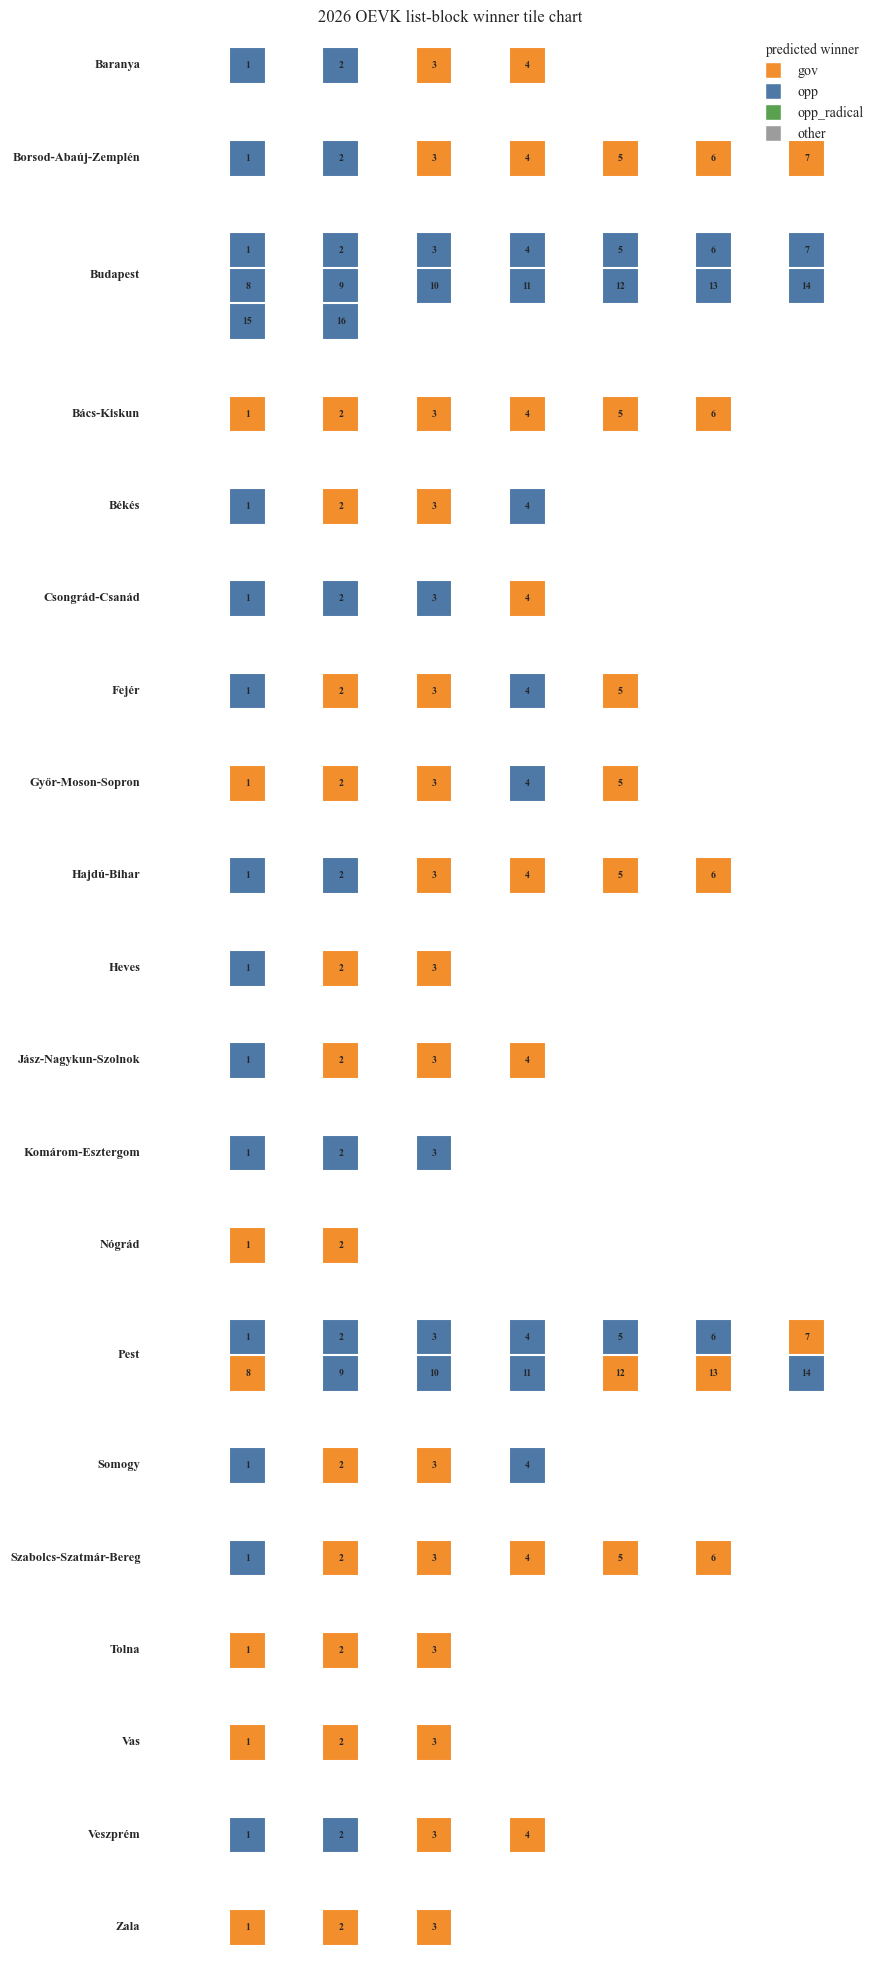

,item,value
0,candidate target,district candidate-gap in ALR space
1,training election,2022 parliamentary election
2,validation rule,grouped county holdout inside 2022 for leakage...
3,selection rule,"the lower holdout-MAE SMD layer goes forward, ..."
4,lag source used in training,2018 parliamentary candidate gap
5,future projection,2026 parliamentary candidate gap
6,safe modelling choice,shrink raw candidate-gap fit toward zero-gap l...
7,selected downstream SMD layer,separate candidate-gap model


,block,training_gap_sd,raw_fit_sd,resid_sd,shrinkage
0,gov,0.424,0.281,0.355,0.439
1,opp,0.438,0.273,0.381,0.389
2,opp_radical,1.182,0.503,1.146,0.181


,model,mae_gov,mae_opp,mae_opp_radical,mae_other,overall_mae,selected_for_downstream
0,separate candidate model (grouped county holdout),1.06,1.29,0.90,1.06,1.08,True
1,list proxy (grouped county holdout),1.32,1.45,0.74,1.39,1.23,False


,model,mae_gov,mae_opp,mae_opp_radical,mae_other,overall_mae
0,list proxy (fit only),1.32,1.45,0.74,1.39,1.23
1,separate candidate model (fit only),0.89,1.26,0.72,0.98,0.96


,winner,districts
0,gov,61
1,opp,45


,oevk_id,county,cand_gov
66,5_6,Borsod-Abaúj-Zemplén,63.92
7,8_3,Győr-Moson-Sopron,61.56
0,16_4,Szabolcs-Szatmár-Bereg,61.22
28,19_3,Veszprém,61.15
4,18_3,Vas,61.05
55,16_6,Szabolcs-Szatmár-Bereg,60.94
17,15_4,Somogy,60.02
56,16_5,Szabolcs-Szatmár-Bereg,56.45


,oevk_id,county,cand_opp
99,1_5,Budapest,56.56
96,1_6,Budapest,56.23
82,6_1,Csongrád-Csanád,55.59
100,1_12,Budapest,55.11
98,1_7,Budapest,54.37
102,1_3,Budapest,54.00
104,1_4,Budapest,53.84
105,1_11,Budapest,53.62


In [24]:
# this block produces the interpretation outputs.


list_forecast_weights = lean_2026["lag_nat_valid_list_total"].fillna(lean_2026["lag_nat_valid_cand_total"]).fillna(1.0).to_numpy(dtype="float64")
predicted_lean_matrix_2026 = lean_2026[[f"pred_lean_alr_{block}" for block in nonbase_blocks]].to_numpy(dtype="float64")
district_alr_mean = align_local_alr_to_national(
    predicted_lean_matrix_2026,
    combined_mean,
    list_forecast_weights,
    block_cols,
)

local_2026 = pd.concat(
    [
        lean_2026[["oevk_id", "county", "lag_nat_valid_list_total", "lag_nat_valid_cand_total"]].reset_index(drop=True),
        inverse_alr(district_alr_mean, block_cols).add_prefix("combined_"),
    ],
    axis=1,
)
local_2026["combined_winner"] = local_2026[[f"combined_{block}" for block in block_cols]].idxmax(axis=1).str.replace("combined_", "", regex=False)

winner_counts_2026 = local_2026["combined_winner"].value_counts().rename_axis("winner").reset_index(name="districts")
strongest_gov = local_2026.sort_values("combined_gov", ascending=False)[["oevk_id", "county", "combined_gov"]].head(8)
strongest_opp = local_2026.sort_values("combined_opp", ascending=False)[["oevk_id", "county", "combined_opp"]].head(8)

display(winner_counts_2026)
display(percent_table(strongest_gov, ["combined_gov"]).round(2))
display(percent_table(strongest_opp, ["combined_opp"]).round(2))

district_plot_lookup = (
    final_statistics_oevk[final_statistics_oevk["year"] == 2026][["oevk_id", "county", "oevk_code"]]
    .drop_duplicates()
)

district_plot = local_2026.merge(district_plot_lookup, on=["oevk_id", "county"], how="left")
district_plot["county"] = district_plot["county"].fillna("Unknown")
district_plot["oevk_code_num"] = pd.to_numeric(district_plot["oevk_code"], errors="coerce")
district_plot["oevk_code_label"] = district_plot["oevk_code_num"].map(
    lambda x: pd.NA if pd.isna(x) else (f"{int(x)}" if float(x).is_integer() else f"{x:g}")
)
district_plot["winner_color"] = district_plot["combined_winner"].map(block_colors).fillna("#cccccc")

county_order = sorted(district_plot["county"].unique().tolist())
tiles_per_row = 7
county_gap = 1.6
tile_rows = []
y_offset = 0.0

for county in county_order:
    sub = district_plot[district_plot["county"] == county].copy()
    sub = sub.sort_values(["oevk_code_num", "oevk_id"]).reset_index(drop=True)
    sub["tile_x"] = sub.index % tiles_per_row
    sub["tile_y"] = -(sub.index // tiles_per_row) - y_offset
    tile_rows.append(sub)
    y_offset += int(np.ceil(len(sub) / tiles_per_row)) + county_gap

district_tiles = pd.concat(tile_rows, ignore_index=True)

fig_height = max(8, 0.42 * y_offset + 2)
fig, ax = plt.subplots(figsize=(11, fig_height))
ax.scatter(
    district_tiles["tile_x"],
    district_tiles["tile_y"],
    s=700,
    c=district_tiles["winner_color"],
    marker="s",
    edgecolor="white",
    linewidth=1.5,
)

for _, row in district_tiles.iterrows():
    label = row["oevk_code_label"]
    if pd.isna(label) or label == "<NA>":
        label = str(row["oevk_id"])[-2:]
    ax.text(row["tile_x"], row["tile_y"], str(label), ha="center", va="center", fontsize=7, fontweight="bold")

county_centers = district_tiles.groupby("county", as_index=False).agg(tile_y=("tile_y", "mean"))
for _, row in county_centers.iterrows():
    ax.text(-1.15, row["tile_y"], row["county"], ha="right", va="center", fontsize=9, fontweight="bold")

legend_handles = [
    Line2D([0], [0], marker="s", linestyle="", markersize=11, markerfacecolor=block_colors[block], markeredgecolor="white", label=block)
    for block in block_cols
]

ax.legend(handles=legend_handles, title="predicted winner", loc="upper right", frameon=False)
ax.set_title("2026 OEVK list-block winner tile chart")
ax.set_xlim(-2.4, tiles_per_row - 0.25)
ax.set_ylim(district_tiles["tile_y"].min() - 1.0, 1.0)
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)
plt.show()

candidate_hist = result_wide[result_wide["election_type"] == "nat"].merge(stat_features, on=["year", "oevk_id"], how="left")
candidate_hist_list_alr = alr(
    candidate_hist[[f"list_share_{block}" for block in block_cols]].rename(columns={f"list_share_{block}": block for block in block_cols}),
    block_cols,
)
candidate_hist_list_alr.columns = [f"list_alr_{block}" for block in nonbase_blocks]
candidate_hist_cand_alr = alr(
    candidate_hist[[f"cand_share_{block}" for block in block_cols]].rename(columns={f"cand_share_{block}": block for block in block_cols}),
    block_cols,
)
candidate_hist_cand_alr.columns = [f"cand_alr_{block}" for block in nonbase_blocks]
candidate_hist = pd.concat(
    [candidate_hist.reset_index(drop=True), candidate_hist_list_alr.reset_index(drop=True), candidate_hist_cand_alr.reset_index(drop=True)],
    axis=1,
)
for block in nonbase_blocks:
    candidate_hist[f"cand_gap_alr_{block}"] = candidate_hist[f"cand_alr_{block}"] - candidate_hist[f"list_alr_{block}"]

candidate_gap_lookup = candidate_hist[["year", "oevk_id"] + [f"cand_gap_alr_{block}" for block in nonbase_blocks] + [f"cand_share_{block}" for block in block_cols]].copy()


def add_candidate_gap_lags(df):
    out = df.copy()
    for block in nonbase_blocks:
        out[f"lag_nat_cand_gap_alr_{block}"] = np.nan
    for block in block_cols:
        out[f"lag_nat_cand_share_{block}"] = np.nan

    for target_year, source_year in {2022: 2018, 2026: 2022}.items():
        rename_map = {f"cand_gap_alr_{block}": f"lag_nat_cand_gap_alr_{block}" for block in nonbase_blocks}
        rename_map.update({f"cand_share_{block}": f"lag_nat_cand_share_{block}" for block in block_cols})
        src = candidate_gap_lookup[candidate_gap_lookup["year"] == source_year].rename(columns=rename_map).drop(columns="year")
        mask = out["year"] == target_year
        if mask.sum() == 0:
            continue
        merged = out.loc[mask, ["oevk_id"]].merge(src, on="oevk_id", how="left")
        for block in nonbase_blocks:
            out.loc[mask, f"lag_nat_cand_gap_alr_{block}"] = merged[f"lag_nat_cand_gap_alr_{block}"].to_numpy()
        for block in block_cols:
            out.loc[mask, f"lag_nat_cand_share_{block}"] = merged[f"lag_nat_cand_share_{block}"].to_numpy()

    out["has_lag_nat_cand_gap"] = out[[f"lag_nat_cand_gap_alr_{block}" for block in nonbase_blocks]].notna().all(axis=1).astype(float)
    return out


candidate_train = add_candidate_gap_lags(candidate_hist[candidate_hist["year"].isin([2018, 2022])].copy())
candidate_transition_train = candidate_train[candidate_train["year"] == 2022].copy()
for block in block_cols:
    candidate_transition_train[f"current_list_share_{block}"] = candidate_transition_train[f"list_share_{block}"]
for block in nonbase_blocks:
    candidate_transition_train[f"current_list_alr_{block}"] = candidate_transition_train[f"list_alr_{block}"]

candidate_future = add_candidate_gap_lags(lean_2026.copy())
for block in block_cols:
    candidate_future[f"current_list_share_{block}"] = local_2026[f"combined_{block}"].to_numpy(dtype="float64")
for idx, block in enumerate(nonbase_blocks):
    candidate_future[f"current_list_alr_{block}"] = district_alr_mean[:, idx]

candidate_features = selected_structure_feature_set + [
    "has_lag_nat_cand_gap",
] + [f"current_list_alr_{block}" for block in nonbase_blocks] + [f"lag_nat_cand_gap_alr_{block}" for block in nonbase_blocks] + [f"lag_nat_cand_share_{block}" for block in block_cols]
candidate_cat_specs = [("stat_region", 1)]

candidate_model_info = pd.DataFrame(
    {
        "item": [
            "candidate target",
            "training election",
            "validation rule",
            "selection rule",
            "lag source used in training",
            "future projection",
            "safe modelling choice",
        ],
        "value": [
            "district candidate-gap in ALR space",
            "2022 parliamentary election",
            "grouped county holdout inside 2022 for leakage-safe validation",
            "the lower holdout-MAE SMD layer goes forward, with the simpler list proxy winning ties",
            "2018 parliamentary candidate gap",
            "2026 parliamentary candidate gap",
            "shrink raw candidate-gap fit toward zero-gap list proxy when signal is weak",
        ],
    }
)

candidate_models = {}
candidate_fit_rows = []

for block in nonbase_blocks:
    model = fit_random_intercept(candidate_transition_train, f"cand_gap_alr_{block}", candidate_features, candidate_cat_specs, "county")
    raw_fitted = predict_random_intercept(model, candidate_transition_train)
    target = candidate_transition_train[f"cand_gap_alr_{block}"].to_numpy(dtype="float64")
    fit_var = float(np.var(raw_fitted, ddof=1)) if len(raw_fitted) > 1 else 0.0
    resid_var = float(np.var(target - raw_fitted, ddof=1)) if len(target) > 1 else 0.0
    shrink = fit_var / (fit_var + resid_var) if (fit_var + resid_var) > 0 else 0.0
    candidate_transition_train[f"pred_cand_gap_alr_{block}"] = shrink * raw_fitted
    candidate_future[f"pred_cand_gap_alr_{block}"] = shrink * predict_random_intercept(model, candidate_future)
    candidate_models[block] = {"bundle": model, "shrink": shrink}
    candidate_fit_rows.append(
        {
            "block": block,
            "training_gap_sd": float(np.std(target, ddof=1)) if len(target) > 1 else 0.0,
            "raw_fit_sd": float(np.std(raw_fitted, ddof=1)) if len(raw_fitted) > 1 else 0.0,
            "resid_sd": float(np.std(target - candidate_transition_train[f"pred_cand_gap_alr_{block}"], ddof=1)) if len(target) > 1 else 0.0,
            "shrinkage": shrink,
        }
    )

candidate_fit_comp = inverse_alr(
    np.column_stack(
        [
            candidate_transition_train[f"current_list_alr_{block}"] + candidate_transition_train[f"pred_cand_gap_alr_{block}"]
            for block in nonbase_blocks
        ]
    ),
    block_cols,
)
for block in block_cols:
    candidate_transition_train[f"pred_cand_{block}"] = candidate_fit_comp[block].to_numpy(dtype="float64")

candidate_in_sample_summary = pd.DataFrame(
    [
        {
            "model": "list proxy (fit only)",
            **{f"mae_{block}": float(np.abs(candidate_transition_train[f"list_share_{block}"] - candidate_transition_train[f"cand_share_{block}"]).mean()) for block in block_cols},
        },
        {
            "model": "separate candidate model (fit only)",
            **{f"mae_{block}": float(np.abs(candidate_transition_train[f"pred_cand_{block}"] - candidate_transition_train[f"cand_share_{block}"]).mean()) for block in block_cols},
        },
    ]
)
candidate_in_sample_summary["overall_mae"] = candidate_in_sample_summary[[f"mae_{block}" for block in block_cols]].mean(axis=1)

candidate_cv_parts = []
candidate_cv_resid_rows = []
for fold_id, holdout_groups in enumerate(grouped_balanced_folds(candidate_transition_train, "county", n_folds=5), start=1):
    holdout_mask = candidate_transition_train["county"].astype("string").fillna("Unknown").astype(str).isin(holdout_groups)
    train = candidate_transition_train.loc[~holdout_mask].copy()
    test = candidate_transition_train.loc[holdout_mask].copy()
    if train.empty or test.empty:
        continue
    for block in nonbase_blocks:
        fold_model = fit_random_intercept(train, f"cand_gap_alr_{block}", candidate_features, candidate_cat_specs, "county")
        raw_fitted_train = predict_random_intercept(fold_model, train)
        target_train = train[f"cand_gap_alr_{block}"].to_numpy(dtype="float64")
        fit_var = float(np.var(raw_fitted_train, ddof=1)) if len(raw_fitted_train) > 1 else 0.0
        resid_var = float(np.var(target_train - raw_fitted_train, ddof=1)) if len(target_train) > 1 else 0.0
        shrink = fit_var / (fit_var + resid_var) if (fit_var + resid_var) > 0 else 0.0
        test[f"cv_pred_cand_gap_alr_{block}"] = shrink * predict_random_intercept(fold_model, test)
        candidate_cv_resid_rows.extend(
            [
                {
                    "fold": fold_id,
                    "oevk_id": oevk_id,
                    "block": block,
                    "resid": actual - fitted,
                }
                for oevk_id, actual, fitted in zip(
                    test["oevk_id"],
                    test[f"cand_gap_alr_{block}"],
                    test[f"cv_pred_cand_gap_alr_{block}"],
                )
            ]
        )
    candidate_cv_comp = inverse_alr(
        np.column_stack(
            [
                test[f"current_list_alr_{block}"].to_numpy(dtype="float64") + test[f"cv_pred_cand_gap_alr_{block}"].to_numpy(dtype="float64")
                for block in nonbase_blocks
            ]
        ),
        block_cols,
    )
    for block in block_cols:
        test[f"cv_pred_cand_{block}"] = candidate_cv_comp[block].to_numpy(dtype="float64")
    candidate_cv_parts.append(test.copy())

candidate_cv_predictions = pd.concat(candidate_cv_parts, ignore_index=True)
candidate_validation_summary = pd.DataFrame(
    [
        {
            "model_key": "list_proxy",
            "model": "list proxy (grouped county holdout)",
            **{f"mae_{block}": float(np.abs(candidate_cv_predictions[f"list_share_{block}"] - candidate_cv_predictions[f"cand_share_{block}"]).mean()) for block in block_cols},
        },
        {
            "model_key": "separate_candidate_model",
            "model": "separate candidate model (grouped county holdout)",
            **{f"mae_{block}": float(np.abs(candidate_cv_predictions[f"cv_pred_cand_{block}"] - candidate_cv_predictions[f"cand_share_{block}"]).mean()) for block in block_cols},
        },
    ]
)
candidate_validation_summary["overall_mae"] = candidate_validation_summary[[f"mae_{block}" for block in block_cols]].mean(axis=1)
candidate_validation_summary = candidate_validation_summary.sort_values(["overall_mae", "model_key"]).reset_index(drop=True)
selected_candidate_model_key = str(candidate_validation_summary.iloc[0]["model_key"])
candidate_validation_summary["selected_for_downstream"] = candidate_validation_summary["model_key"] == selected_candidate_model_key

candidate_resid_df = pd.DataFrame(candidate_cv_resid_rows)
candidate_gap_resid_matrix = (
    candidate_resid_df.pivot(index=["fold", "oevk_id"], columns="block", values="resid")
    .reindex(columns=nonbase_blocks)
    .fillna(0.0)
)
if candidate_gap_resid_matrix.shape[0] > 1:
    candidate_model_cov_raw = stabilize_cov(np.cov(candidate_gap_resid_matrix.to_numpy(dtype="float64"), rowvar=False))
    candidate_model_corr = shrink_corr_to_identity(
        candidate_model_cov_raw,
        n_obs=candidate_gap_resid_matrix.shape[0],
        prior_strength=25.0,
        clip=0.35,
    )
    candidate_model_sd = np.sqrt(np.maximum(np.diag(candidate_model_cov_raw), 0.08 ** 2))
    candidate_model_gap_cov = stabilize_cov(np.diag(candidate_model_sd) @ candidate_model_corr @ np.diag(candidate_model_sd))
else:
    candidate_model_gap_cov = np.eye(len(nonbase_blocks)) * 0.08 ** 2

candidate_proxy_gap_matrix = candidate_transition_train[[f"cand_gap_alr_{block}" for block in nonbase_blocks]].to_numpy(dtype="float64")
if candidate_proxy_gap_matrix.shape[0] > 1:
    candidate_proxy_cov_raw = stabilize_cov(np.cov(candidate_proxy_gap_matrix, rowvar=False))
    candidate_proxy_corr = shrink_corr_to_identity(
        candidate_proxy_cov_raw,
        n_obs=candidate_proxy_gap_matrix.shape[0],
        prior_strength=25.0,
        clip=0.35,
    )
    candidate_proxy_sd = np.sqrt(np.maximum(np.diag(candidate_proxy_cov_raw), 0.08 ** 2))
    candidate_proxy_gap_cov = stabilize_cov(np.diag(candidate_proxy_sd) @ candidate_proxy_corr @ np.diag(candidate_proxy_sd))
else:
    candidate_proxy_gap_cov = np.eye(len(nonbase_blocks)) * 0.08 ** 2

if selected_candidate_model_key == "separate_candidate_model":
    candidate_gap_cov = candidate_model_gap_cov
else:
    candidate_gap_cov = candidate_proxy_gap_cov

candidate_model_info.loc[len(candidate_model_info)] = {
    "item": "selected downstream SMD layer",
    "value": "separate candidate-gap model" if selected_candidate_model_key == "separate_candidate_model" else "list proxy as central mean, with candidate-gap uncertainty kept in simulation",
}

if selected_candidate_model_key == "separate_candidate_model":
    candidate_2026_gap_mean = candidate_future[[f"pred_cand_gap_alr_{block}" for block in nonbase_blocks]].to_numpy(dtype="float64")
else:
    candidate_2026_gap_mean = np.zeros((len(candidate_future), len(nonbase_blocks)), dtype="float64")
    for block in nonbase_blocks:
        candidate_future[f"pred_cand_gap_alr_{block}"] = 0.0

candidate_2026_alr_mean = district_alr_mean + candidate_2026_gap_mean
candidate_2026_comp = inverse_alr(candidate_2026_alr_mean, block_cols)
for block in nonbase_blocks:
    local_2026[f"pred_cand_gap_alr_{block}"] = candidate_future[f"pred_cand_gap_alr_{block}"].to_numpy(dtype="float64")
for block in block_cols:
    local_2026[f"cand_{block}"] = candidate_2026_comp[block].to_numpy(dtype="float64")
local_2026["candidate_winner"] = local_2026[[f"cand_{block}" for block in seat_blocks]].idxmax(axis=1).str.replace("cand_", "", regex=False)

candidate_winner_counts_2026 = local_2026["candidate_winner"].value_counts().rename_axis("winner").reset_index(name="districts")
candidate_strongest_gov = local_2026.sort_values("cand_gov", ascending=False)[["oevk_id", "county", "cand_gov"]].head(8)
candidate_strongest_opp = local_2026.sort_values("cand_opp", ascending=False)[["oevk_id", "county", "cand_opp"]].head(8)

display(candidate_model_info)
display(pd.DataFrame(candidate_fit_rows).round(3))
display(percent_table(candidate_validation_summary.drop(columns="model_key"), [f"mae_{block}" for block in block_cols] + ["overall_mae"]).round(2))
display(percent_table(candidate_in_sample_summary, [f"mae_{block}" for block in block_cols] + ["overall_mae"]).round(2))
display(candidate_winner_counts_2026)
display(percent_table(candidate_strongest_gov, ["cand_gov"]).round(2))
display(percent_table(candidate_strongest_opp, ["cand_opp"]).round(2))


Interpretation. Use the figure for the broad pattern. Small visual differences should not be overread.


### Push The National Result Down To Districts

**Why this is necessary:** The national forecast tells us the overall vote shares, but
parliamentary seats are won at the district level. We need to distribute the national
forecast across all 106 OEVKs, taking into account each district's local lean.

The method: take the combined national mean in log-ratio space, add each district's
predicted lean, then re-align so the district forecasts aggregate back to the national total.
After the list-block forecast, a separate candidate-gap model is fitted for the SMD side,
because candidate shares can differ from list shares in single-member districts.


saved district winner map to:
/Users/andrasikristof/Documents/Egyetem/2026:27 - 2. félév/Election_predictions/doc/ÚJLaTex_ENGLISH_Template másolat 2/figures/district_winner_map_2026.png
saved district winner map to:
/Users/andrasikristof/Documents/Egyetem/2026:27 - 2. félév/Election_predictions/graphs_tables/district_winner_map_2026.png


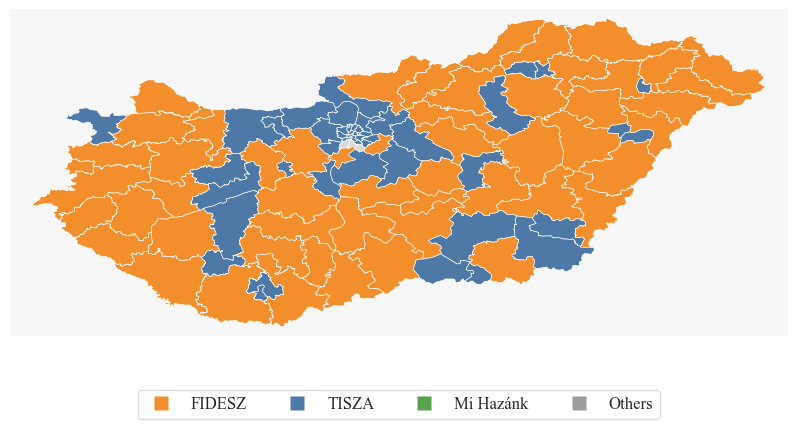

saved district winner map to:
/Users/andrasikristof/Documents/Egyetem/2026:27 - 2. félév/Election_predictions/doc/ÚJLaTex_ENGLISH_Template másolat 2/figures/district_winner_map_2026_house_RW.png
saved district winner map to:
/Users/andrasikristof/Documents/Egyetem/2026:27 - 2. félév/Election_predictions/graphs_tables/district_winner_map_2026_house_RW.png


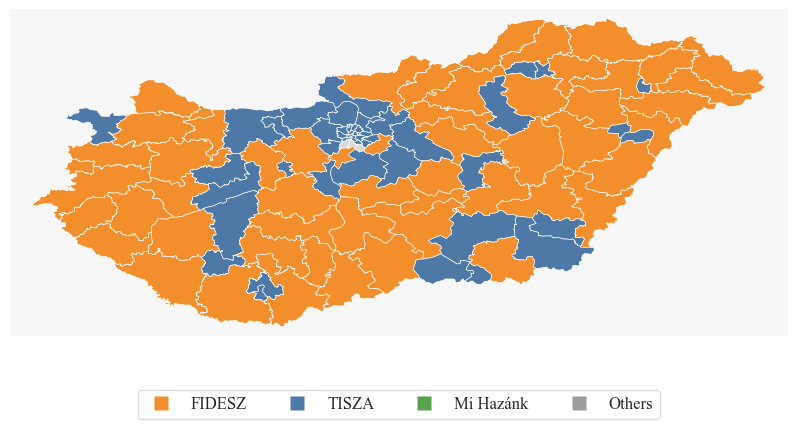

In [25]:
# this block pushes the national result down to districts.


from matplotlib.collections import PatchCollection
from matplotlib.patches import Polygon as MplPolygon

boundary_path = here.parent / "oevk_2014_boundaries.min.geo.json"  # GeoJSON is in parent scripts/ folder
map_font_family = "Times New Roman"
map_font_size = 12
map_output_dirs = [
    project_root / "doc" / "ÚJLaTex_ENGLISH_Template másolat 2" / "figures",
    project_root / "graphs_tables",
]
legend_label_map = {
    "gov": "FIDESZ",
    "opp": "TISZA",
    "opp_radical": "Mi Hazánk",
    "other": "Others",
}

simple_poll_forecast_map = poll_candidate_results["simple_weighted_average"]["forecast_share"].copy()
simple_poll_forecast_alr = {
    block: float(poll_candidate_results["simple_weighted_average"]["forecast_alr"][block])
    for block in nonbase_blocks
}
simple_combined_share_for_map = combine_share_maps(
    fixed_combination_model,
    simple_poll_forecast_map,
    prior_forecast,
    simple_poll_forecast_alr,
    {block: float(prior_forecast_alr[f"alr_{block}"]) for block in nonbase_blocks},
    {},
    {},
    combo_poll_alr_var,
    combo_prior_alr_var,
    poll_share_weight=FIXED_POLL_WEIGHT,
)
simple_combined_mean_for_map = alr(pd.DataFrame([simple_combined_share_for_map]), block_cols).iloc[0].to_numpy(dtype="float64")
simple_district_alr_mean_for_map = align_local_alr_to_national(
    predicted_lean_matrix_2026,
    simple_combined_mean_for_map,
    list_forecast_weights,
    block_cols,
)
simple_local_2026_for_map = pd.concat(
    [
        lean_2026[["oevk_id", "county"]].reset_index(drop=True),
        inverse_alr(simple_district_alr_mean_for_map, block_cols).add_prefix("combined_"),
    ],
    axis=1,
)
simple_local_2026_for_map["combined_winner"] = (
    simple_local_2026_for_map[[f"combined_{block}" for block in block_cols]]
    .idxmax(axis=1)
    .str.replace("combined_", "", regex=False)
)

if not boundary_path.exists():
    print(f"Missing boundary file, skipping map: {boundary_path}")
else:
    county_name_for_map = {
        "Csongrád-Csanád": "Csongrád",
    }

    def build_winner_by_map_name(local_frame):
        map_lookup = (
            final_statistics_oevk[final_statistics_oevk["year"] == 2026][["oevk_id", "county", "oevk_code"]]
            .drop_duplicates()
            .merge(local_frame[["oevk_id", "combined_winner"]], on="oevk_id", how="left")
        )
        map_lookup["map_county"] = map_lookup["county"].replace(county_name_for_map)
        map_lookup["oevk_code_num"] = pd.to_numeric(map_lookup["oevk_code"], errors="coerce")
        map_lookup["map_name"] = map_lookup.apply(
            lambda row: f"{row['map_county']} {int(row['oevk_code_num']):02d}"
            if pd.notna(row["oevk_code_num"]) else pd.NA,
            axis=1,
        )
        return (
            map_lookup
            .dropna(subset=["map_name"])
            .set_index("map_name")["combined_winner"]
            .to_dict()
        )

    main_winner_by_map_name = build_winner_by_map_name(local_2026)
    simple_winner_by_map_name = build_winner_by_map_name(simple_local_2026_for_map)

    with boundary_path.open(encoding="utf-8") as f:
        boundary_geojson = json.load(f)

    def outer_rings(geometry):
        geom_type = geometry.get("type")
        coords = geometry.get("coordinates", [])
        if geom_type == "Polygon":
            if coords:
                yield coords[0]
        elif geom_type == "MultiPolygon":
            for polygon in coords:
                if polygon:
                    yield polygon[0]

    feature_rings = []
    all_x = []
    all_y = []
    for feature in boundary_geojson["features"]:
        feature_name = feature.get("properties", {}).get("name")
        rings = []
        for ring in outer_rings(feature.get("geometry", {})):
            arr = np.asarray(ring, dtype="float64")
            if arr.ndim != 2 or arr.shape[0] < 3:
                continue
            rings.append(arr)
            all_x.extend(arr[:, 0].tolist())
            all_y.extend(arr[:, 1].tolist())
        if rings:
            feature_rings.append({"name": feature_name, "rings": rings})

    if not feature_rings:
        print("No valid OEVK polygons found in the boundary file.")
    else:
        x_min, x_max = min(all_x), max(all_x)
        y_min, y_max = min(all_y), max(all_y)
        x_pad = (x_max - x_min) * 0.03
        y_pad = (y_max - y_min) * 0.03

        panel_specs = [
            {
                "filename": "district_winner_map_2026.png",
                "winner_by_map_name": simple_winner_by_map_name,
                "panel_label": "",
            },
            {
                "filename": "district_winner_map_2026_house_RW.png",
                "winner_by_map_name": main_winner_by_map_name,
                "panel_label": "",
            },
        ]

        def draw_panel(ax, winner_by_map_name, panel_label):
            ax.set_facecolor("#f7f7f7")
            panel_patches = []
            panel_colors = []

            for feature_info in feature_rings:
                winner = winner_by_map_name.get(feature_info["name"])
                face_color = block_colors.get(winner, "#d9d9d9")
                for ring_arr in feature_info["rings"]:
                    panel_patches.append(MplPolygon(ring_arr, closed=True))
                    panel_colors.append(face_color)

            collection = PatchCollection(
                panel_patches,
                facecolor=panel_colors,
                edgecolor="#ffffff",
                linewidth=0.45,
                antialiased=True,
            )
            ax.add_collection(collection)
            ax.set_aspect("equal")
            ax.set_xlim(x_min - x_pad, x_max + x_pad)
            ax.set_ylim(y_min - y_pad, y_max + y_pad)
            ax.set_xticks([])
            ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_visible(False)

            ax.text(
                0.5,
                1.01,
                panel_label,
                transform=ax.transAxes,
                ha="center",
                va="bottom",
                fontsize=map_font_size+8,
                fontfamily=map_font_family,
                color="#333333",
            )

        legend_handles = [
            Line2D(
                [0], [0],
                marker="s",
                linestyle="",
                markersize=10,
                markerfacecolor=block_colors[block],
                markeredgecolor="none",
                label=legend_label_map[block],
            )
            for block in block_cols
        ]
        for panel_spec in panel_specs:
            fig, ax = plt.subplots(figsize=(8.1, 5.2))
            fig.patch.set_facecolor("white")
            draw_panel(ax, panel_spec["winner_by_map_name"], panel_spec["panel_label"])

            legend = fig.legend(
                handles=legend_handles,
                loc="lower center",
                ncol=4,
                frameon=True,
                fancybox=True,
                framealpha=0.95,
                edgecolor="#dddddd",
                facecolor="white",
                prop={"family": map_font_family, "size": map_font_size},
                bbox_to_anchor=(0.5, 0.045),
            )
            for text in legend.get_texts():
                text.set_fontfamily(map_font_family)

            fig.subplots_adjust(left=0.02, right=0.98, top=0.93, bottom=0.14)
            for output_dir in map_output_dirs:
                save_path = output_dir / panel_spec["filename"]
                save_path.parent.mkdir(parents=True, exist_ok=True)
                fig.savefig(save_path, dpi=300, bbox_inches="tight")
                print(f"saved district winner map to:\n{save_path}")
            plt.show()
            plt.close(fig)


Interpretation. Use the figure for the broad pattern. Small visual differences should not be overread.


### Seat Approximation Check

**Why this is necessary:** Before using our seat formula for 2026 predictions, we need
to verify it works on past elections where we know the actual seat counts. This check uses
the original historical parliamentary district files for `2018` and `2022`, so calculated
seats are compared like-for-like with official seats on the same geography.

**Parameter note:** This section uses the seat layer settings `list_seats=93` and the `0.05`
dHondt threshold inside `allocate_dhondt()`. It validates only the parliamentary years
`2018` and `2022`.


In [26]:
# this block runs the seat layer of the pipeline.


def load_original_nat_block_votes(year):
    if year == 2018:
        raw = pd.read_excel(
            data_dir / "Választási_eredmények" / "2018.04.08.végleges_eredmények" / "oevk_szerinti_eredmenyek_2018.xlsx",
            sheet_name="Adatok",
        ).rename(columns={
            "Megyekód": "county_code",
            "OEVK": "oevk_code",
            "NE": "valid_cand_total",
            "NL": "valid_list_total",
        })
        party_specs = [
            {
                "party_block": "gov",
                "cand_col": "FIDESZ - MAGYAR POLGÁRI SZÖVETSÉG, KERESZTÉNYDEMOKRATA NÉPPÁRT",
                "list_col": "FIDESZ-KDNP",
            },
            {
                "party_block": "opp_radical",
                "cand_col": "JOBBIK MAGYARORSZÁGÉRT MOZGALOM",
                "list_col": "JOBBIK",
            },
            {
                "party_block": "opp",
                "cand_col": "MAGYAR SZOCIALISTA PÁRT, PÁRBESZÉD MAGYARORSZÁGÉRT PÁRT",
                "list_col": "MSZP-PÁRBESZÉD",
            },
            {
                "party_block": "opp",
                "cand_col": "DEMOKRATIKUS KOALÍCIÓ",
                "list_col": "DK",
            },
            {
                "party_block": "opp",
                "cand_col": "LEHET MÁS A POLITIKA",
                "list_col": "LMP",
            },
            {
                "party_block": "opp",
                "cand_col": "EGYÜTT - A KORSZAKVÁLTÓK PÁRTJA",
                "list_col": "EGYÜTT",
            },
            {
                "party_block": "opp",
                "cand_col": "MOMENTUM MOZGALOM",
                "list_col": "MOMENTUM",
            },
            {
                "party_block": "other",
                "cand_col": "MAGYAR KÉTFARKÚ KUTYA PÁRT",
                "list_col": "MKKP",
            },
        ]
    elif year == 2022:
        raw = pd.read_excel(
            data_dir / "Választási_eredmények" / "2022.04.03._végleges_eredmények" / "2022.04.03._valasztasi_eredmenyek_Vox_Populi_adatbazis.xlsx",
            sheet_name="Választókerületi adatok",
        ).rename(columns={
            "maz": "county_code",
            "evk": "oevk_code",
            "E.n": "valid_cand_total",
            "L.n": "valid_list_total",
        })
        party_specs = [
            {"party_block": "gov", "cand_col": "E.FK", "list_col": "L.FK"},
            {"party_block": "opp", "cand_col": "E.EM", "list_col": "L.EM"},
            {"party_block": "opp_radical", "cand_col": "E.MH", "list_col": "L.MH"},
        ]
    else:
        raise ValueError(f"Unsupported parliamentary year: {year}")

    raw["oevk_id"] = raw["county_code"].astype(str) + "_" + raw["oevk_code"].astype(str)

    rows = []
    for cfg in party_specs:
        tmp = raw[["oevk_id"]].copy()
        tmp["party_block"] = cfg["party_block"]
        tmp["cand_votes"] = pd.to_numeric(raw.get(cfg["cand_col"], 0), errors="coerce").fillna(0.0)
        tmp["list_votes"] = pd.to_numeric(raw.get(cfg["list_col"], 0), errors="coerce").fillna(0.0)
        rows.append(tmp)

    long_df = pd.concat(rows, ignore_index=True)
    cand_main_sum = raw[[cfg["cand_col"] for cfg in party_specs]].apply(pd.to_numeric, errors="coerce").fillna(0.0).sum(axis=1)
    list_main_sum = raw[[cfg["list_col"] for cfg in party_specs]].apply(pd.to_numeric, errors="coerce").fillna(0.0).sum(axis=1)

    others = raw[["oevk_id"]].copy()
    others["party_block"] = "other"
    others["cand_votes"] = (pd.to_numeric(raw["valid_cand_total"], errors="coerce").fillna(0.0) - cand_main_sum).clip(lower=0.0)
    others["list_votes"] = (pd.to_numeric(raw["valid_list_total"], errors="coerce").fillna(0.0) - list_main_sum).clip(lower=0.0)
    long_df = pd.concat([long_df, others], ignore_index=True)

    actual_list_votes = long_df.groupby(["oevk_id", "party_block"], as_index=False)["list_votes"].sum().pivot(index="oevk_id", columns="party_block", values="list_votes").fillna(0.0)
    actual_cand_votes = long_df.groupby(["oevk_id", "party_block"], as_index=False)["cand_votes"].sum().pivot(index="oevk_id", columns="party_block", values="cand_votes").fillna(0.0)

    for block in block_cols:
        if block not in actual_list_votes.columns:
            actual_list_votes[block] = 0.0
            actual_cand_votes[block] = 0.0

    return {
        "list_votes": actual_list_votes[block_cols],
        "cand_votes": actual_cand_votes[block_cols],
    }


historical_nat_original = {
    year: load_original_nat_block_votes(year)
    for year in [2018, 2022]
}

legal_backtest_rows = []

for year in [2018, 2022]:
    actual_list_votes = historical_nat_original[year]["list_votes"].copy()
    actual_cand_votes = historical_nat_original[year]["cand_votes"].copy()
    calc = legal_parliament_seats(actual_list_votes, actual_cand_votes, list_seats=93)
    official = mandates_all_combined[
        (mandates_all_combined["year"] == year)
        & (mandates_all_combined["election_type"] == "nat")
    ].groupby("party_block")["total_seats"].sum().to_dict()

    legal_backtest_rows.append(
        {
            "year": year,
            **{f"calc_{block}": calc["total"][block] for block in block_cols},
            **{f"official_{block}": official.get(block, 0) for block in block_cols},
        }
    )

legal_backtest = pd.DataFrame(legal_backtest_rows)
seat_validation_blocks = seat_blocks.copy()
legal_backtest_report_cols = ["year"] + [
    col
    for block in seat_validation_blocks
    for col in [f"calc_{block}", f"official_{block}"]
]
display(legal_backtest[legal_backtest_report_cols])


,year,calc_gov,official_gov,calc_opp,official_opp,calc_opp_radical,official_opp_radical
0,2018,127,133,46,37,26,26
1,2022,134,135,58,57,7,6


**Interpretation:** The table compares calculated seats versus official seats for 2018 and 2022
on the original historical district maps, but only for `gov`, `opp`, and `opp_radical`.
If the numbers are close (within a few seats), the block-level legal approximation is working.
The remaining gap comes from the fact that we model at block level, not at full party-alliance
legal detail (which would require modelling dozens of individual parties and their exact alliances).
The aggregated `other` bucket is excluded from seat estimation, so it is omitted from the
seat-validation comparison.


### Seat Simulation

**Why this is necessary:** A single point forecast ("government gets 120 seats") hides
all the uncertainty. Monte Carlo simulation generates many possible outcomes (1500 draws),
each with slightly different national shares, district results, and seat counts.
This gives us a distribution of seats, not just one number.

Each draw: sample national vote shares from the joint covariance, push them down to districts
with lean + noise, compute candidate shares, determine district winners, and count seats.

The aggregated `other` bucket stays in the vote forecast, but it is excluded from seat
estimation so only the three modeled party blocs can win districts or receive list seats.

**Parameter note:** This section sets `n_draws=1500` and `rng_seed=20260314`.
It also reuses `list_seats=93`, `combined_cov`, `lean_cov`, and `candidate_gap_cov`.
The reported event thresholds are `100` seats for a majority and `133` seats for two thirds.


In [27]:
# this block runs the seat layer of the pipeline.


district_list_votes_2026 = local_2026[[f"combined_{block}" for block in block_cols]].rename(columns={f"combined_{block}": block for block in block_cols}).multiply(
    local_2026["lag_nat_valid_list_total"].fillna(local_2026["lag_nat_valid_cand_total"]).fillna(1.0),
    axis=0,
)

district_cand_votes_2026 = local_2026[[f"cand_{block}" for block in block_cols]].rename(columns={f"cand_{block}": block for block in block_cols}).multiply(
    local_2026["lag_nat_valid_cand_total"].fillna(local_2026["lag_nat_valid_list_total"]).fillna(1.0),
    axis=0,
)

seat_point = legal_parliament_seats(district_list_votes_2026, district_cand_votes_2026, list_seats=93)

n_draws = 1500
rng = np.random.default_rng(20260314)
nat_draws = rng.multivariate_normal(mean=combined_mean, cov=combined_cov, size=n_draws)
local_resid_draws = rng.multivariate_normal(mean=np.zeros(len(nonbase_blocks)), cov=lean_cov, size=(n_draws, len(lean_2026)))
candidate_gap_draws = rng.multivariate_normal(mean=np.zeros(len(nonbase_blocks)), cov=candidate_gap_cov, size=(n_draws, len(lean_2026)))
pred_candidate_gap_matrix = local_2026[[f"pred_cand_gap_alr_{block}" for block in nonbase_blocks]].to_numpy(dtype="float64")

seat_rows = []
for i in range(n_draws):
    local_alr = align_local_alr_to_national(
        predicted_lean_matrix_2026 + local_resid_draws[i],
        nat_draws[i],
        list_forecast_weights,
        block_cols,
    )
    local_comp = inverse_alr(local_alr, block_cols)
    candidate_alr = local_alr + pred_candidate_gap_matrix + candidate_gap_draws[i]
    candidate_comp = inverse_alr(candidate_alr, block_cols)

    list_votes = local_comp[block_cols].multiply(
        local_2026["lag_nat_valid_list_total"].fillna(local_2026["lag_nat_valid_cand_total"]).fillna(1.0),
        axis=0,
    )
    cand_votes = candidate_comp[block_cols].multiply(
        local_2026["lag_nat_valid_cand_total"].fillna(local_2026["lag_nat_valid_list_total"]).fillna(1.0),
        axis=0,
    )
    seat_out = legal_parliament_seats(list_votes, cand_votes, list_seats=93)
    nat_share = list_votes.sum(axis=0) / list_votes.to_numpy(dtype="float64").sum()

    seat_rows.append(
        {
            **{f"share_{block}": float(nat_share[block]) for block in block_cols},
            **{f"smd_{block}": int(seat_out["smd"][block]) for block in block_cols},
            **{f"list_{block}": int(seat_out["list"][block]) for block in block_cols},
            **{f"total_{block}": int(seat_out["total"][block]) for block in block_cols},
        }
    )

seat_draws = pd.DataFrame(seat_rows)

prob_summary = pd.DataFrame(
    {
        "event": [
            "gov finishes first",
            "opp finishes first",
            "gov majority",
            "gov two thirds",
            "opp majority",
            "opp two thirds",
            "parliament without gov majority",
            "parliament without opp majority",
            "opp plus opp_radical majority",
        ],
        "simulation_share": [
            float((seat_draws["share_gov"] > seat_draws[["share_opp", "share_opp_radical", "share_other"]].max(axis=1)).mean()),
            float((seat_draws["share_opp"] > seat_draws[["share_gov", "share_opp_radical", "share_other"]].max(axis=1)).mean()),
            float((seat_draws["total_gov"] >= 100).mean()),
            float((seat_draws["total_gov"] >= 133).mean()),
            float((seat_draws["total_opp"] >= 100).mean()),
            float((seat_draws["total_opp"] >= 133).mean()),
            float((seat_draws["total_gov"] < 100).mean()),
            float((seat_draws["total_opp"] < 100).mean()),
            float(((seat_draws["total_opp"] + seat_draws["total_opp_radical"]) >= 100).mean()),
        ],
    }
)
prob_summary["probability"] = prob_summary["simulation_share"]
simulation_note = pd.DataFrame(
    {
        "item": ["uncertainty reading"],
        "value": ["scenario shares are Monte Carlo draw frequencies under the model assumptions, not calibrated election probabilities"],
    }
)

seat_summary = pd.DataFrame(
    {
        "block": seat_blocks,
        "expected_share": [seat_draws[f"share_{block}"].mean() for block in seat_blocks],
        "expected_total_seats": [seat_draws[f"total_{block}"].mean() for block in seat_blocks],
        "p10_total_seats": [seat_draws[f"total_{block}"].quantile(0.10) for block in seat_blocks],
        "p90_total_seats": [seat_draws[f"total_{block}"].quantile(0.90) for block in seat_blocks],
    }
)

point_seat_table = pd.DataFrame(
    {
        "block": seat_blocks,
        "point_smd": [seat_point["smd"][block] for block in seat_blocks],
        "point_list": [seat_point["list"][block] for block in seat_blocks],
        "point_total": [seat_point["total"][block] for block in seat_blocks],
    }
)

display(point_seat_table)
display(simulation_note)
display(percent_table(prob_summary.loc[prob_summary["event"] != "opp plus opp_radical majority", ["event", "simulation_share"]], ["simulation_share"]).round(2))
display(percent_table(seat_summary, ["expected_share"]).round(2))

# the final seat simulation histogram comparing both poll paths is exported later,
# once both the simple and house-effects random-walk paths are available.


,block,point_smd,point_list,point_total
0,gov,61,41,102
1,opp,45,44,89
2,opp_radical,0,8,8


,item,value
0,uncertainty reading,scenario shares are Monte Carlo draw frequenci...


,event,simulation_share
0,gov finishes first,46.60
1,opp finishes first,53.40
2,gov majority,39.27
3,gov two thirds,1.07
4,opp majority,29.73
5,opp two thirds,1.40
6,parliament without gov majority,60.73
7,parliament without opp majority,70.27


,block,expected_share,expected_total_seats,p10_total_seats,p90_total_seats
0,gov,42.97,94.53,72.0,116.0
1,opp,44.02,90.64,68.0,113.0
2,opp_radical,7.29,13.83,7.0,23.0


**Interpretation:**
- The point seat table shows one central scenario.
- The probability table is the main result: it shows how often each event happens across
  all 1500 simulations. For example, "gov majority" at 60% means the government won a
  parliamentary majority in 60% of simulated outcomes.
- These are NOT calibrated election probabilities. They are scenario frequencies under
  the model assumptions. Real uncertainty could be larger or smaller.
- The histogram visualizes the seat distribution for government vs. opposition.


### Seat Approximation Layer Comparison

**Why this is necessary:** We have two ways to approximate seats: a rough shortcut
(district winner counts + national d'Hondt) and the block-level legal approximation
(with compensation votes). This section compares them on historical data, again using
the original historical district maps, to confirm which one is more accurate.

**Parameter note:** This section compares `rough_proxy_05` and `legal_approximation_06`.
The rough proxy uses `list_seats=93` and `threshold=0.05`.


In [28]:
# this block runs the seat layer of the pipeline.


seat_validation_blocks = seat_blocks.copy()

rough_seat_backtest_rows = []
for year in sorted(historical_nat_original):
    actual_list_votes = historical_nat_original[year]["list_votes"].copy()
    actual_list_shares = actual_list_votes.div(actual_list_votes.sum(axis=1).replace(0, np.nan), axis=0).fillna(0.0)
    rough_smd = (
        actual_list_shares[seat_blocks]
        .idxmax(axis=1)
        .value_counts()
        .reindex(seat_blocks, fill_value=0)
        .to_dict()
    )
    nat_share_map = (actual_list_votes.sum(axis=0) / actual_list_votes.sum(axis=0).sum()).reindex(seat_blocks, fill_value=0.0).to_dict()
    rough_list = allocate_dhondt(nat_share_map, 93, threshold=0.05)
    official = (
        mandates_all_combined[
            (mandates_all_combined["year"] == year)
            & (mandates_all_combined["election_type"] == "nat")
        ]
        .groupby("party_block")["total_seats"]
        .sum()
        .reindex(seat_blocks, fill_value=0)
        .to_dict()
    )
    rough_total = {block: int(rough_smd.get(block, 0)) + int(rough_list.get(block, 0)) for block in seat_blocks}
    rough_seat_backtest_rows.append(
        {
            "year": year,
            "model": "rough_proxy_05",
            "total_abs_error": float(sum(abs(rough_total[block] - official[block]) for block in seat_validation_blocks)),
        }
    )

legal_seat_backtest_rows = []
for row in legal_backtest.itertuples(index=False):
    legal_seat_backtest_rows.append(
        {
            "year": int(row.year),
            "model": "legal_approximation_06",
            "total_abs_error": float(
                abs(row.calc_gov - row.official_gov)
                + abs(row.calc_opp - row.official_opp)
                + abs(row.calc_opp_radical - row.official_opp_radical)
            ),
        }
    )

seat_layer_selection_summary = (
    pd.DataFrame(rough_seat_backtest_rows + legal_seat_backtest_rows)
    .groupby("model", as_index=False)
    .agg(mean_total_abs_error=("total_abs_error", "mean"))
    .sort_values("mean_total_abs_error")
    .reset_index(drop=True)
)

rough_point_list = allocate_dhondt({block: combined_forecast[block] for block in seat_blocks}, 93, threshold=0.05)
rough_point_smd = (
    local_2026[[f"combined_{block}" for block in seat_blocks]]
    .idxmax(axis=1)
    .str.replace("combined_", "", regex=False)
    .value_counts()
    .reindex(seat_blocks, fill_value=0)
    .to_dict()
)
rough_point_table = pd.DataFrame(
    {
        "block": seat_validation_blocks,
        "rough_smd": [int(rough_point_smd.get(block, 0)) for block in seat_validation_blocks],
        "rough_list": [int(rough_point_list.get(block, 0)) for block in seat_validation_blocks],
        "rough_total": [int(rough_smd.get(block, 0)) + int(rough_point_list.get(block, 0)) for block in seat_validation_blocks],
        "approx_total": [int(seat_point["total"][block]) for block in seat_validation_blocks],
    }
)

display(seat_layer_selection_summary.round(4))
display(rough_point_table)


,model,mean_total_abs_error
0,legal_approximation_06,9.0
1,rough_proxy_05,12.0


,block,rough_smd,rough_list,rough_total,approx_total
0,gov,56,43,129,102
1,opp,50,43,63,89
2,opp_radical,0,7,7,8


**Interpretation:** The first table compares the mean total absolute error of the two
seat layers on historical elections. Lower is better. The second table shows how much
the 2026 seat forecast changes when using the legal approximation versus the rough proxy.
Both tables report only `gov`, `opp`, and `opp_radical`, because the aggregated `other`
bucket is not treated as one legal list in the seat allocator.


### End-To-End Poll Path Comparison

**Why this is necessary:** This is the final sensitivity check. The main operational poll path in
this notebook is `simple_weighted_average`. We also run the entire pipeline with
`house_effects_rw` as a sensitivity check so the reader can see how much the richer poll layer
changes the live 2026 forecast.

If the two paths give very similar final seat distributions, the forecast is robust to the poll
layer choice. If they differ a lot, then that difference is itself one of the main substantive
findings.

**Parameter note:** This section keeps `simple_weighted_average` as the main poll path and
`house_effects_rw` as the sensitivity path. It also keeps the same `n_draws=1500` and
`rng_seed=20260314` for a fair comparison.


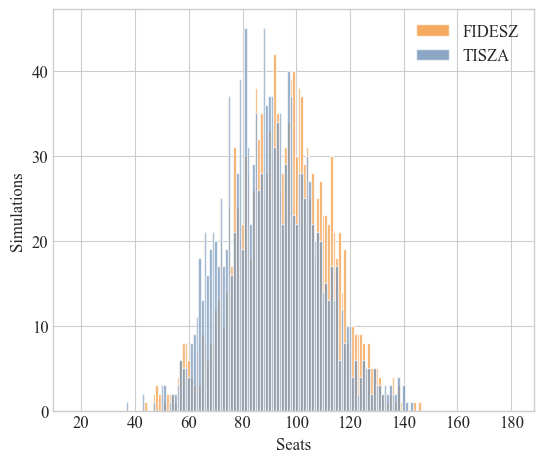

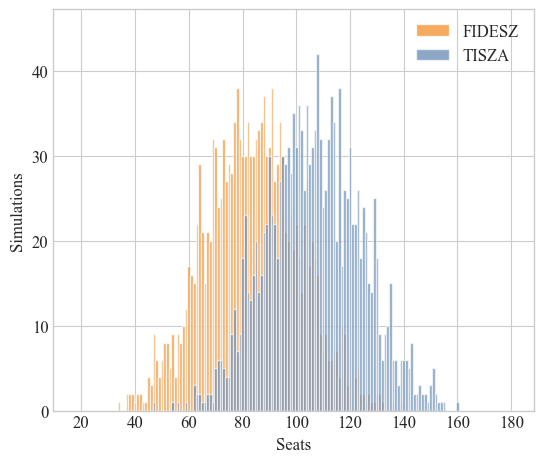

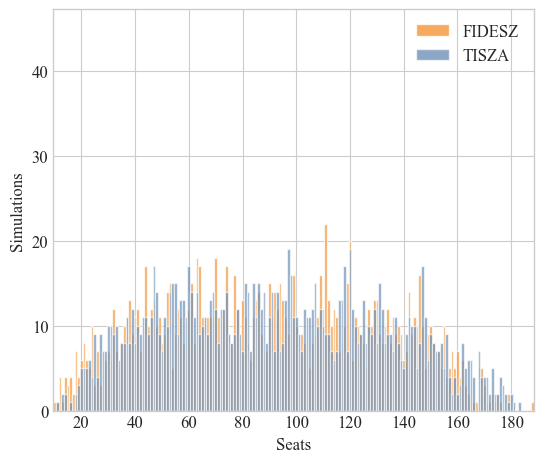

saved seat simulation histograms to:
/Users/andrasikristof/Documents/Egyetem/2026:27 - 2. félév/Election_predictions/graphs_tables/seat_simulation_histogram_7030_simple.png
/Users/andrasikristof/Documents/Egyetem/2026:27 - 2. félév/Election_predictions/doc/ÚjLaTex_ENGLISH_Template másolat 2/figures/seat_simulation_histogram_7030_simple.png
/Users/andrasikristof/Documents/Egyetem/2026:27 - 2. félév/Election_predictions/graphs_tables/seat_simulation_histogram_simple.png
/Users/andrasikristof/Documents/Egyetem/2026:27 - 2. félév/Election_predictions/doc/ÚjLaTex_ENGLISH_Template másolat 2/figures/seat_simulation_histogram_simple.png
/Users/andrasikristof/Documents/Egyetem/2026:27 - 2. félév/Election_predictions/graphs_tables/seat_simulation_histogram_houseRW.png
/Users/andrasikristof/Documents/Egyetem/2026:27 - 2. félév/Election_predictions/doc/ÚjLaTex_ENGLISH_Template másolat 2/figures/seat_simulation_histogram_houseRW.png


,path,poll_model,poll_gov,poll_opp,poll_opp_radical,poll_other,combined_gov,combined_opp,combined_opp_radical,combined_other,combined_backtest_mae
0,simple_weighted_average,simple_weighted_average,40.12,48.68,5.59,5.61,43.18,44.11,7.04,5.67,1.71
1,simple_weighted_average_poll_only,simple_weighted_average_poll_only,40.12,48.68,5.59,5.61,40.12,48.68,5.59,5.61,1.27
2,house_effects_rw,house_effects_rw,39.84,49.38,6.58,4.20,42.98,44.60,7.73,4.69,2.33


,path,gov,opp,opp_radical,other
0,simple_weighted_average,56,50,0,0
1,simple_weighted_average_poll_only,34,72,0,0
2,house_effects_rw,55,51,0,0


,path,gov,opp,opp_radical
0,simple_weighted_average,61,45,0
1,simple_weighted_average_poll_only,41,65,0
2,house_effects_rw,56,50,0


,path,poll_model,point_total_gov,point_total_opp,point_total_opp_radical,expected_total_gov,expected_total_opp,expected_total_opp_radical
0,simple_weighted_average,simple_weighted_average,102,89,8,94.53,90.64,13.83
1,simple_weighted_average_poll_only,simple_weighted_average_poll_only,83,110,6,83.52,106.39,9.09
2,house_effects_rw,house_effects_rw,97,93,9,90.65,92.19,16.15


...

,block,combined_share_delta_poll_only_minus_simple,combined_share_delta_house_minus_simple,expected_seat_delta_poll_only_minus_simple,expected_seat_delta_house_minus_simple
0,gov,-3.06,-0.20,-11.01,-3.87
1,opp,4.57,0.49,15.75,1.55
2,opp_radical,-1.45,0.69,-4.74,2.32


,metric,simple_weighted_average,simple_weighted_average_poll_only,house_effects_rw,poll_only_minus_simple,house_minus_simple
0,gov combined share,43.18,40.12,42.98,-3.06,-0.20
1,opp combined share,44.11,48.68,44.60,4.57,0.49
2,gov majority simulation share,39.27,18.73,42.40,-20.53,3.13
3,opp plus opp_radical majority simulation share,60.73,81.27,57.60,20.53,-3.13


,metric,simple_weighted_average,simple_weighted_average_poll_only,house_effects_rw,poll_only_minus_simple,house_minus_simple
0,gov list-side district winners,56.00,34.00,55.00,-22.00,-1.00
1,opp list-side district winners,50.00,72.00,51.00,22.00,1.00
2,gov candidate-side district winners,61.00,41.00,56.00,-20.00,-5.00
3,opp candidate-side district winners,45.00,65.00,50.00,20.00,5.00
4,gov expected total seats,94.53,83.52,90.65,-11.01,-3.87
5,opp expected total seats,90.64,106.39,92.19,15.75,1.55


,Block,Expected seats,P10 seats,P90 seats
0,gov,90.65,37.0,146.0
1,opp,92.19,38.0,148.0
2,opp_radical,16.15,5.0,31.0


,Election,Poll MAE (pp),Prior MAE (pp),Combined MAE (pp)
0,2018 parliamentary,2.34,7.11,2.77
1,2019 EP,1.70,6.20,1.10
2,2022 parliamentary,3.52,7.49,2.95
3,2024 EP,0.99,5.98,2.49
4,Mean,2.14,6.69,2.33


In [29]:
# this block defines helper functions that later cells reuse.


def error_cov_from_matrix(error_matrix, fallback_var):
    arr = np.asarray(error_matrix, dtype="float64")
    if arr.ndim == 1:
        arr = arr[:, None]
    if arr.size == 0 or arr.shape[0] < 2:
        dim = arr.shape[1] if arr.ndim == 2 and arr.shape[1] > 0 else len(nonbase_blocks)
        return np.eye(dim, dtype="float64") * fallback_var
    return stabilize_cov(np.cov(arr, rowvar=False))


def build_poll_path_result(path_name, poll_model_name, n_draws=1500, rng_seed=20260314, use_prior_blend=True):
    poll_bundle = poll_candidate_results[poll_model_name]
    poll_path_backtest = poll_bundle["backtest"].copy()
    poll_path_forecast = poll_bundle["forecast_share"].copy()
    poll_path_forecast_sd = {
        block: float(poll_bundle.get("forecast_alr_sd", {}).get(block, 0.0))
        for block in nonbase_blocks
    }

    poll_alr_var_local = {
        block: max(
            0.15 ** 2,
            float(np.nanmean(poll_path_backtest[f"alr_err_{block}"] ** 2)) + poll_path_forecast_sd[block] ** 2,
        )
        for block in nonbase_blocks
    }
    prior_alr_var_local = {
        block: max(
            0.35 ** 2,
            float(np.nanmean(prior_backtest[f"alr_err_{block}"] ** 2)),
        )
        for block in nonbase_blocks
    }

    poll_alr_cov_raw_local = error_cov_from_matrix(
        poll_path_backtest[[f"alr_err_{block}" for block in nonbase_blocks]].to_numpy(dtype="float64"),
        fallback_var=0.15 ** 2,
    )
    prior_alr_cov_raw_local = error_cov_from_matrix(
        prior_backtest[[f"alr_err_{block}" for block in nonbase_blocks]].to_numpy(dtype="float64"),
        fallback_var=0.35 ** 2,
    )

    poll_corr_local = shrink_corr_to_identity(
        poll_alr_cov_raw_local,
        n_obs=poll_path_backtest.shape[0],
        prior_strength=6.0,
        clip=0.45,
    )
    prior_corr_local = shrink_corr_to_identity(
        prior_alr_cov_raw_local,
        n_obs=prior_backtest.shape[0],
        prior_strength=6.0,
        clip=0.45,
    )
    if use_prior_blend:
        combined_corr_local = 0.5 * (poll_corr_local + prior_corr_local)
    else:
        combined_corr_local = poll_corr_local.copy()
    combined_corr_local = np.clip(combined_corr_local, -0.45, 0.45)
    np.fill_diagonal(combined_corr_local, 1.0)
    combined_corr_local = stabilize_cov(combined_corr_local, floor=1e-6)
    combined_corr_sd_local = np.sqrt(np.maximum(np.diag(combined_corr_local), 1e-8))
    combined_corr_local = combined_corr_local / np.outer(combined_corr_sd_local, combined_corr_sd_local)
    np.fill_diagonal(combined_corr_local, 1.0)

    if use_prior_blend:
        combined_var_vec_local = np.array(
            [
                1.0 / (1.0 / poll_alr_var_local[block] + 1.0 / prior_alr_var_local[block])
                for block in nonbase_blocks
            ],
            dtype="float64",
        )
    else:
        combined_var_vec_local = np.array(
            [poll_alr_var_local[block] for block in nonbase_blocks],
            dtype="float64",
        )
    combined_cov_local = stabilize_cov(
        np.diag(np.sqrt(combined_var_vec_local)) @ combined_corr_local @ np.diag(np.sqrt(combined_var_vec_local))
    )

    poll_share_var_local = {
        block: max(0.01 ** 2, float(np.nanmean(poll_path_backtest[f"abs_err_{block}"] ** 2)))
        for block in block_cols
    }
    prior_share_var_local = {
        block: max(0.02 ** 2, float(np.nanmean(prior_backtest[f"abs_err_{block}"] ** 2)))
        for block in block_cols
    }
    fixed_poll_share_weight_local = FIXED_POLL_WEIGHT if use_prior_blend else 1.0

    if use_prior_blend:
        combined_share_local = combine_share_maps(
            fixed_combination_model,
            poll_path_forecast,
            prior_forecast,
            poll_bundle["forecast_alr"],
            {block: float(prior_forecast_alr[f"alr_{block}"]) for block in nonbase_blocks},
            poll_share_var_local,
            prior_share_var_local,
            poll_alr_var_local,
            prior_alr_var_local,
            poll_share_weight=fixed_poll_share_weight_local,
        )
    else:
        combined_share_local = close_comp(
            pd.DataFrame([poll_path_forecast]),
            block_cols,
            eps=composition_floor,
        ).iloc[0].to_dict()
    combined_mean_local = alr(pd.DataFrame([combined_share_local]), block_cols).iloc[0].to_numpy(dtype="float64")

    combined_backtest_rows_local = []
    for election in sorted(poll_path_backtest["election"].unique()):
        if use_prior_blend and election not in prior_backtest["election"].values:
            continue
        poll_row = poll_path_backtest[poll_path_backtest["election"] == election].iloc[0]
        actual_row = actual_national_wide[actual_national_wide["election"] == election].iloc[0]
        if use_prior_blend:
            prior_row = prior_backtest[prior_backtest["election"] == election].iloc[0]
            holdout_poll_share_weight_local = FIXED_POLL_WEIGHT  # fixed from literature, not optimized
            row_share = combine_share_maps(
                fixed_combination_model,
                {block: float(poll_row[f"pred_{block}"]) for block in block_cols},
                {block: float(prior_row[f"pred_{block}"]) for block in block_cols},
                {block: float(poll_row[f"pred_alr_{block}"]) for block in nonbase_blocks},
                {block: float(prior_row[f"pred_alr_{block}"]) for block in nonbase_blocks},
                poll_share_var_local,
                prior_share_var_local,
                poll_alr_var_local,
                prior_alr_var_local,
                poll_share_weight=holdout_poll_share_weight_local,
            )
            out = {
                "election": election,
                "poll_mae": float(poll_row["mae"]),
                "prior_mae": float(prior_row["mae"]),
            }
        else:
            row_share = close_comp(
                pd.DataFrame(
                    [
                        {
                            block: float(poll_row[f"pred_{block}"])
                            for block in block_cols
                        }
                    ]
                ),
                block_cols,
                eps=composition_floor,
            ).iloc[0].to_dict()
            out = {
                "election": election,
                "poll_mae": float(poll_row["mae"]),
                "prior_mae": np.nan,
            }
        for block in block_cols:
            out[f"combined_{block}"] = row_share[block]
            out[f"abs_err_{block}"] = abs(row_share[block] - float(actual_row[block]))
        out["combined_mae"] = float(np.mean([out[f"abs_err_{block}"] for block in block_cols]))
        combined_backtest_rows_local.append(out)

    combined_backtest_local = pd.DataFrame(combined_backtest_rows_local)
    list_weights_local = lean_2026["lag_nat_valid_list_total"].fillna(lean_2026["lag_nat_valid_cand_total"]).fillna(1.0).to_numpy(dtype="float64")
    predicted_lean_matrix_local = lean_2026[[f"pred_lean_alr_{block}" for block in nonbase_blocks]].to_numpy(dtype="float64")
    district_alr_mean_local = align_local_alr_to_national(
        predicted_lean_matrix_local,
        combined_mean_local,
        list_weights_local,
        block_cols,
    )

    local_2026_local = pd.concat(
        [
            lean_2026[["oevk_id", "county", "lag_nat_valid_list_total", "lag_nat_valid_cand_total"]].reset_index(drop=True),
            inverse_alr(district_alr_mean_local, block_cols).add_prefix("combined_"),
        ],
        axis=1,
    )
    local_2026_local["combined_winner"] = (
        local_2026_local[[f"combined_{block}" for block in block_cols]]
        .idxmax(axis=1)
        .str.replace("combined_", "", regex=False)
    )

    candidate_future_local = add_candidate_gap_lags(lean_2026.copy())
    for block in block_cols:
        candidate_future_local[f"current_list_share_{block}"] = local_2026_local[f"combined_{block}"].to_numpy(dtype="float64")
    for idx, block in enumerate(nonbase_blocks):
        candidate_future_local[f"current_list_alr_{block}"] = district_alr_mean_local[:, idx]
    if selected_candidate_model_key == "separate_candidate_model":
        for idx, block in enumerate(nonbase_blocks):
            candidate_future_local[f"pred_cand_gap_alr_{block}"] = (
                candidate_models[block]["shrink"]
                * predict_random_intercept(candidate_models[block]["bundle"], candidate_future_local)
            )
            local_2026_local[f"pred_cand_gap_alr_{block}"] = candidate_future_local[f"pred_cand_gap_alr_{block}"].to_numpy(dtype="float64")
    else:
        for block in nonbase_blocks:
            candidate_future_local[f"pred_cand_gap_alr_{block}"] = 0.0
            local_2026_local[f"pred_cand_gap_alr_{block}"] = 0.0

    candidate_2026_alr_mean_local = (
        district_alr_mean_local
        + candidate_future_local[[f"pred_cand_gap_alr_{block}" for block in nonbase_blocks]].to_numpy(dtype="float64")
    )
    candidate_2026_comp_local = inverse_alr(candidate_2026_alr_mean_local, block_cols)
    for block in block_cols:
        local_2026_local[f"cand_{block}"] = candidate_2026_comp_local[block].to_numpy(dtype="float64")
    local_2026_local["candidate_winner"] = (
        local_2026_local[[f"cand_{block}" for block in seat_blocks]]
        .idxmax(axis=1)
        .str.replace("cand_", "", regex=False)
    )

    district_list_votes_local = local_2026_local[[f"combined_{block}" for block in block_cols]].rename(
        columns={f"combined_{block}": block for block in block_cols}
    ).multiply(
        local_2026_local["lag_nat_valid_list_total"].fillna(local_2026_local["lag_nat_valid_cand_total"]).fillna(1.0),
        axis=0,
    )
    district_cand_votes_local = local_2026_local[[f"cand_{block}" for block in block_cols]].rename(
        columns={f"cand_{block}": block for block in block_cols}
    ).multiply(
        local_2026_local["lag_nat_valid_cand_total"].fillna(local_2026_local["lag_nat_valid_list_total"]).fillna(1.0),
        axis=0,
    )

    seat_point_local = legal_parliament_seats(district_list_votes_local, district_cand_votes_local, list_seats=93)

    rng_local = np.random.default_rng(rng_seed)
    nat_draws_local = rng_local.multivariate_normal(mean=combined_mean_local, cov=combined_cov_local, size=n_draws)
    local_resid_draws_local = rng_local.multivariate_normal(
        mean=np.zeros(len(nonbase_blocks)),
        cov=lean_cov,
        size=(n_draws, len(lean_2026)),
    )
    candidate_gap_draws_local = rng_local.multivariate_normal(
        mean=np.zeros(len(nonbase_blocks)),
        cov=candidate_gap_cov,
        size=(n_draws, len(lean_2026)),
    )
    pred_candidate_gap_matrix_local = local_2026_local[
        [f"pred_cand_gap_alr_{block}" for block in nonbase_blocks]
    ].to_numpy(dtype="float64")

    seat_rows_local = []
    for draw_idx in range(n_draws):
        local_alr = align_local_alr_to_national(
            predicted_lean_matrix_local + local_resid_draws_local[draw_idx],
            nat_draws_local[draw_idx],
            list_weights_local,
            block_cols,
        )
        local_comp = inverse_alr(local_alr, block_cols)
        candidate_alr = local_alr + pred_candidate_gap_matrix_local + candidate_gap_draws_local[draw_idx]
        candidate_comp = inverse_alr(candidate_alr, block_cols)

        list_votes = local_comp[block_cols].multiply(
            local_2026_local["lag_nat_valid_list_total"].fillna(local_2026_local["lag_nat_valid_cand_total"]).fillna(1.0),
            axis=0,
        )
        cand_votes = candidate_comp[block_cols].multiply(
            local_2026_local["lag_nat_valid_cand_total"].fillna(local_2026_local["lag_nat_valid_list_total"]).fillna(1.0),
            axis=0,
        )
        seat_out = legal_parliament_seats(list_votes, cand_votes, list_seats=93)
        nat_share = list_votes.sum(axis=0) / list_votes.to_numpy(dtype="float64").sum()

        seat_rows_local.append(
            {
                **{f"share_{block}": float(nat_share[block]) for block in block_cols},
                **{f"smd_{block}": int(seat_out["smd"][block]) for block in block_cols},
                **{f"list_{block}": int(seat_out["list"][block]) for block in block_cols},
                **{f"total_{block}": int(seat_out["total"][block]) for block in block_cols},
            }
        )

    seat_draws_local = pd.DataFrame(seat_rows_local)
    prob_summary_local = pd.DataFrame(
        {
            "event": [
                "gov finishes first",
                "opp finishes first",
                "gov majority",
                "gov two thirds",
                "opp majority",
                "opp two thirds",
                "parliament without gov majority",
                "parliament without opp majority",
                "opp plus opp_radical majority",
            ],
            "simulation_share": [
                float((seat_draws_local["share_gov"] > seat_draws_local[["share_opp", "share_opp_radical", "share_other"]].max(axis=1)).mean()),
                float((seat_draws_local["share_opp"] > seat_draws_local[["share_gov", "share_opp_radical", "share_other"]].max(axis=1)).mean()),
                float((seat_draws_local["total_gov"] >= 100).mean()),
                float((seat_draws_local["total_gov"] >= 133).mean()),
                float((seat_draws_local["total_opp"] >= 100).mean()),
                float((seat_draws_local["total_opp"] >= 133).mean()),
                float((seat_draws_local["total_gov"] < 100).mean()),
                float((seat_draws_local["total_opp"] < 100).mean()),
                float(((seat_draws_local["total_opp"] + seat_draws_local["total_opp_radical"]) >= 100).mean()),
            ],
        }
    )
    prob_summary_local["probability"] = prob_summary_local["simulation_share"]
    seat_summary_local = pd.DataFrame(
        {
            "block": seat_blocks,
            "expected_share": [seat_draws_local[f"share_{block}"].mean() for block in seat_blocks],
            "expected_total_seats": [seat_draws_local[f"total_{block}"].mean() for block in seat_blocks],
            "p10_total_seats": [seat_draws_local[f"total_{block}"].quantile(0.10) for block in seat_blocks],
            "p90_total_seats": [seat_draws_local[f"total_{block}"].quantile(0.90) for block in seat_blocks],
        }
    )
    point_seat_table_local = pd.DataFrame(
        {
            "block": seat_blocks,
            "point_smd": [seat_point_local["smd"][block] for block in seat_blocks],
            "point_list": [seat_point_local["list"][block] for block in seat_blocks],
            "point_total": [seat_point_local["total"][block] for block in seat_blocks],
        }
    )

    rough_point_list_local = allocate_dhondt({block: combined_share_local[block] for block in seat_blocks}, 93, threshold=0.05)
    rough_point_smd_local = (
        local_2026_local[[f"combined_{block}" for block in seat_blocks]]
        .idxmax(axis=1)
        .str.replace("combined_", "", regex=False)
        .value_counts()
        .reindex(seat_blocks, fill_value=0)
        .to_dict()
    )
    rough_point_table_local = pd.DataFrame(
        {
            "block": seat_blocks,
            "rough_smd": [int(rough_point_smd_local.get(block, 0)) for block in seat_blocks],
            "rough_list": [int(rough_point_list_local.get(block, 0)) for block in seat_blocks],
            "rough_total": [int(rough_point_smd_local.get(block, 0)) + int(rough_point_list_local.get(block, 0)) for block in seat_blocks],
            "approx_total": [int(seat_point_local["total"][block]) for block in seat_blocks],
        }
    )

    return {
        "path": path_name,
        "poll_model": poll_model_name,
        "fixed_poll_share_weight": fixed_poll_share_weight_local,
        "poll_forecast": poll_path_forecast,
        "combined_forecast": combined_share_local,
        "combined_backtest": combined_backtest_local,
        "combined_cov": combined_cov_local,
        "local_2026": local_2026_local,
        "district_winner_counts": local_2026_local["combined_winner"].value_counts().rename_axis("winner").reset_index(name="districts"),
        "candidate_winner_counts": local_2026_local["candidate_winner"].value_counts().rename_axis("winner").reset_index(name="districts"),
        "point_seat_table": point_seat_table_local,
        "seat_draws": seat_draws_local.copy(),
        "seat_summary": seat_summary_local,
        "prob_summary": prob_summary_local,
        "rough_point_table": rough_point_table_local,
    }


house_rw_poll_path_result = build_poll_path_result(
    "house_effects_rw",
    "mixed_plus_random_walk_06",
    n_draws=n_draws,
    rng_seed=20260314,
)
house_rw_poll_path_result["poll_model"] = "house_effects_rw"

simple_poll_path_result = build_poll_path_result(
    "simple_weighted_average",
    "simple_weighted_average",
    n_draws=n_draws,
    rng_seed=20260314,
)

simple_poll_only_path_result = build_poll_path_result(
    "simple_weighted_average_poll_only",
    "simple_weighted_average",
    n_draws=n_draws,
    rng_seed=20260314,
    use_prior_blend=False,
)
simple_poll_only_path_result["poll_model"] = "simple_weighted_average_poll_only"

poll_path_results = {
    "simple_weighted_average": simple_poll_path_result,
    "simple_weighted_average_poll_only": simple_poll_only_path_result,
    "house_effects_rw": house_rw_poll_path_result,
}

seat_hist_output_dirs = [
    project_root / "graphs_tables",
    project_root / "doc" / "ÚJLaTex_ENGLISH_Template másolat 2" / "figures",
]
for output_dir in seat_hist_output_dirs:
    output_dir.mkdir(parents=True, exist_ok=True)

hist_path_specs = [
    {
        "filename": "seat_simulation_histogram_7030_simple.png",
        "seat_draws": simple_poll_path_result["seat_draws"],
    },
    {
        "filename": "seat_simulation_histogram_simple.png",
        "seat_draws": simple_poll_only_path_result["seat_draws"],
    },
    {
        "filename": "seat_simulation_histogram_houseRW.png",
        "seat_draws": house_rw_poll_path_result["seat_draws"],
    },
]
all_hist_values = np.concatenate(
    [
        seat_draws_panel[["total_gov", "total_opp"]].to_numpy(dtype="float64").ravel()
        for seat_draws_panel in [hist_spec["seat_draws"] for hist_spec in hist_path_specs]
    ]
)
hist_min = int(np.floor(all_hist_values.min()))
hist_max = int(np.ceil(all_hist_values.max()))
hist_bins = np.arange(hist_min - 0.5, hist_max + 1.5, 1.0)
hist_count_max = max(
    max(
        np.histogram(hist_spec["seat_draws"]["total_gov"], bins=hist_bins)[0].max(),
        np.histogram(hist_spec["seat_draws"]["total_opp"], bins=hist_bins)[0].max(),
    )
    for hist_spec in hist_path_specs
)

with plt.rc_context({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size": 12,
}):
    saved_hist_paths = []
    for hist_spec in hist_path_specs:
        seat_draws_panel = hist_spec["seat_draws"]
        fig, ax = plt.subplots(figsize=(5.6, 4.8))
        ax.hist(
            seat_draws_panel["total_gov"],
            bins=hist_bins,
            alpha=0.75,
            label="FIDESZ",
            color=block_colors["gov"],
            edgecolor="white",
        )
        ax.hist(
            seat_draws_panel["total_opp"],
            bins=hist_bins,
            alpha=0.65,
            label="TISZA",
            color=block_colors["opp"],
            edgecolor="white",
        )
        ax.set_xlabel("Seats")
        ax.set_ylabel("Simulations")
        ax.set_xlim(hist_bins[0], hist_bins[-1])
        ax.set_ylim(0, hist_count_max * 1.05)
        ax.legend(frameon=False)
        plt.tight_layout()
        for output_dir in seat_hist_output_dirs:
            save_path = output_dir / hist_spec["filename"]
            fig.savefig(save_path, dpi=150, bbox_inches="tight")
            saved_hist_paths.append(save_path)
        plt.show()
        plt.close(fig)

print("saved seat simulation histograms to:")
for saved_path in saved_hist_paths:
    print(saved_path)

poll_path_national_compare = pd.DataFrame(
    [
        {
            "path": path_key,
            "poll_model": result["poll_model"],
            **{f"poll_{block}": float(result["poll_forecast"][block]) for block in block_cols},
            **{f"combined_{block}": float(result["combined_forecast"][block]) for block in block_cols},
            "combined_backtest_mae": float(result["combined_backtest"]["combined_mae"].mean()),
        }
        for path_key, result in poll_path_results.items()
    ]
)

poll_path_district_compare = pd.DataFrame(
    [
        {
            "path": path_key,
            **{
                block: int(result["district_winner_counts"].set_index("winner")["districts"].to_dict().get(block, 0))
                for block in block_cols
            },
        }
        for path_key, result in poll_path_results.items()
    ]
)

poll_path_candidate_compare = pd.DataFrame(
    [
        {
            "path": path_key,
            **{
                block: int(result["candidate_winner_counts"].set_index("winner")["districts"].to_dict().get(block, 0))
                for block in seat_blocks
            },
        }
        for path_key, result in poll_path_results.items()
    ]
)

poll_path_seat_compare = pd.DataFrame(
    [
        {
            "path": path_key,
            "poll_model": result["poll_model"],
            **{
                f"point_total_{block}": int(result["point_seat_table"].set_index("block")["point_total"].to_dict().get(block, 0))
                for block in seat_blocks
            },
            **{
                f"expected_total_{block}": float(result["seat_summary"].set_index("block")["expected_total_seats"].to_dict().get(block, 0.0))
                for block in seat_blocks
            },
        }
        for path_key, result in poll_path_results.items()
    ]
)

poll_path_prob_compare = pd.DataFrame(
    [
        {
            "path": path_key,
            **result["prob_summary"].set_index("event")["simulation_share"].to_dict(),
        }
        for path_key, result in poll_path_results.items()
    ]
)

simple_combined = simple_poll_path_result["combined_forecast"]
simple_poll_only_combined = simple_poll_only_path_result["combined_forecast"]
house_combined = house_rw_poll_path_result["combined_forecast"]
simple_expected = simple_poll_path_result["seat_summary"].set_index("block")["expected_total_seats"].to_dict()
simple_poll_only_expected = simple_poll_only_path_result["seat_summary"].set_index("block")["expected_total_seats"].to_dict()
house_expected = house_rw_poll_path_result["seat_summary"].set_index("block")["expected_total_seats"].to_dict()
poll_path_delta = pd.DataFrame(
    {
        "block": seat_blocks,
        "combined_share_delta_poll_only_minus_simple": [
            float(simple_poll_only_combined[block] - simple_combined[block])
            for block in seat_blocks
        ],
        "combined_share_delta_house_minus_simple": [
            float(house_combined[block] - simple_combined[block])
            for block in seat_blocks
        ],
        "expected_seat_delta_poll_only_minus_simple": [
            float(simple_poll_only_expected[block] - simple_expected[block])
            for block in seat_blocks
        ],
        "expected_seat_delta_house_minus_simple": [
            float(house_expected[block] - simple_expected[block])
            for block in seat_blocks
        ],
    }
)
simple_list_winners = simple_poll_path_result["district_winner_counts"].set_index("winner")["districts"].to_dict()
simple_poll_only_list_winners = simple_poll_only_path_result["district_winner_counts"].set_index("winner")["districts"].to_dict()
house_list_winners = house_rw_poll_path_result["district_winner_counts"].set_index("winner")["districts"].to_dict()
simple_candidate_winners = simple_poll_path_result["candidate_winner_counts"].set_index("winner")["districts"].to_dict()
simple_poll_only_candidate_winners = simple_poll_only_path_result["candidate_winner_counts"].set_index("winner")["districts"].to_dict()
house_candidate_winners = house_rw_poll_path_result["candidate_winner_counts"].set_index("winner")["districts"].to_dict()
simple_prob_map = simple_poll_path_result["prob_summary"].set_index("event")["simulation_share"].to_dict()
simple_poll_only_prob_map = simple_poll_only_path_result["prob_summary"].set_index("event")["simulation_share"].to_dict()
house_prob_map = house_rw_poll_path_result["prob_summary"].set_index("event")["simulation_share"].to_dict()

poll_path_sensitivity_share_prob = pd.DataFrame(
    {
        "metric": [
            "gov combined share",
            "opp combined share",
            "gov majority simulation share",
            "opp plus opp_radical majority simulation share",
        ],
        "simple_weighted_average": [
            simple_combined["gov"],
            simple_combined["opp"],
            float(simple_prob_map.get("gov majority", np.nan)),
            float(simple_prob_map.get("opp plus opp_radical majority", np.nan)),
        ],
        "simple_weighted_average_poll_only": [
            simple_poll_only_combined["gov"],
            simple_poll_only_combined["opp"],
            float(simple_poll_only_prob_map.get("gov majority", np.nan)),
            float(simple_poll_only_prob_map.get("opp plus opp_radical majority", np.nan)),
        ],
        "house_effects_rw": [
            house_combined["gov"],
            house_combined["opp"],
            float(house_prob_map.get("gov majority", np.nan)),
            float(house_prob_map.get("opp plus opp_radical majority", np.nan)),
        ],
    }
)
poll_path_sensitivity_share_prob["poll_only_minus_simple"] = (
    poll_path_sensitivity_share_prob["simple_weighted_average_poll_only"] - poll_path_sensitivity_share_prob["simple_weighted_average"]
)
poll_path_sensitivity_share_prob["house_minus_simple"] = (
    poll_path_sensitivity_share_prob["house_effects_rw"] - poll_path_sensitivity_share_prob["simple_weighted_average"]
)

poll_path_sensitivity_district_seat = pd.DataFrame(
    {
        "metric": [
            "gov list-side district winners",
            "opp list-side district winners",
            "gov candidate-side district winners",
            "opp candidate-side district winners",
            "gov expected total seats",
            "opp expected total seats",
        ],
        "simple_weighted_average": [
            int(simple_list_winners.get("gov", 0)),
            int(simple_list_winners.get("opp", 0)),
            int(simple_candidate_winners.get("gov", 0)),
            int(simple_candidate_winners.get("opp", 0)),
            float(simple_expected.get("gov", np.nan)),
            float(simple_expected.get("opp", np.nan)),
        ],
        "simple_weighted_average_poll_only": [
            int(simple_poll_only_list_winners.get("gov", 0)),
            int(simple_poll_only_list_winners.get("opp", 0)),
            int(simple_poll_only_candidate_winners.get("gov", 0)),
            int(simple_poll_only_candidate_winners.get("opp", 0)),
            float(simple_poll_only_expected.get("gov", np.nan)),
            float(simple_poll_only_expected.get("opp", np.nan)),
        ],
        "house_effects_rw": [
            int(house_list_winners.get("gov", 0)),
            int(house_list_winners.get("opp", 0)),
            int(house_candidate_winners.get("gov", 0)),
            int(house_candidate_winners.get("opp", 0)),
            float(house_expected.get("gov", np.nan)),
            float(house_expected.get("opp", np.nan)),
        ],
    }
)
poll_path_sensitivity_district_seat["poll_only_minus_simple"] = (
    poll_path_sensitivity_district_seat["simple_weighted_average_poll_only"] - poll_path_sensitivity_district_seat["simple_weighted_average"]
)
poll_path_sensitivity_district_seat["house_minus_simple"] = (
    poll_path_sensitivity_district_seat["house_effects_rw"] - poll_path_sensitivity_district_seat["simple_weighted_average"]
)

house_combination_backtest_table = house_rw_poll_path_result["combined_backtest"][["election", "poll_mae", "prior_mae", "combined_mae"]].copy()
house_combination_backtest_table["Election"] = house_combination_backtest_table["election"].map(
    {
        "2018_nat": "2018 parliamentary",
        "2019_ep": "2019 EP",
        "2022_nat": "2022 parliamentary",
        "2024_ep": "2024 EP",
    }
)
house_combination_backtest_table = house_combination_backtest_table[["Election", "poll_mae", "prior_mae", "combined_mae"]].rename(
    columns={
        "poll_mae": "Poll MAE (pp)",
        "prior_mae": "Prior MAE (pp)",
        "combined_mae": "Combined MAE (pp)",
    }
)
house_combination_backtest_table = pd.concat(
    [
        house_combination_backtest_table,
        pd.DataFrame(
            [
                {
                    "Election": "Mean",
                    "Poll MAE (pp)": house_combination_backtest_table["Poll MAE (pp)"].mean(),
                    "Prior MAE (pp)": house_combination_backtest_table["Prior MAE (pp)"].mean(),
                    "Combined MAE (pp)": house_combination_backtest_table["Combined MAE (pp)"].mean(),
                }
            ]
        ),
    ],
    ignore_index=True,
)

house_simulation_seat_table = house_rw_poll_path_result["seat_summary"][["block", "expected_total_seats", "p10_total_seats", "p90_total_seats"]].rename(
    columns={
        "block": "Block",
        "expected_total_seats": "Expected seats",
        "p10_total_seats": "P10 seats",
        "p90_total_seats": "P90 seats",
    }
)

display(
    percent_table(
        poll_path_national_compare,
        [f"poll_{block}" for block in block_cols] + [f"combined_{block}" for block in block_cols] + ["combined_backtest_mae"],
    ).round(2)
)
display(poll_path_district_compare)
display(poll_path_candidate_compare)
display(poll_path_seat_compare.round(2))
display(
    percent_table(
        poll_path_prob_compare,
        [
            "gov finishes first",
            "opp finishes first",
            "gov majority",
            "gov two thirds",
            "opp majority",
            "opp two thirds",
            "parliament without gov majority",
            "parliament without opp majority",
            "opp plus opp_radical majority",
        ],
    ).round(2)
)
display(
    percent_table(
        poll_path_delta,
        ["combined_share_delta_poll_only_minus_simple", "combined_share_delta_house_minus_simple"],
    ).round(2)
)
display(
    percent_table(
        poll_path_sensitivity_share_prob,
        ["simple_weighted_average", "simple_weighted_average_poll_only", "house_effects_rw", "poll_only_minus_simple", "house_minus_simple"],
    ).round(2)
)
display(poll_path_sensitivity_district_seat.round(2))
display(house_simulation_seat_table.round(2))
display(percent_table(house_combination_backtest_table, ["Poll MAE (pp)", "Prior MAE (pp)", "Combined MAE (pp)"]).round(2))


**Interpretation:**
- The tables compare the `simple_weighted_average` main path against two sensitivities:
  `simple_weighted_average_poll_only` and `house_effects_rw`.
- The poll-only sensitivity isolates one question: how much the fixed 70/30 poll-plus-prior blend
  changes the final answer relative to the raw simple poll path.
- The house-effects RW sensitivity isolates a different question: how much the answer changes if we
  replace the simple poll layer with the richer pollster-corrected random-walk layer.
- Look at the delta columns: if the seat differences are small, the final answer is robust.
  If the differences are large, the 2026 forecast is sensitive to the national path choice.


### Final Easy English Summary

**Why this is necessary:** After all the technical modelling, we need a plain-language summary
that states the key findings clearly. This cell prints the main numbers for the
`simple_weighted_average` 70/30 main path and then shows two sensitivity paths
(`simple_weighted_average_poll_only` and `house_effects_rw`) so the reader can see the bottom line
without digging through all the tables.


In [30]:
# this block works on the final easy English summary.
simple_result = poll_path_results["simple_weighted_average"]
simple_poll_only_result = poll_path_results["simple_weighted_average_poll_only"]
house_result = poll_path_results["house_effects_rw"]


def result_prob(result, event):
    return float(result["prob_summary"].set_index("event")["simulation_share"].to_dict().get(event, np.nan))


def result_expected_seats(result, block):
    return float(result["seat_summary"].set_index("block")["expected_total_seats"].to_dict().get(block, 0.0))


def result_point_seats(result, block):
    return int(result["point_seat_table"].set_index("block")["point_total"].to_dict().get(block, 0))


simple_gov_first_prob = result_prob(simple_result, "gov finishes first")
simple_opp_first_prob = result_prob(simple_result, "opp finishes first")
simple_gov_majority_prob = result_prob(simple_result, "gov majority")
simple_gov_twothirds_prob = result_prob(simple_result, "gov two thirds")
simple_opp_majority_prob = result_prob(simple_result, "opp majority")
simple_opp_twothirds_prob = result_prob(simple_result, "opp two thirds")
simple_no_gov_majority_prob = result_prob(simple_result, "parliament without gov majority")
simple_no_opp_majority_prob = result_prob(simple_result, "parliament without opp majority")

simple_poll_only_gov_first_prob = result_prob(simple_poll_only_result, "gov finishes first")
simple_poll_only_opp_first_prob = result_prob(simple_poll_only_result, "opp finishes first")
simple_poll_only_gov_majority_prob = result_prob(simple_poll_only_result, "gov majority")
simple_poll_only_gov_twothirds_prob = result_prob(simple_poll_only_result, "gov two thirds")
simple_poll_only_opp_majority_prob = result_prob(simple_poll_only_result, "opp majority")
simple_poll_only_opp_twothirds_prob = result_prob(simple_poll_only_result, "opp two thirds")
simple_poll_only_no_gov_majority_prob = result_prob(simple_poll_only_result, "parliament without gov majority")
simple_poll_only_no_opp_majority_prob = result_prob(simple_poll_only_result, "parliament without opp majority")

house_gov_first_prob = result_prob(house_result, "gov finishes first")
house_opp_first_prob = result_prob(house_result, "opp finishes first")
house_gov_majority_prob = result_prob(house_result, "gov majority")
house_gov_twothirds_prob = result_prob(house_result, "gov two thirds")
house_opp_majority_prob = result_prob(house_result, "opp majority")
house_opp_twothirds_prob = result_prob(house_result, "opp two thirds")
house_no_gov_majority_prob = result_prob(house_result, "parliament without gov majority")
house_no_opp_majority_prob = result_prob(house_result, "parliament without opp majority")

pipeline_check = pd.DataFrame(
    {
        "pipeline_level": [
            "scope",
            "notebook_12_result",
            "national polls",
            "national polls",
            "district fundamentals",
            "district fundamentals",
            "district fundamentals",
            "bridge",
            "bridge",
            "SMD layer",
            "seat layer",
            "seat layer",
        ],
        "implemented_choice": [
            "two-level modelling target",
            "simple 70/30 main path plus poll-only and house RW sensitivities",
            "simple poll benchmark",
            "house effects plus random walk",
            "ALR multi-block vote-share model",
            "screened notebook 02 predictors",
            "county-level random intercepts",
            "national prior plus local lean link",
            "correlated national block uncertainty",
            "separate candidate-share model with safe fallback",
            "block-level legal-style seat approximation",
            "Monte Carlo seat distribution",
        ],
        "why_it_matters": [
            "one single target misses the difference between national support and district seat conversion",
            "keeps the notebook 12 main poll choice visible and adds one no-prior sensitivity plus one richer poll-layer sensitivity",
            "gives a leakage-safe simple benchmark",
            "allows pollster bias correction and time dynamics",
            "separate regressions can violate the adding-up constraint",
            "using every raw media predictor would be too noisy",
            "plain pooled regressions ignore district clustering",
            "national vote share alone cannot explain which districts over- or under-perform",
            "independent block errors miss common national shocks",
            "candidate shares can differ from list shares in single-member districts",
            "point forecasts miss threshold and compensation uncertainty",
            "one deterministic seat table hides the distribution of possible outcomes",
        ],
    }
)

print("Pipeline choices")
print("----------------")
with pd.option_context("display.max_colwidth", None, "display.max_columns", None, "display.max_rows", None):
    display(
        pipeline_check.style.set_properties(
            subset=["implemented_choice", "why_it_matters"],
            **{"white-space": "normal", "text-align": "left"},
        )
    )
print()
print("This notebook keeps the same full forecasting pipeline as notebook 10,")
print("but it treats simple_weighted_average with the fixed 70/30 blend as the main path and keeps two sensitivity paths.")
print()
print("Notebook 12 LOEO poll-model tally:")
print("  simple_weighted_average: 3 wins")
print("  house_effects_rw: 1 win")
print("For the written main path here, simple_weighted_average with the fixed 70/30 blend is the operational path.")
print("simple_weighted_average_poll_only and house_effects_rw are kept as sensitivity checks.")
print()
print("National list-level point forecasts")
print("-----------------------------------")
print(f"The fundamentals prior still stays at about {prior_forecast['gov'] * 100:.1f}% gov and {prior_forecast['opp'] * 100:.1f}% opp.")
print(f"The fixed election day used throughout is {election_assumption_2026.date()}.")
print()
print(
    f"Simple 70/30 combined forecast: {simple_result['combined_forecast']['gov'] * 100:.1f}% gov, "
    f"{simple_result['combined_forecast']['opp'] * 100:.1f}% opp, "
    f"{simple_result['combined_forecast']['opp_radical'] * 100:.1f}% opp_radical, "
    f"and {simple_result['combined_forecast']['other'] * 100:.1f}% other."
)
print(
    f"Simple poll-only forecast: {simple_poll_only_result['combined_forecast']['gov'] * 100:.1f}% gov, "
    f"{simple_poll_only_result['combined_forecast']['opp'] * 100:.1f}% opp, "
    f"{simple_poll_only_result['combined_forecast']['opp_radical'] * 100:.1f}% opp_radical, "
    f"and {simple_poll_only_result['combined_forecast']['other'] * 100:.1f}% other."
)
print(
    f"House-effects RW 70/30 combined forecast: {house_result['combined_forecast']['gov'] * 100:.1f}% gov, "
    f"{house_result['combined_forecast']['opp'] * 100:.1f}% opp, "
    f"{house_result['combined_forecast']['opp_radical'] * 100:.1f}% opp_radical, "
    f"and {house_result['combined_forecast']['other'] * 100:.1f}% other."
)
if selected_candidate_model_key == "separate_candidate_model":
    print("All three paths use the same district lean and the selected shrunken candidate-gap mean.")
else:
    print("All three paths use the same district lean and the safer list-proxy SMD mean.")
print()
print("Point seats")
print("-----------")
print(
    f"Simple 70/30 path point seats: gov {result_point_seats(simple_result, 'gov')}, "
    f"opp {result_point_seats(simple_result, 'opp')}, "
    f"opp_radical {result_point_seats(simple_result, 'opp_radical')}."
)
print(
    f"Simple poll-only path point seats: gov {result_point_seats(simple_poll_only_result, 'gov')}, "
    f"opp {result_point_seats(simple_poll_only_result, 'opp')}, "
    f"opp_radical {result_point_seats(simple_poll_only_result, 'opp_radical')}."
)
print(
    f"House-effects RW 70/30 path point seats: gov {result_point_seats(house_result, 'gov')}, "
    f"opp {result_point_seats(house_result, 'opp')}, "
    f"opp_radical {result_point_seats(house_result, 'opp_radical')}."
)
print("Seat-layer validation is reported only for gov, opp, and opp_radical.")
print("The aggregated other block remains in the vote forecast, but it is excluded from seat estimation.")
print()
print("Expected seats from simulation")
print("------------------------------")
print(
    f"Simple 70/30 path expected seats from simulation: gov {result_expected_seats(simple_result, 'gov'):.1f}, "
    f"opp {result_expected_seats(simple_result, 'opp'):.1f}, "
    f"opp_radical {result_expected_seats(simple_result, 'opp_radical'):.1f}."
)
print(
    f"Simple poll-only path expected seats from simulation: gov {result_expected_seats(simple_poll_only_result, 'gov'):.1f}, "
    f"opp {result_expected_seats(simple_poll_only_result, 'opp'):.1f}, "
    f"opp_radical {result_expected_seats(simple_poll_only_result, 'opp_radical'):.1f}."
)
print(
    f"House-effects RW 70/30 path expected seats from simulation: gov {result_expected_seats(house_result, 'gov'):.1f}, "
    f"opp {result_expected_seats(house_result, 'opp'):.1f}, "
    f"opp_radical {result_expected_seats(house_result, 'opp_radical'):.1f}."
)
print()
print("Simulation results")
print("------------------")
print(
    f"Simple 70/30 path simulation: gov first {simple_gov_first_prob * 100:.1f}%, opp first {simple_opp_first_prob * 100:.1f}%, "
    f"gov majority {simple_gov_majority_prob * 100:.1f}%, gov two thirds {simple_gov_twothirds_prob * 100:.1f}%, "
    f"parliament without gov majority {simple_no_gov_majority_prob * 100:.1f}%, opp majority {simple_opp_majority_prob * 100:.1f}%, "
    f"opp two thirds {simple_opp_twothirds_prob * 100:.1f}%, parliament without opp majority {simple_no_opp_majority_prob * 100:.1f}%."
)
print(
    f"Simple poll-only path simulation: gov first {simple_poll_only_gov_first_prob * 100:.1f}%, opp first {simple_poll_only_opp_first_prob * 100:.1f}%, "
    f"gov majority {simple_poll_only_gov_majority_prob * 100:.1f}%, gov two thirds {simple_poll_only_gov_twothirds_prob * 100:.1f}%, "
    f"parliament without gov majority {simple_poll_only_no_gov_majority_prob * 100:.1f}%, opp majority {simple_poll_only_opp_majority_prob * 100:.1f}%, "
    f"opp two thirds {simple_poll_only_opp_twothirds_prob * 100:.1f}%, parliament without opp majority {simple_poll_only_no_opp_majority_prob * 100:.1f}%."
)
print(
    f"House-effects RW 70/30 path simulation: gov first {house_gov_first_prob * 100:.1f}%, opp first {house_opp_first_prob * 100:.1f}%, "
    f"gov majority {house_gov_majority_prob * 100:.1f}%, gov two thirds {house_gov_twothirds_prob * 100:.1f}%, "
    f"parliament without gov majority {house_no_gov_majority_prob * 100:.1f}%, opp majority {house_opp_majority_prob * 100:.1f}%, "
    f"opp two thirds {house_opp_twothirds_prob * 100:.1f}%, parliament without opp majority {house_no_opp_majority_prob * 100:.1f}%."
)
print()
print("Interpretation")
print("--------------")
print("My interpretation is simple.")
print("The written main path uses simple_weighted_average with the fixed 70/30 blend.")
print("The simple poll-only path shows what changes if the prior blend is turned off.")
print("The house-effects RW path shows what changes if the richer poll layer replaces the simple poll layer.")
print(
    f"The expected gov seat difference is about "
    f"{result_expected_seats(simple_poll_only_result, 'gov') - result_expected_seats(simple_result, 'gov'):.1f} seats "
    f"when the 70/30 blend is removed."
)
print(
    f"The expected gov seat difference is about "
    f"{result_expected_seats(house_result, 'gov') - result_expected_seats(simple_result, 'gov'):.1f} seats "
    f"when the house-effects RW poll layer is used instead."
)
print("Because opp and opp_radical are separate blocks here, the summary reports gov and opp majority events separately, not as an assumed coalition.")
print("The old opp plus opp_radical seat sum is still available as an arithmetic sensitivity check, but it should not be read as a coalition forecast.")
print("The national race still looks competitive, and the district structure still matters a lot for seats.")
print("The main honest limitation that remains is that the candidate-gap model has only one full parliamentary transition cycle for training, so it is regularized strongly toward the list proxy.")


Pipeline choices
----------------


,pipeline_level,implemented_choice,why_it_matters
0,scope,two-level modelling target,one single target misses the difference between national support and district seat conversion
1,notebook_12_result,simple 70/30 main path plus poll-only and house RW sensitivities,keeps the notebook 12 main poll choice visible and adds one no-prior sensitivity plus one richer poll-layer sensitivity
2,national polls,simple poll benchmark,gives a leakage-safe simple benchmark
3,national polls,house effects plus random walk,allows pollster bias correction and time dynamics
4,district fundamentals,ALR multi-block vote-share model,separate regressions can violate the adding-up constraint
5,district fundamentals,screened notebook 02 predictors,using every raw media predictor would be too noisy
6,district fundamentals,county-level random intercepts,plain pooled regressions ignore district clustering
7,bridge,national prior plus local lean link,national vote share alone cannot explain which districts over- or under-perform
8,bridge,correlated national block uncertainty,independent block errors miss common national shocks
9,SMD layer,separate candidate-share model with safe fallback,candidate shares can differ from list shares in single-member districts



This notebook keeps the same full forecasting pipeline as notebook 10,
but it treats simple_weighted_average with the fixed 70/30 blend as the main path and keeps two sensitivity paths.

Notebook 12 LOEO poll-model tally:
  simple_weighted_average: 3 wins
  house_effects_rw: 1 win
For the written main path here, simple_weighted_average with the fixed 70/30 blend is the operational path.
simple_weighted_average_poll_only and house_effects_rw are kept as sensitivity checks.

National list-level point forecasts
-----------------------------------
The fundamentals prior still stays at about 50.3% gov and 33.5% opp.
The fixed election day used throughout is 2026-04-12.

Simple 70/30 combined forecast: 43.2% gov, 44.1% opp, 7.0% opp_radical, and 5.7% other.
Simple poll-only forecast: 40.1% gov, 48.7% opp, 5.6% opp_radical, and 5.6% other.
House-effects RW 70/30 combined forecast: 43.0% gov, 44.6% opp, 7.7% opp_radical, and 4.7% other.
All three paths use the same district lean and the selec

saved to: /Users/andrasikristof/Documents/Egyetem/2026:27 - 2. félév/Election_predictions/graphs_tables/strict_vs_theory_comparison.png
saved to: /Users/andrasikristof/Documents/Egyetem/2026:27 - 2. félév/Election_predictions/doc/ÚjLaTex_ENGLISH_Template másolat 2/figures/strict_vs_theory_comparison.png


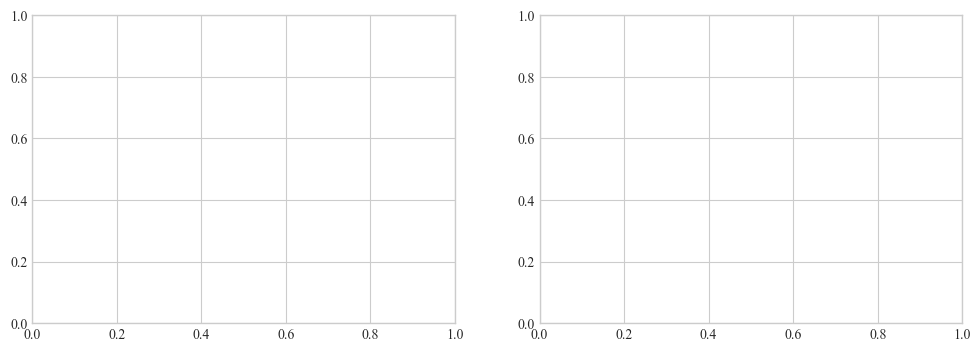

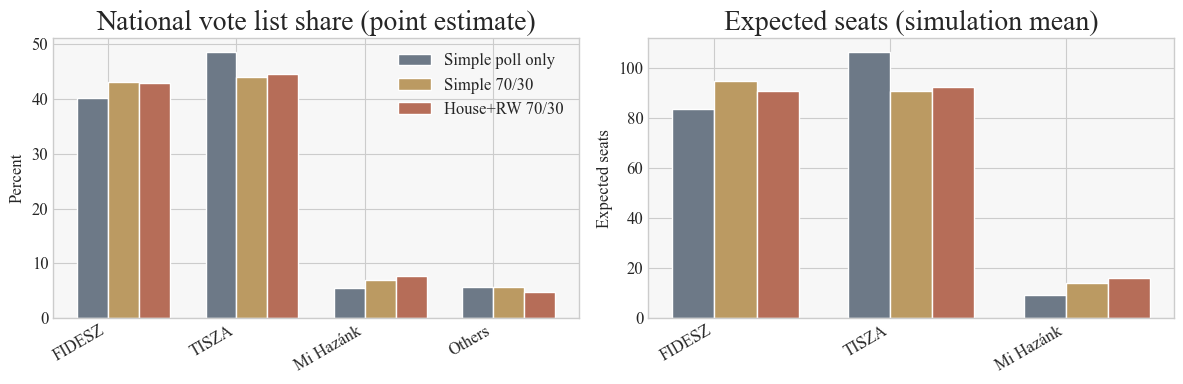

In [31]:
# this block creates the end-to-end poll path comparison figure.

block_labels = {
    "gov": "FIDESZ",
    "opp": "TISZA",
    "opp_radical": "Mi Hazánk",
    "other": "Others",
}
path_colors = {
    "simple_weighted_average": "#bb9a62",
    "simple_weighted_average_poll_only": "#6d7987",
    "house_effects_rw": "#b66d58",
}
path_labels = {
    "simple_weighted_average": "Simple 70/30",
    "simple_weighted_average_poll_only": "Simple poll only",
    "house_effects_rw": "House+RW 70/30",
}
plot_blocks_left = ["gov", "opp", "opp_radical", "other"]
plot_blocks_right = ["gov", "opp", "opp_radical"]
paths = ["simple_weighted_average_poll_only", "simple_weighted_average", "house_effects_rw"]
results = {
    "simple_weighted_average": simple_result,
    "simple_weighted_average_poll_only": simple_poll_only_result,
    "house_effects_rw": house_result,
}

x_left = np.arange(len(plot_blocks_left))
x_right = np.arange(len(plot_blocks_right))
width = 0.24

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.patch.set_facecolor("white")

rc = {"font.family": map_font_family, "font.size": map_font_size}
with plt.rc_context(rc):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    fig.patch.set_facecolor("white")

    # left panel: combined national forecast
    for idx, path_name in enumerate(paths):
        vals = [
            results[path_name]["combined_forecast"][b] * 100
            for b in plot_blocks_left
        ]
        ax1.bar(
            x_left + (idx - 0.5) * width,
            vals,
            width,
            label=path_labels[path_name],
            color=path_colors[path_name],
            edgecolor="white",
        )
    ax1.set_xticks(x_left)
    ax1.set_xticklabels([block_labels[b] for b in plot_blocks_left], rotation=30, ha="right", fontsize=map_font_size)
    ax1.set_ylabel("Percent", fontsize=map_font_size)
    ax1.set_title("National vote list share (point estimate)", fontsize=map_font_size+8)
    ax1.legend(fontsize=map_font_size)
    ax1.set_facecolor("#f7f7f7")

    # right panel: expected seats
    for idx, path_name in enumerate(paths):
        vals = [
            result_expected_seats(results[path_name], b)
            for b in plot_blocks_right
        ]
        ax2.bar(
            x_right + (idx - 0.5) * width,
            vals,
            width,
            label=path_labels[path_name],
            color=path_colors[path_name],
            edgecolor="white",
        )
    ax2.set_xticks(x_right)
    ax2.set_xticklabels([block_labels[b] for b in plot_blocks_right], rotation=30, ha="right", fontsize=map_font_size)
    ax2.set_ylabel("Expected seats", fontsize=map_font_size)
    ax2.set_title("Expected seats (simulation mean)", fontsize=map_font_size+8)
    ax2.set_facecolor("#f7f7f7")

    plt.tight_layout()

    # save to both locations
    fig_filename = "strict_vs_theory_comparison.png"
    for save_path in [
        project_root / "graphs_tables" / fig_filename,
        latex_figures_dir / fig_filename,
    ]:
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"saved to: {save_path}")
    plt.show()

Interpretation. This output is a quick diagnostic check of scale, spread and completeness.


### Export The Final Forecast

This block saves the final notebook 13 forecast in a small JSON file. Notebook 14 reads this file directly, so if you rerun notebook 13 and save it, notebook 14 can use the updated forecast automatically.
    


In [32]:
# this block saves the notebook 13 forecast in a machine-readable file.
forecast_export_path = here / "13_final_2026_forecast_export.json"
probability_events = [
    "gov finishes first",
    "opp finishes first",
    "gov majority",
    "gov two thirds",
    "opp majority",
    "opp two thirds",
    "parliament without gov majority",
    "parliament without opp majority",
]

forecast_export = {
    "source_notebook": str(here / "13_final_2026_forecast.ipynb"),
    "main_path": "simple_weighted_average",
    "sensitivity_path": "house_effects_rw",
    "additional_sensitivity_paths": ["simple_weighted_average_poll_only"],
    "fixed_election_day": str(election_assumption_2026.date()),
    "generated_utc": pd.Timestamp.utcnow().isoformat(),
    "paths": {
        path_name: {
            "vote_share_pct": {block: round(float(result["combined_forecast"][block] * 100.0), 4) for block in block_cols},
            "point_seats": {block: int(result_point_seats(result, block)) for block in seat_blocks},
            "expected_seats": {block: round(float(result_expected_seats(result, block)), 4) for block in seat_blocks},
            "probabilities_pct": {event_name: round(float(result_prob(result, event_name) * 100.0), 4) for event_name in probability_events},
        }
        for path_name, result in poll_path_results.items()
    },
}

with forecast_export_path.open("w", encoding="utf-8") as f:
    json.dump(forecast_export, f, ensure_ascii=False, indent=2)

forecast_export_preview = pd.DataFrame(
    [
        {
            "path": path_name,
            **forecast_export["paths"][path_name]["vote_share_pct"],
        }
        for path_name in ["simple_weighted_average", "simple_weighted_average_poll_only", "house_effects_rw"]
    ]
)

print("saved forecast export to:")
print(forecast_export_path)
display(forecast_export_preview.round(2))
    


saved forecast export to:
/Users/andrasikristof/Documents/Egyetem/2026:27 - 2. félév/Election_predictions/scripts/final_final_scripts/13_final_2026_forecast_export.json


,path,gov,opp,opp_radical,other
0,simple_weighted_average,43.18,44.11,7.04,5.67
1,simple_weighted_average_poll_only,40.12,48.68,5.59,5.61
2,house_effects_rw,42.98,44.60,7.73,4.69


**Interpretation:** The printed path shows where notebook 14 will load the forecast from. The table shows the current exported vote-share forecast, and it should update when notebook 13 is rerun and saved.
    


## Final Note

This notebook builds a complete election forecast pipeline. The key improvements over a naive approach are:

- Polls are corrected for pollster-specific biases (house effects)
- Voter support is allowed to move over time (random walk)
- Vote shares are modelled as a composition (they add up to 100%)
- District structure (demographics, economy, media) predicts local deviations
- Candidate shares in single-member districts are modelled separately
- Uncertainty is propagated through Monte Carlo simulation to get a seat distribution

The main remaining limitation: the candidate-gap model only has one full parliamentary
transition cycle for training (2018 to 2022), so it is deliberately shrunk toward the
safer list-share proxy.
